# **Projeto Integrador V**
# **🍺 Inteligência de Risco em Comodato de Chopp**

**1° Semestre/2026**

**Curso:** Ciência de Dados para Negócio | **Instituição:** FATEC Votorantim  
**Alunos:** Ana Elisa · Arthur Nunes · Bruno Araujo · Caio Corrá · Lucas Camelo · Nicole Fava

---

## 🗺️ Pipeline do Projeto

| Fase  | Nome             | Objetivo                                            |
| :---: | :--------------  | :-------------------------------------------------- |
| **0** | ⚙️ Configuração | Imports, constantes, funções utilitárias, paleta    |
| **1** | 🎯 Negócio      | Contexto, hipótese, KPIs                            |
| **2** | 💾 Dados        | SQL + CSV                                           |
| **3** | 🔍 EDA          | Auditoria, perfil 360°, risco, aging                |
| **4** | 🔧 Features     | `df_ml_completo` (usuários) vs `df_treino` (modelo) |
| **5** | 🤖 Modelagem    | Pipelines, MODEL_REGISTRY, CV                       |
| **6** | 📊 Avaliação    | ROC, PR, matrizes, importâncias                     |
| **7** | 🚀 Deploy       | Versionamento, `predict_by_id()`                    |  
#
> **Meta:** Classificar clientes como **Alto Risco** (≥ 20% atrasos financeiros _ou_ de comodato).

# ⚙️Fase 0 - Configuração

In [2]:
# ─── Bibliotecas Padrão ───────────────────────────────────────────────────────
import warnings, pickle, os, json
from datetime import datetime
from pathlib import Path
from typing import Dict, Any, cast

warnings.filterwarnings("ignore")

# ─── Manipulação de Dados ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualização ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

# ─── Machine Learning ─────────────────────────────────────────────────────────
from joblib import Memory
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

# ── Exibição Visual do Pipeline ──────────────────────────────────────────────
from sklearn import set_config
from IPython.display import display

set_config(display="diagram")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.family": "DejaVu Sans"})

# ══════════════════════════════════════════════════════════════════════════════
#  CONSTANTES GLOBAIS DO PROJETO  —  edite APENAS aqui
# ══════════════════════════════════════════════════════════════════════════════
RANDOM_STATE = 42
LIMITE_ATRASO = 0.20  # > 20% atrasos = ALTO RISCO
MIN_COMPRAS = 2  # mínimo de compras para entrar no treino (veteranos)
TEST_SIZE = 0.30  # 70% treino / 30% teste
CV_FOLDS = 5  # K-Fold estratificado
DATA_DIR = "."  # diretório dos CSVs
MODEL_DIR = "modelos"  # diretório de saída dos PKLs
MODEL_VERSION = "1.0.0"

# ─── Paleta de Cores ──────────────────────────────────────────────────────────
CORES_MODELO = {
    "Regressão Logística": "#3498DB",
    "Árvore de Decisão": "#2ECC71",
    "Random Forest": "#E74C3C",
}
CORES_RISCO = {
    "BAIXO": "#2ECC71",
    "MÉDIO": "#F39C12",
    "ALTO": "#E74C3C",
}

Path(MODEL_DIR).mkdir(exist_ok=True)

print("✅ Ambiente configurado com sucesso!")
print(f"   └─ pandas {pd.__version__} | numpy {np.__version__}")
print(f"   └─ Threshold de risco  : >{LIMITE_ATRASO*100:.0f}%")
print(f"   └─ Validação cruzada   : {CV_FOLDS}-Fold estratificado")
print(f"   └─ Diretório de modelos: {MODEL_DIR}/")

✅ Ambiente configurado com sucesso!
   └─ pandas 2.3.1 | numpy 2.3.2
   └─ Threshold de risco  : >20%
   └─ Validação cruzada   : 5-Fold estratificado
   └─ Diretório de modelos: modelos/


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  FUNÇÕES UTILITÁRIAS
# ══════════════════════════════════════════════════════════════════════════════


# ─── Formatadores ─────────────────────────────────────────────────────────────
def fmt_moeda(x, pos=None):
    """Formata valores como moeda brasileira abreviada."""
    if x >= 1e6:
        return f"R$ {x*1e-6:.1f}M"
    if x >= 1e3:
        return f"R$ {x*1e-3:.1f}k"
    return f"R$ {x:.0f}"


def fmt_numero(x, pos=None):
    """Formata inteiros com separador de milhar ponto (.)"""
    return f"{int(x):,}".replace(",", ".")


# ─── Agrupador de Cidades ─────────────────────────────────────────────────────
def agrupar_cidades(cidade):
    """Padroniza variações de digitação de nomes de cidades."""
    c = str(cidade).upper().strip()
    if any(k in c for k in ["PONTA POR", "SANGA", "SANGRA"]):
        return "PONTA PORÃ"
    if "PEDRO JUAN" in c:
        return "PEDRO JUAN CABALLERO"
    if any(k in c for k in ["AMAMBA", "AMANBA"]):
        return "AMAMBAI"
    if c in ["NAN", "", "NONE", "NÃO PREENCHIDO", "NAO PREENCHIDO"] or pd.isna(c):
        return "NÃO PREENCHIDO"
    return "OUTRAS CIDADES"


# ─── Construtor de Dimensões ──────────────────────────────────────────────────
def build_dimensoes(tabelas_db: dict) -> pd.DataFrame:
    """
    Cria tabela-mestra: ID_CLIENTE, ID_PESSOA, PERFIL, CIDADE, PAGAMENTO.
    Centraliza o join que seria repetido em múltiplas células.
    """
    df_pessoa = tabelas_db["TB_PESSOA"][["ID_PESSOA", "TP_TIPO"]].copy()
    df_pessoa["PERFIL"] = (
        df_pessoa["TP_TIPO"]
        .map(MAPA_PESSOA)
        .fillna("Não Informado")
    )

    df_loc = tabelas_db["TB_CLIENTE_ENDERECO"][["ID_CLIENTE", "DS_CIDADE"]].copy()
    df_loc["CIDADE"] = df_loc["DS_CIDADE"].apply(agrupar_cidades)
    df_loc = df_loc.drop_duplicates("ID_CLIENTE")[["ID_CLIENTE", "CIDADE"]]

    df_pgto = tabelas_db["TB_FORMA_PAGTO"][["ID_FORMA_PAGTO", "DS_FORMA_PAGTO"]].copy()
    df_cli = tabelas_db["TB_CLIENTE"][
        ["ID_CLIENTE", "ID_PESSOA", "ID_FORMA_PAGAMENTO_1"]
    ].copy()
    df_cli = df_cli.merge(
        df_pgto, left_on="ID_FORMA_PAGAMENTO_1", right_on="ID_FORMA_PAGTO", how="left"
    )
    df_cli["PAGAMENTO"] = df_cli["DS_FORMA_PAGTO"].fillna("OUTROS").str.upper()

    df_dim = (
        df_cli[["ID_CLIENTE", "ID_PESSOA", "PAGAMENTO"]]
        .merge(df_pessoa[["ID_PESSOA", "PERFIL"]], on="ID_PESSOA", how="left")
        .merge(df_loc, on="ID_CLIENTE", how="left")
    )
    for col, val in [
        ("CIDADE", "NÃO PREENCHIDO"),
        ("PERFIL", "Não Informado"),
        ("PAGAMENTO", "OUTROS"),
    ]:
        df_dim[col] = df_dim[col].fillna(val)
    return df_dim


# ─── Calculadores de Atraso ───────────────────────────────────────────────────
def calc_atraso_financeiro(df_fin: pd.DataFrame, data_corte=None) -> pd.DataFrame:
    """
    Calcula DIAS_ATRASO_PAG e flag ATRASOU_PAGAMENTO (0/1) por parcela.
    Regra: pagou depois do vencimento OU não pagou e já venceu.
    """
    data_corte = data_corte or pd.Timestamp.now()
    df = df_fin.copy()
    df["DT_VENCIMENTO"] = pd.to_datetime(df["DT_VENCIMENTO"], errors="coerce")
    col_pgto = "DT_BAIXA" if "DT_BAIXA" in df.columns else "DT_RECEBIMENTO"
    df[col_pgto] = pd.to_datetime(df[col_pgto], errors="coerce")
    df["DT_PGTO_EFETIVO"] = df[col_pgto].fillna(data_corte)
    df["DIAS_ATRASO_PAG"] = (df["DT_PGTO_EFETIVO"] - df["DT_VENCIMENTO"]).dt.days.clip(
        lower=0
    )
    df["ATRASOU_PAGAMENTO"] = (
        (df[col_pgto] > df["DT_VENCIMENTO"])
        | (df[col_pgto].isna() & (df["DT_VENCIMENTO"] < data_corte))
    ).astype(int)
    return df


def calc_atraso_comodato(df_com: pd.DataFrame, data_corte=None) -> pd.DataFrame:
    """
    Calcula DIAS_ATRASO_COM e flag ATRASOU_COMODATO (0/1) por contrato.
    Regra: devolveu depois do vencimento OU não devolveu e já venceu.
    """
    data_corte = data_corte or pd.Timestamp.now()
    df = df_com.copy()
    df["DT_VENCIMENTO"] = pd.to_datetime(df["DT_VENCIMENTO"], errors="coerce")
    df["DT_RECOLHE"] = pd.to_datetime(df["DT_RECOLHE"], errors="coerce")
    df["DT_REC_EFETIVO"] = df["DT_RECOLHE"].fillna(data_corte)
    df["DIAS_ATRASO_COM"] = (df["DT_REC_EFETIVO"] - df["DT_VENCIMENTO"]).dt.days.clip(
        lower=0
    )
    df["ATRASOU_COMODATO"] = (
        (df["DT_RECOLHE"] > df["DT_VENCIMENTO"])
        | (df["DT_RECOLHE"].isna() & (df["DT_VENCIMENTO"] < data_corte))
    ).astype(int)
    return df


# ─── Categorizador de Aging ───────────────────────────────────────────────────
ORDEM_AGING = [
    "1-3 Dias",
    "4-7 Dias",
    "8-15 Dias",
    "16-20 Dias",
    "21-30 Dias",
    "+30 Dias",
]

MAPA_PESSOA = {'F': 'Física', 'J': 'Jurídica','E':'Estrangeiro'}

def categorizar_atraso(dias: float) -> str | None:
    """Converte dias de atraso em faixa categórica de aging."""
    if dias <= 0:
        return None
    if dias <= 3:
        return "1-3 Dias"
    if dias <= 7:
        return "4-7 Dias"
    if dias <= 15:
        return "8-15 Dias"
    if dias <= 20:
        return "16-20 Dias"
    if dias <= 30:
        return "21-30 Dias"
    return "+30 Dias"


print("✅ Funções utilitárias carregadas!")
print("   ├─ fmt_moeda() | fmt_numero()")
print("   ├─ agrupar_cidades()")
print("   ├─ build_dimensoes(tabelas_db)")
print("   ├─ calc_atraso_financeiro(df, data_corte)")
print("   ├─ calc_atraso_comodato(df, data_corte)")
print("   └─ categorizar_atraso(dias) → faixa aging")

✅ Funções utilitárias carregadas!
   ├─ fmt_moeda() | fmt_numero()
   ├─ agrupar_cidades()
   ├─ build_dimensoes(tabelas_db)
   ├─ calc_atraso_financeiro(df, data_corte)
   ├─ calc_atraso_comodato(df, data_corte)
   └─ categorizar_atraso(dias) → faixa aging


# 🎯 Fase 1 - Entendimento do Negócio

### 📌 Contexto do Projeto e do Negócio

O objeto de estudo é uma **distribuidora de chopp** localizada estrategicamente na cidade de **Ponta Porã (MS)**, na fronteira entre o Brasil e o Paraguai. 

<center>Figura 1: Imagem aérea da fronteira entre Ponta Porã (Brasil) e Pedro Juan Caballero (Paraguai)<br>

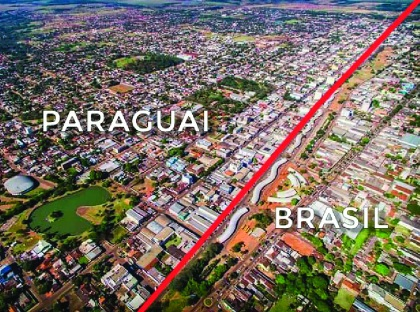

Fonte: (BARBOSA; NOGUEIRA, 2024) </center>

Devido à sua localização transfronteiriça e ao modelo de negócio baseado em recorrência e empréstimo de equipamentos (comodatos), a empresa enfrenta desafios singulares em relação ao comportamento de compra, perfil de cliente e gestão de inadimplência. 

Nosso objetivo principal é utilizar técnicas de Ciência de Dados e Machine Learning para analisar esse histórico, identificar padrões de risco e auxiliar a tomada de decisão comercial da distribuidora.

### Hipótese Central

> Clientes com histórico de atrasos (financeiro **e/ou** comodato) podem ser
> identificados preventivamente com base no perfil + comportamento.

### KPIs de Sucesso

| Métrica         |  Meta  | Justificativa                           |
| :-------------- | :----: | :-------------------------------------- |
| AUC-ROC         | ≥ 0.75 | Discriminação geral                     |
| Recall classe 1 | ≥ 0.70 | **Minimizar falsos negativos (custo alto)** |
| Accuracy        | ≥ 0.65 | Baseline razoável para dataset pequeno  |

### Separação de Datasets

| Dataset          | Propósito                                                                                      |
| :--------------- | :--------------------------------------------------------------------------------------------- |
| `df_ml_completo` | Todos os clientes com features calculadas — usado como "tabela de usuários" para lookup por ID |
| `df_treino`      | Subconjunto filtrado (veteranos) — vai para `X_train` / `X_test` do modelo                     |


# 💾 Fase 2 - Dados

Para a realização deste estudo, foi concedido acesso direto ao banco de dados relacional (SQL Server) do sistema de gestão da empresa (`DB_POWER_SYS`).

A seguir, iniciamos o processo de extração dos dados. O script de código abaixo estabelece a conexão segura com o banco de dados e realiza um mapeamento inteligente. Para otimizar o processamento e a memória, o algoritmo executa uma limpeza prévia automática: varre todas as tabelas, identifica as que contêm dados úteis e expurga colunas completamente vazias (100% nulas), entregando um relatório gerencial sobre a saúde inicial da nossa base de dados.

--- 

> Comente os blocos destacados se for usar CSVs já exportados

In [4]:
# ─── FASE 2A: Extração via SQL Server
# Comente este bloco inteiro se for usar CSVs já exportados

from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from IPython.display import display, Markdown

# 1. Configuração da Conexão
# params = quote_plus(
#     r"Driver={ODBC Driver 17 for SQL Server};"
#     r"Server=.\SQLEXPRESS;"
#     r"Database=DB_POWER_SYS;"
#     r"Trusted_Connection=yes;"
#     r"Encrypt=yes;"
#     r"TrustServerCertificate=yes;"
# )

params = quote_plus(
    r"Driver={ODBC Driver 17 for SQL Server};Server=localhost;"
    r"Database=DB_POWER_SYS;Trusted_Connection=yes;"
    r"Encrypt=yes;TrustServerCertificate=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Containers para o relatório e contadores globais
tabelas_db = {}
dados_relatorio = []
total_vazias = 0
total_colunas_ativas = 0
total_colunas_removidas = 0

try:
    query_tabelas = text(
        "SELECT TABLE_SCHEMA, TABLE_NAME FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE = 'BASE TABLE'"
    )

    with engine.connect() as conn:
        lista_tabelas = pd.read_sql(query_tabelas, conn)

        for _, linha in lista_tabelas.iterrows():
            nome_tab = linha["TABLE_NAME"]
            schema = linha["TABLE_SCHEMA"]
            tabela_full = f"[{schema}].[{nome_tab}]"

            try:
                # Carregamento dos dados
                df = pd.read_sql(text(f"SELECT * FROM {tabela_full}"), conn)

                if df.empty:
                    total_vazias += 1
                else:
                    cols_originais = len(df.columns)

                    # Limpeza: remove colunas onde todas as linhas são nulas
                    df_limpo = df.dropna(axis=1, how="all")
                    cols_ativas = len(df_limpo.columns)
                    cols_removidas = cols_originais - cols_ativas

                    # Somatório para o resumo geral
                    total_colunas_ativas += cols_ativas
                    total_colunas_removidas += cols_removidas

                    # Armazenamento
                    tabelas_db[nome_tab] = df_limpo

                    # Registra dados para o Markdown
                    dados_relatorio.append(
                        {
                            "Tabela": f"`{nome_tab}`",
                            "Linhas": len(df_limpo),
                            "Colunas Originais": cols_originais,
                            "Colunas Removidas": cols_removidas,
                            "Colunas Ativas": cols_ativas,
                        }
                    )

            except Exception as e:
                print(f"Erro na tabela {nome_tab}: {e}")

    # ==============================================================================
    # GERAÇÃO DO RELATÓRIO EM MARKDOWN
    # ==============================================================================
    df_resumo = pd.DataFrame(dados_relatorio)

    relatorio = f"""
### 📊 Relatório de Mapeamento e Limpeza de Dados
Abaixo estão listadas as tabelas identificadas no banco de dados **DB_POWER_SYS** que possuem registros ativos. 

> **Nota Metodológica:** Para otimização de memória e performance do modelo de Machine Learning, todas as colunas que possuíam 100% de valores nulos (vazios) foram descartadas automaticamente durante a ingestão dos dados.

| Tabela | Registros | Colunas Originais | Colunas Removidas | Colunas Ativas |
| :--- | :---: | :---: | :---: | :---: |
"""
    # Adicionando as linhas da tabela detalhada no Markdown
    for _, r in df_resumo.iterrows():
        relatorio += f"| {r['Tabela']} | {r['Linhas']} | {r['Colunas Originais']} | **{r['Colunas Removidas']}** | {r['Colunas Ativas']} |\n"

    # Adicionando a Tabela de Resumo Geral
    relatorio += f"""
### 📌 Resumo Geral do Banco de Dados
| Métrica | Quantidade |
| :--- | :---: |
| Tabelas com dados carregadas | **{len(tabelas_db)}** |
| Tabelas vazias ignoradas | **{total_vazias}** |
| Total de Colunas Ativas na Base | **{total_colunas_ativas}** |
| Total de Colunas Vazias Removidas | **{total_colunas_removidas}** |
#
> **💡 Dica de Uso:** Para acessar e trabalhar com qualquer uma das tabelas importadas nas próximas células do Notebook, utilize a estrutura `tabelas_db['NOME_DA_TABELA']` (Exemplo: `tabelas_db['TB_PRODUTO']`).
"""

    # Exibe o visual
    display(Markdown(relatorio))

except Exception as e:
    display(Markdown(f"## ❌ Erro Crítico na Conexão\n{e}"))


### 📊 Relatório de Mapeamento e Limpeza de Dados
Abaixo estão listadas as tabelas identificadas no banco de dados **DB_POWER_SYS** que possuem registros ativos. 

> **Nota Metodológica:** Para otimização de memória e performance do modelo de Machine Learning, todas as colunas que possuíam 100% de valores nulos (vazios) foram descartadas automaticamente durante a ingestão dos dados.

| Tabela | Registros | Colunas Originais | Colunas Removidas | Colunas Ativas |
| :--- | :---: | :---: | :---: | :---: |
| `RL_TIPO_DOCUMENTO_USUARIO` | 157 | 8 | **2** | 6 |
| `TB_FORMA_PAGTO` | 10 | 29 | **2** | 27 |
| `TB_ACESSO` | 1385 | 13 | **0** | 13 |
| `TB_PRODUTO_UNIDADE_MEDIDA` | 251 | 13 | **2** | 11 |
| `TB_TABELA_ESCALONADA` | 2 | 13 | **3** | 10 |
| `TB_PROGRAMA` | 280 | 11 | **2** | 9 |
| `TB_EMPRESA_VEND_ROTA_DATA` | 1879 | 8 | **2** | 6 |
| `RL_CONTA_CORRENTE_USUARIO` | 9 | 8 | **2** | 6 |
| `TB_REGRA_FISCAL` | 17 | 82 | **29** | 53 |
| `TB_BANCO` | 56 | 8 | **0** | 8 |
| `TB_FORNECEDOR` | 20 | 9 | **2** | 7 |
| `TB_BANCO_C_C_LANCAMENTO` | 6625 | 36 | **8** | 28 |
| `TB_FORNECEDOR_CONTATO` | 20 | 13 | **4** | 9 |
| `TB_BANCO_C_CORRENTE` | 6 | 19 | **4** | 15 |
| `TB_FORNECEDOR_ENDERECO` | 20 | 23 | **6** | 17 |
| `TB_CONDICAO_PAGTO` | 10 | 20 | **3** | 17 |
| `TB_CST_IBS_CBS` | 17 | 16 | **0** | 16 |
| `TB_GALPAO` | 1 | 7 | **0** | 7 |
| `TB_CONFIG_FATURAMENTO` | 1 | 139 | **52** | 87 |
| `TB_CCLASS_IBS_CBS` | 132 | 21 | **2** | 19 |
| `TB_CONFIG_FINANCEIRO` | 1 | 41 | **15** | 26 |
| `TB_NOTA_FISCAL_PARCELA` | 90 | 5 | **0** | 5 |
| `TB_GALPAO_ANDAR` | 1 | 7 | **0** | 7 |
| `TB_SALDO_ESTOQUE` | 120 | 14 | **0** | 14 |
| `TB_GALPAO_ARMAZENAMENTO` | 1 | 11 | **0** | 11 |
| `TB_CONFIG_GERAL` | 2 | 65 | **13** | 52 |
| `TB_CONDICAO_PAGAMENTO` | 9 | 15 | **2** | 13 |
| `TB_BANCO_HISTORICO` | 46 | 7 | **0** | 7 |
| `TB_GALPAO_RUA` | 1 | 7 | **0** | 7 |
| `TB_CONTAS_A_PAGAR` | 1165 | 24 | **2** | 22 |
| `TB_BANCO_MOTIVO_DEVOL_CHQ` | 21 | 8 | **0** | 8 |
| `TB_GALPAO_SETOR` | 1 | 7 | **0** | 7 |
| `TB_CONTAS_A_PAGAR_C_CUSTO` | 1636 | 12 | **0** | 12 |
| `TB_ESTOQUE_LANCAMENTO_INVENTARIO_CABECALHO` | 3 | 12 | **5** | 7 |
| `TB_CONTAS_A_PAGAR_PARCELA` | 1635 | 44 | **5** | 39 |
| `TB_CONTAS_A_RECEBER` | 4444 | 27 | **3** | 24 |
| `TB_SETOR_ENTREGA` | 8 | 15 | **6** | 9 |
| `TB_GRUPO_ANALISE` | 7 | 7 | **0** | 7 |
| `TB_CONTAS_A_RECEBER_C_CUSTO` | 5110 | 12 | **0** | 12 |
| `TB_CONFIG_PRODUCAO` | 1 | 16 | **14** | 2 |
| `TB_SITUACAO_TRIBUTARIA` | 113 | 10 | **0** | 10 |
| `TB_CONTAS_A_RECEBER_PARCELA` | 5110 | 49 | **5** | 44 |
| `TB_STATUS` | 29 | 7 | **1** | 6 |
| `TB_GRUPO_ICMS` | 6 | 13 | **1** | 12 |
| `TB_TABELA_VENDA` | 18 | 17 | **1** | 16 |
| `TB_TABELA_VENDA_PRECO` | 460 | 23 | **6** | 17 |
| `TB_CAMBIO_COTACAO` | 6 | 7 | **0** | 7 |
| `TB_MARCA` | 8 | 8 | **0** | 8 |
| `TB_TIPO_DOCUMENTO` | 51 | 9 | **0** | 9 |
| `TB_MENSAGEM_MOTIVO` | 20 | 10 | **0** | 10 |
| `TB_CAMBIO_COTACAO_ITEM` | 15 | 12 | **3** | 9 |
| `TB_CONFIG_MOBILE` | 1 | 34 | **11** | 23 |
| `TB_CAMBIO_OPERACAO` | 2 | 27 | **9** | 18 |
| `TB_TIPO_ESTABELECIMENTO` | 90 | 10 | **1** | 9 |
| `TB_MODULO` | 2 | 7 | **2** | 5 |
| `TB_CONVENIO` | 1 | 19 | **7** | 12 |
| `TB_TIPO_IMPOSTO` | 4 | 7 | **2** | 5 |
| `TB_MOEDA` | 3 | 8 | **0** | 8 |
| `TB_CARGA` | 1601 | 26 | **10** | 16 |
| `TB_ORCAMENTO_PARCELA` | 6 | 36 | **18** | 18 |
| `TB_CARGA_DEVOLUCAO` | 3 | 7 | **2** | 5 |
| `TB_TIPO_OPERACAO` | 47 | 28 | **2** | 26 |
| `TB_CARGA_DEVOLUCAO_ITEM` | 6 | 18 | **2** | 16 |
| `TB_COR_SABOR` | 11 | 7 | **0** | 7 |
| `TB_MOVIMENTA_ESTOQUE` | 18513 | 22 | **6** | 16 |
| `TB_CARGA_PEDIDO` | 8543 | 9 | **3** | 6 |
| `TB_CARGO` | 22 | 7 | **0** | 7 |
| `TB_NOTA_FISCAL` | 102 | 73 | **18** | 55 |
| `TB_CSOSN` | 10 | 8 | **0** | 8 |
| `TB_TIPO_PRODUTO` | 8 | 8 | **2** | 6 |
| `TB_NOTA_FISCAL_ENTRADA` | 173 | 56 | **7** | 49 |
| `TB_NOTA_FISCAL_ENTRADA_CC` | 173 | 13 | **3** | 10 |
| `TB_TRANSPORTADORA` | 2 | 15 | **9** | 6 |
| `TB_NOTA_FISCAL_ITEM` | 129 | 172 | **49** | 123 |
| `TB_NOTA_FISCAL_ENTRADA_ITEM` | 273 | 59 | **14** | 45 |
| `TB_TRANSPORTADORA_CONTATO` | 2 | 13 | **5** | 8 |
| `TB_NOTA_FISCAL_ENTRADA_PARCELA` | 173 | 13 | **2** | 11 |
| `TB_CATEGORIA` | 8 | 11 | **1** | 10 |
| `TB_TRANSPORTADORA_ENDERECO` | 2 | 22 | **5** | 17 |
| `TB_CENTRO_CUSTO` | 123 | 11 | **0** | 11 |
| `TB_UNIDADE_MEDIDA` | 6 | 23 | **9** | 14 |
| `TB_FORMA_PAGAMENTO` | 10 | 18 | **1** | 17 |
| `TB_EMITENTE` | 1 | 8 | **2** | 6 |
| `TB_USUARIO` | 9 | 17 | **2** | 15 |
| `TB_NOTA_FISCAL_EVENTO` | 2 | 12 | **0** | 12 |
| `TB_EMP_FUNCIONARIO_ENDERECO` | 17 | 23 | **5** | 18 |
| `TB_EMP_FUNCIONARIO_TELEFONE` | 17 | 12 | **4** | 8 |
| `TB_CFOP` | 460 | 11 | **0** | 11 |
| `TB_EMPRESA` | 2 | 68 | **46** | 22 |
| `TB_UNIDAD_MEDIDA` | 34 | 3 | **0** | 3 |
| `TB_EMPRESA_CONEXAO` | 2 | 8 | **2** | 6 |
| `TB_CHEQUE_LANCAMENTO` | 4 | 48 | **24** | 24 |
| `TB_IBPT` | 11645 | 7 | **0** | 7 |
| `TB_EMPRESA_ENDERECO` | 2 | 19 | **5** | 14 |
| `TB_CLIENTE` | 1175 | 65 | **35** | 30 |
| `TB_CONFIG_NOTA_FISCAL` | 1 | 62 | **28** | 34 |
| `TB_CLIENTE_CONTATO` | 1167 | 13 | **2** | 11 |
| `TB_EMPRESA_FUNCIONARIO` | 17 | 27 | **13** | 14 |
| `TB_NOTA_LEGAL` | 2 | 86 | **48** | 38 |
| `TB_CLIENTE_ENDERECO` | 1160 | 28 | **9** | 19 |
| `TB_NOTA_LEGAL_ITEM` | 4 | 26 | **8** | 18 |
| `TB_CLIENTE_PRE_CADASTRO` | 1 | 83 | **52** | 31 |
| `TB_ORCAMENTO` | 6 | 85 | **31** | 54 |
| `TB_ORCAMENTO_ITEM` | 8 | 106 | **53** | 53 |
| `TB_EMPRESA_VEND_ROTA` | 1 | 16 | **9** | 7 |
| `RL_EMPRESA_USUARIO` | 10 | 8 | **2** | 6 |
| `TB_PEDIDO` | 8913 | 119 | **38** | 81 |
| `TB_ESTOQUE_LANCAMENTO_MANUAL` | 161 | 33 | **4** | 29 |
| `RL_EMPRESA_VENDEDOR` | 6 | 22 | **9** | 13 |
| `TB_PEDIDO_ITEM` | 18760 | 200 | **132** | 68 |
| `TB_CONFIG_MANIFESTO` | 1 | 31 | **29** | 2 |
| `TB_RECEBER_BAIXA_LOTE_CHEQUE` | 3 | 6 | **3** | 3 |
| `TB_PEDIDO_PARCELA` | 6814 | 52 | **30** | 22 |
| `RL_PRODUTO_GALPAO_ARMAZENA` | 120 | 8 | **2** | 6 |
| `TB_PESSOA` | 1214 | 27 | **3** | 24 |
| `TB_PRODUTO` | 120 | 80 | **38** | 42 |
| `RL_TIPO_OPERACAO_USUARIO` | 162 | 8 | **2** | 6 |
| `TB_RECEBER_BAIXA_LOTE_CHEQUE_ITEM` | 6 | 8 | **3** | 5 |
| `TB_EXPEDICAO` | 8863 | 8 | **4** | 4 |
| `TB_COMODATO` | 2132 | 21 | **1** | 20 |
| `TB_PRODUTO_COMPOSICAO_CUSTO` | 114 | 43 | **5** | 38 |
| `TB_ACERTO_CONTA` | 1237 | 12 | **5** | 7 |
| `TB_EXPEDICAO_ITEM` | 18075 | 9 | **2** | 7 |
| `TB_COMODATO_BEM` | 6423 | 18 | **6** | 12 |
| `TB_PRODUTO_GRUPO_ANALISE` | 2 | 7 | **2** | 5 |
| `TB_ACERTO_CONTA_FINANCEIRO` | 2169 | 12 | **2** | 10 |
| `TB_ACERTO_CONTA_FINANCEIRO_RECEBIDO` | 1827 | 10 | **2** | 8 |
| `TB_FAMILIA` | 10 | 13 | **1** | 12 |
| `TB_PRODUTO_PAUTA_IMPOSTO` | 5 | 79 | **68** | 11 |

### 📌 Resumo Geral do Banco de Dados
| Métrica | Quantidade |
| :--- | :---: |
| Tabelas com dados carregadas | **129** |
| Tabelas vazias ignoradas | **184** |
| Total de Colunas Ativas na Base | **2293** |
| Total de Colunas Vazias Removidas | **1178** |
#
> **💡 Dica de Uso:** Para acessar e trabalhar com qualquer uma das tabelas importadas nas próximas células do Notebook, utilize a estrutura `tabelas_db['NOME_DA_TABELA']` (Exemplo: `tabelas_db['TB_PRODUTO']`).


#### ⚙️ Engenharia de Atributos: Criação de Views Estratégicas
Para otimizar a extração de dados e garantir que o modelo de Machine Learning receba as informações já pré-processadas e focadas no objetivo do negócio, três visões (`Views`) foram construídas diretamente no banco de dados SQL Server da distribuidora. 

O objetivo dessas views é isolar os dados transacionais e facilitar o cálculo das métricas que compõem o perfil de risco e comportamento do cliente. A seguir, detalhamos a estrutura e a finalidade de cada uma:

#### 1. View de Vendas (`vw_calculo_score_vendas`)
**Objetivo:** Mapear a recorrência de compras, o volume financeiro gerado e o engajamento do cliente com os produtos. Esta base filtra apenas pedidos ativos e consolidados (Status 11).
* **`ID_PESSOA` / `ID_PRODUTO`:** Identificadores fundamentais do cliente e do item consumido.
* **`QTD_VENDA` e `QTD_DEVOLUCAO`:** Medem o volume bruto consumido e se há um alto índice de devolução de produtos por parte daquele cliente.
* **`VL_FINANCEIRO`:** A receita líquida/bruta gerada pelo item, base para cálculo do Ticket Médio.
* **`DT_PEDIDO` e `DT_ACERTO`:** Permitem medir a frequência de compra (tempo entre um pedido e outro) e o ciclo de vida do cliente (Análise RFM - Recência, Frequência e Valor Monetário).

#### 2. View de Comodato (`vw_calculo_score_comodato`)
**Objetivo:** Avaliar o risco logístico e o compromisso do cliente com os equipamentos (chopeiras) emprestados. Filtramos apenas comodatos encerrados (Status 24) para analisar o histórico real de devolução.
* **`ID_COMODATO` / `ID_PEDIDO` / `ID_CLIENTE`:** Chaves de relacionamento para cruzar o empréstimo da máquina com a venda do chopp.
* **`ID_PRODUTO` e `QTD_PRODUTO`:** Identifica qual equipamento foi cedido e em qual quantidade.
* **`DT_EMPRESTIMO`:** Data inicial da cessão do equipamento.
* **`DT_VENCIMENTO` vs. `DT_RECOLHE`:** O "coração" desta view. O cruzamento destas duas datas permite ao modelo calcular matematicamente os **Dias de Atraso** na devolução. Uma data de recolhimento superior ao vencimento sinaliza um desvio de conduta e aumenta o risco do cliente.

#### 3. View Financeira (`vw_calculo_score_financeiro`)
**Objetivo:** Mensurar o risco de crédito (inadimplência) e a pontualidade nos pagamentos. A view consolida as contas a receber já baixadas (Status 17) que possuem vínculo com um pedido.
* **`ID_PESSOA` / `ID_PEDIDO`:** Relacionamento com o cliente e a venda que gerou a cobrança.
* **`NR_PARCELA` e `VL_PARCELA`:** Identifica se a compra foi fracionada e qual o valor do compromisso financeiro.
* **`DT_VENCIMENTO` vs. `DT_RECEBIMENTO`:** Assim como no comodato, a diferença entre essas datas gera a variável de **Atraso Financeiro**. 
* **`VL_RECEBIDO`:** Usado para cruzar com o valor da parcela e identificar se houve pagamento parcial, descontos ou cobrança de juros/multas.
* **`DT_BAIXA` e `TP_BAIXA`:** Dados de auditoria que indicam quando e como o título foi efetivamente liquidado no sistema.

---

> As principais tabelas de suporte identificadas assim como essas Visões criadas foram exportadas no formato CSV para facilitar a replicação do uso deste Pipeline sem que seja necessário fazer a conexão direta com o banco de dados

In [5]:
# ─── FASE 2A: Extração via SQL Server
# Comente este bloco inteiro se for usar CSVs já exportados

df_vendas = pd.read_sql("SELECT * FROM dbo.vw_calculo_score_vendas", engine)
df_financeiro = pd.read_sql("SELECT * FROM dbo.vw_calculo_score_financeiro", engine)
df_comodato = pd.read_sql("SELECT * FROM dbo.vw_calculo_score_comodato", engine)

tabelas_dim = [
    "TB_CLIENTE",
    "TB_PESSOA",
    "TB_PRODUTO",
    "TB_PEDIDO_ITEM",
    "TB_CLIENTE_ENDERECO",
    "TB_FORMA_PAGTO",
    "TB_TIPO_ESTABELECIMENTO",
]
tabelas_db = {t: pd.read_sql(f"SELECT * FROM dbo.{t}", engine) for t in tabelas_dim}

# Export para CSV (persistência)
for nome_csv, df_exp in [
    ("score_vendas", df_vendas),
    ("score_financeiro", df_financeiro),
    ("score_comodato", df_comodato),
]:
    df_exp.to_csv(f"{nome_csv}.csv", index=False, sep=";", encoding="utf-8-sig")

for nome, df_tab in tabelas_db.items():
    df_tab.to_csv(f"{nome}.csv", index=False, sep=";", encoding="utf-8-sig")

print("✅ Dados extraídos do SQL e exportados para CSV!")

✅ Dados extraídos do SQL e exportados para CSV!


In [6]:
# ─── FASE 2B: Carga dos CSVs ──────────────────────────────────────────────────
print("📂 Carregando dados dos CSVs...")
print(f"   └─ Diretório: {DATA_DIR}\n")

LEITURA_PARAMS: Dict[str, Any] = {
    "sep": ";",
    "encoding": "utf-8-sig",
    "low_memory": False,
}
# Views Transacionais
df_vendas = pd.read_csv(os.path.join(DATA_DIR, "score_vendas.csv"), **LEITURA_PARAMS)
df_financeiro = pd.read_csv(os.path.join(DATA_DIR, "score_financeiro.csv"), **LEITURA_PARAMS)
df_comodato = pd.read_csv(os.path.join(DATA_DIR, "score_comodato.csv"), **LEITURA_PARAMS)

# Tabelas Dimensionais
TABELAS_DIM = [
    "TB_CLIENTE",
    "TB_PESSOA",
    "TB_PRODUTO",
    "TB_PEDIDO_ITEM",
    "TB_CLIENTE_ENDERECO",
    "TB_FORMA_PAGTO",
    "TB_TIPO_ESTABELECIMENTO",
]

tabelas_db = {}

for nome in TABELAS_DIM:
    caminho = os.path.join(DATA_DIR, f"{nome}.csv")
    if os.path.exists(caminho):
        tabelas_db[nome] = pd.read_csv(caminho, **LEITURA_PARAMS)
        print(f"   ✅ {nome:<35} → {tabelas_db[nome].shape[0]:>6,} linhas | {tabelas_db[nome].shape[1]:>3} colunas")
    else:
        print(f"   ⚠️  {nome:<35} → arquivo não encontrado!")

print(f"\n📊 Views Transacionais:")
print(f"   ├─ df_vendas     : {df_vendas.shape[0]:>6,} linhas × {df_vendas.shape[1]} colunas")
print(f"   ├─ df_financeiro : {df_financeiro.shape[0]:>6,} linhas × {df_financeiro.shape[1]} colunas")
print(f"   └─ df_comodato   : {df_comodato.shape[0]:>6,} linhas × {df_comodato.shape[1]} colunas")

📂 Carregando dados dos CSVs...
   └─ Diretório: .

   ✅ TB_CLIENTE                          →  1,175 linhas |  65 colunas
   ✅ TB_PESSOA                           →  1,214 linhas |  27 colunas
   ✅ TB_PRODUTO                          →    120 linhas |  80 colunas
   ✅ TB_PEDIDO_ITEM                      → 18,760 linhas | 200 colunas
   ✅ TB_CLIENTE_ENDERECO                 →  1,160 linhas |  28 colunas
   ✅ TB_FORMA_PAGTO                      →     10 linhas |  29 colunas
   ✅ TB_TIPO_ESTABELECIMENTO             →     90 linhas |  10 colunas

📊 Views Transacionais:
   ├─ df_vendas     :  5,115 linhas × 8 colunas
   ├─ df_financeiro :  4,411 linhas × 9 colunas
   └─ df_comodato   :  6,303 linhas × 8 colunas


# 🔍 Fase 3 - Exploração e Qualidade dos Dados (EDA)

Nesta fase, realizamos um mergulho profundo no histórico transacional e cadastral para compreender a dinâmica de faturamento, o comportamento volumétrico e, principalmente, os padrões ocultos de risco de inadimplência no comodato de chopp. A **Análise Exploratória de Dados (EDA)** não é apenas uma etapa visual, mas uma auditoria estatística vital para extrair inteligência de negócio e validar as hipóteses levantadas na Fase 1.

Análises desta fase:

- **3.1** Auditoria de integridade relacional
- **3.2** Perfil 360° do cliente (identidade × localização × pagamento)
- **3.3** Análise de risco por segmento (financeiro vs. comodato)
- **3.4** Análise de aging (severidade do atraso)
- **3.5** Série histórica (R$ inadimplente vs. unidades retidas)
- **3.6** Radiografia do Risco Integrado por Cliente


## 3.1 🔗 Auditoria de integridade relacional

Antes de partirmos para as visualizações gráficas globais, realizamos uma análise focada em ranqueamento para identificar os nossos **Clientes VIPs**. 

O objetivo desta etapa é extrair informação direta da base através da consolidação das métricas financeiras cruzadas com os dados cadastrais. Para cada cliente, o algoritmo a seguir calcula:
* **Total Comprado:** Somatório do valor financeiro de todas as compras. (Métrica principal de ranqueamento).
* **Ticket Médio:** A relação entre o Faturamento Total e a Quantidade de Pedidos Únicos daquele cliente.
* **Produto Mais Comprado:** Identificação do item favorito do cliente (baseado no volume de unidades `QTD_VENDA` consumidas historicamente).
* **Perfil:** O Nome Fantasia e o Segmento do Estabelecimento a que pertence.

In [7]:
# ─── 3.1 Auditoria de Integridade Relacional ─────────────────────────────────
# 1. Puxando informações complementares do dicionário na memória
df_cliente = tabelas_db['TB_CLIENTE'][['ID_PESSOA', 'DS_FANTASIA', 'ID_TIPO_ESTABELECIMENTO']]
df_estab = tabelas_db['TB_TIPO_ESTABELECIMENTO'][['ID_TIPO_ESTABELECIMENTO', 'DS_TIPO_ESTABELECIMENTO']]

# Tabela de Produtos (para pegar a descrição do item)
df_produto = tabelas_db['TB_PRODUTO'][['ID_PRODUTO', 'DS_PRODUTO']]

# 2. Calculando Métricas Financeiras por Cliente
cliente_stats = df_vendas.groupby('ID_PESSOA').agg(
    TOTAL_COMPRADO=('VL_FINANCEIRO', 'sum'),
    QTD_PEDIDOS=('ID_PEDIDO', 'nunique') # <-- Aqui calculamos o total de pedidos únicos
).reset_index()

# Cálculo do Ticket Médio
cliente_stats['TICKET_MEDIO'] = cliente_stats['TOTAL_COMPRADO'] / cliente_stats['QTD_PEDIDOS']

# 3. Descobrindo o Produto Favorito de cada cliente
produto_cliente = df_vendas.groupby(['ID_PESSOA', 'ID_PRODUTO'])['QTD_VENDA'].sum().reset_index()

produto_favorito = produto_cliente.sort_values(['ID_PESSOA', 'QTD_VENDA'], ascending=[True, False]) \
                                  .drop_duplicates(subset=['ID_PESSOA'], keep='first')

# Trazendo o NOME do produto favorito
produto_favorito = produto_favorito.merge(df_produto, on='ID_PRODUTO', how='left')
produto_favorito = produto_favorito[['ID_PESSOA', 'DS_PRODUTO']].rename(columns={'DS_PRODUTO': 'PRODUTO_FAVORITO'})

# 4. Consolidando a Tabela Final
top_clientes = cliente_stats.merge(df_cliente, on='ID_PESSOA', how='left') \
                            .merge(df_estab, on='ID_TIPO_ESTABELECIMENTO', how='left') \
                            .merge(produto_favorito, on='ID_PESSOA', how='left')

# Tratando nomes vazios
top_clientes['DS_FANTASIA'] = top_clientes['DS_FANTASIA'].fillna('NÃO INFORMADO')
top_clientes['DS_TIPO_ESTABELECIMENTO'] = top_clientes['DS_TIPO_ESTABELECIMENTO'].fillna('OUTROS')

# Ordenando pelos Maiores Compradores (Top 10)
top_10_clientes = top_clientes.sort_values('TOTAL_COMPRADO', ascending=False).head(10)

# Organizando as colunas para exibição (AGORA INCLUINDO QTD_PEDIDOS)
colunas_exibicao = ['DS_FANTASIA', 'DS_TIPO_ESTABELECIMENTO', 'PRODUTO_FAVORITO', 'QTD_PEDIDOS', 'TOTAL_COMPRADO', 'TICKET_MEDIO']
top_10_clientes = top_10_clientes[colunas_exibicao]

# Renomeando para o relatório ficar bonito
top_10_clientes.columns = ['Nome do Cliente', 'Segmento', 'Produto Mais Comprado', 'Total de Pedidos', 'Total Comprado (R$)', 'Ticket Médio (R$)']

# 5. Exibindo a tabela com formatação visual agradável
display(top_10_clientes.style.format({
    'Total Comprado (R$)': 'R$ {:,.2f}',
    'Ticket Médio (R$)': 'R$ {:,.2f}'
}).hide(axis='index').set_caption("3.1 - Top 10 Clientes por Volume de Compras"))

Nome do Cliente,Segmento,Produto Mais Comprado,Total de Pedidos,Total Comprado (R$),Ticket Médio (R$)
JET CHICKEN,"RESTAURANTES,CHURRASCARIAS,PIZZARIAS,CAF",CHOPP BURGUESA 30 LTS,42,"R$ 85,528.23","R$ 2,036.39"
CASINO AMANBAY,CONSUMIDOR FINAL,CHOPP BURGUESA 50 LTS,73,"R$ 80,566.00","R$ 1,103.64"
VILA MADALENA,BARES E LANCHONETES,CHOPP BURGUESA 50 LTS,63,"R$ 61,720.00",R$ 979.68
LARISSA TAMARA LOPES ( DON CORLEONE),CONSUMIDOR FINAL,CHOPP BURGUESA 50 LTS,57,"R$ 56,966.00",R$ 999.40
LA BRASILENA,CONSUMIDOR FINAL,CHOPP BURGUESA 50 LTS,17,"R$ 52,034.02","R$ 3,060.82"
ALEMAO DISTRIBUIDORA E CONVENIENCIA EIRELI,CONSUMIDOR FINAL,COPO DESCARTAVEL 440 ML,22,"R$ 51,819.00","R$ 2,355.41"
FELIP'S BURGER LTDA,BARES E LANCHONETES,CHOPP BURGUESA 30 LTS,152,"R$ 47,043.00",R$ 309.49
OILSON BOLICHE DUBAI,CONSUMIDOR FINAL,CHOPP BURGUESA 50 LTS,17,"R$ 45,719.98","R$ 2,689.41"
CASA AMARELA,CONSUMIDOR FINAL,CHOPP BURGUESA 50 LTS,92,"R$ 40,597.00",R$ 441.27
JORGE MULLER,CONSUMIDOR FINAL,CHOPP BURGUESA 50 LTS,62,"R$ 40,357.55",R$ 650.93


### 💡 Conclusões e Ações Futuras (Análise de Top Clientes)

A visualização do ranqueamento dos maiores clientes nos permitiu identificar rapidamente oportunidades de melhoria na qualidade dos dados. A partir desta primeira análise, tiramos duas conclusões cruciais que guiarão as próximas etapas de *Engenharia de Atributos*:

1. **Inconsistências na Segmentação Cadastral:** Ao cruzar o Nome Fantasia (`DS_FANTASIA`) com o Segmento (`DS_TIPO_ESTABELECIMENTO`), fica evidente que o cadastro no sistema muitas vezes não reflete a realidade do cliente (ex: estabelecimentos comerciais classificados erroneamente como "Consumidor Final"). Para que o modelo de Machine Learning não aprenda padrões incorretos, será necessário realizar um tratamento/higienização focado em corrigir esses rótulos, ou simplesmente descartá-los da análise.

2. **Ruído no Mix de Produtos:** Observamos que itens de apoio, como "Copos Descartáveis", aparecem no topo do ranking de produtos mais comprados por grandes clientes. Como o escopo central do nosso modelo preditivo é o comportamento atrelado ao consumo de **Chopp** e ao risco de comodato de **Chopeiras**, a presença desses produtos periféricos gera "ruído" financeiro e transacional. 
   
> **🎯 Próxima Ação:** Fazer um levantamento da base de produtos (`TB_PRODUTO`) e aplicar um filtro definitivo nas tabelas de vendas, retirando os itens que não sejam pertinentes ao foco principal da análise (Chopp e equipamentos relacionados).

In [8]:
# ─── Filtro Core Business: Chopp e Chopeiras ──────────────────────────────────

df_prod = tabelas_db["TB_PRODUTO"].copy()
df_prod["DS_PRODUTO"] = df_prod["DS_PRODUTO"].fillna("").str.upper()

REGEX_CORE = r"CHOPP|CHOPEIRA|BARRIL|CILINDRO|VÁLVULA|VALVULA|EXTRATORA|GÁS|GAS|CIL"
REGEX_RUIDO = r"COPO|DESCARTÁVEL|DESCARTAVEL|GELO|ÁGUA|AGUA|REFRIGERANTE|SUCO"

ids_core = df_prod[
    df_prod["DS_PRODUTO"].str.contains(REGEX_CORE, regex=True)
    & ~df_prod["DS_PRODUTO"].str.contains(REGEX_RUIDO, regex=True)
]["ID_PRODUTO"].unique()

# A. Vendas filtradas por produto
df_vendas_chopp = df_vendas[df_vendas["ID_PRODUTO"].isin(ids_core)].copy()

# B. Pedidos financeiros que contêm ao menos um item core
ids_pedidos_core = tabelas_db["TB_PEDIDO_ITEM"][
    tabelas_db["TB_PEDIDO_ITEM"]["ID_PRODUTO"].isin(ids_core)
]["ID_PEDIDO"].unique()
df_fin_chopp = df_financeiro[df_financeiro["ID_PEDIDO"].isin(ids_pedidos_core)].copy()

# C. Comodato filtrado por produto
df_comodato_chopp = df_comodato[df_comodato["ID_PRODUTO"].isin(ids_core)].copy()

# ─── Relatório de Impacto ──────────────────────────────────────────────────────
print(f"{'='*55}")
print(f"{'📋 3.1 IMPACTO DO FILTRO CORE BUSINESS':^55}")
print(f"{'='*55}")

for nome, antes, depois in [
    ("Vendas", len(df_vendas), len(df_vendas_chopp)),
    ("Financeiro", len(df_financeiro), len(df_fin_chopp)),
    ("Comodato", len(df_comodato), len(df_comodato_chopp)),
]:
    pct = depois / antes * 100 if antes > 0 else 0
    print(f"  {nome:<12}: {antes:>6,} → {depois:>6,} linhas  ({pct:.1f}% mantido)")
    
print(f"\n  🎯 Produtos core identificados: {len(ids_core)}")
fat_total = df_vendas_chopp["VL_FINANCEIRO"].sum()
print(f"  💰 Faturamento Core Total    : {fmt_moeda(fat_total)}")

         📋 3.1 IMPACTO DO FILTRO CORE BUSINESS         
  Vendas      :  5,115 →  4,403 linhas  (86.1% mantido)
  Financeiro  :  4,411 →  4,368 linhas  (99.0% mantido)
  Comodato    :  6,303 →  6,242 linhas  (99.0% mantido)

  🎯 Produtos core identificados: 79
  💰 Faturamento Core Total    : R$ 2.5M


In [9]:
# ─── 3.1 Auditoria de Integridade Relacional ─────────────────────────────────
print("=" * 60)
print(f"{'📊 3.1 - AUDITORIA DE INTEGRIDADE RELACIONAL':^60}")
print("=" * 60)

ids_v = set(df_vendas["ID_PEDIDO"].astype(str).str.strip())
ids_f = set(df_financeiro["ID_PEDIDO"].astype(str).str.strip())
ids_c = set(df_comodato["ID_PEDIDO"].astype(str).str.strip())

gap_fin = ids_v - ids_f
intersect_vc = ids_v & ids_c

print(f"\n📦 Pedidos únicos — Vendas    : {len(ids_v):>6,}")
print(f"💰 Pedidos únicos — Financeiro: {len(ids_f):>6,}")
print(f"🛢️  Pedidos únicos — Comodato  : {len(ids_c):>6,}")
print(f"\n🔎 Análise de intersecção:")
print(f"   ├─ Vendas SEM financeiro associado : {len(gap_fin):>5,} ⚠️")
print(f"   └─ IDs comuns Vendas ∩ Comodato    : {len(intersect_vc):>5,}", end="")
print("  ✅ CONFIRMADO: IDs independentes no ERP." if len(intersect_vc) == 0 else "")

# Pré-diagnóstico de atrasos (bruto, sem filtro de core)
data_corte = pd.to_datetime(df_vendas["DT_PEDIDO"]).max()
df_fin_tmp = calc_atraso_financeiro(df_financeiro, data_corte)
df_com_tmp = calc_atraso_comodato(df_comodato, data_corte)

pct_fin = df_fin_tmp["ATRASOU_PAGAMENTO"].mean() * 100
pct_com = df_com_tmp["ATRASOU_COMODATO"].mean() * 100

print(f"\n{'='*60}")
print(f"{'⚠️  PRÉ-DIAGNÓSTICO DE ATRASOS (base completa)':^60}")
print(f"{'='*60}")
print(f"   🔴 Taxa de atraso Financeiro: {pct_fin:.1f}%")
print(f"   🟠 Taxa de atraso Comodato  : {pct_com:.1f}%")
print(f"\n   📅 Data de corte utilizada  : {data_corte.date().strftime('%d/%m/%Y')}")

        📊 3.1 - AUDITORIA DE INTEGRIDADE RELACIONAL         

📦 Pedidos únicos — Vendas    :  4,288
💰 Pedidos únicos — Financeiro:  4,240
🛢️  Pedidos únicos — Comodato  :  2,063

🔎 Análise de intersecção:
   ├─ Vendas SEM financeiro associado :    80 ⚠️
   └─ IDs comuns Vendas ∩ Comodato    :    58

       ⚠️  PRÉ-DIAGNÓSTICO DE ATRASOS (base completa)       
   🔴 Taxa de atraso Financeiro: 53.6%
   🟠 Taxa de atraso Comodato  : 70.5%

   📅 Data de corte utilizada  : 30/01/2026


### 💡 Conclusão do Diagnóstico de Pedidos e Dinâmica de Negócio

A auditoria da granularidade dos pedidos nos revelou informações valiosas tanto sobre a saúde do banco de dados quanto sobre a dinâmica da operação da distribuidora. Destacamos três pontos cruciais:

1. **A Base de Fatos (Vendas):** O nosso universo de análise validado (Core Business) é composto por exatos **4.288 pedidos únicos**. Este é o número oficial que guiará as conversões.

2. **🚨 Alerta de Integridade (Gap Financeiro):** Ao cruzarmos com a tabela do Financeiro, localizamos apenas **4.240 pedidos**. Isso significa que **48 pedidos de venda oficializados estão sem nenhum registro de cobrança ou parcela atrelada**. 
   * *Ação Recomendada:* Este é um alerta crítico para a equipe de TI e Controladoria da distribuidora. Esses 48 pedidos podem ser erros de integração sistêmica, vendas 100% bonificadas/cortesia que não geraram contas a receber, ou até mesmo perdas financeiras. Isolaremos esses IDs para investigação futura.

3. **Dinâmica Operacional do Comodato:** A tabela de logística de equipamentos registrou pouco mais de **2.000 pedidos**, representando aproximadamente metade (50%) do volume total de vendas. 
   * *Insight de Negócio:* Isso não é um erro sistêmico, mas sim o reflexo da realidade do negócio! Isso indica que nem toda venda exige o empréstimo de um equipamento. Uma parcela gigantesca da operação é composta por clientes que já possuem suas próprias chopeiras e compram apenas a "recarga" (barris de chopp), ou vendas que não demandam empréstimo de comodato.

---


### 🔍 Hipótese de Risco Integrado e Validação de Chaves

A hipótese inicial para a modelagem de risco era criar uma visão integrada de **"Dupla Inadimplência"**. O objetivo era cruzar as bases para identificar e quantificar os pedidos que apresentavam o pior cenário possível: **atraso no pagamento financeiro E retenção indevida do equipamento (chopeira/cilindro)**.

Para construir essa visão, a lógica natural em um banco de dados relacional é utilizar a chave primária da transação (`ID_PEDIDO`) para unir a tabela de Vendas (Consumo) com as tabelas de Financeiro e Comodato. 

Antes de gerar os gráficos e consolidar os atrasos, realizamos um diagnóstico estrutural para garantir que os IDs de pedido da tabela de Vendas conversam perfeitamente com os IDs da tabela de Comodato.

In [10]:
# ─── 3.1 Auditoria de Integridade Relacional ─────────────────────────────────

# ==============================================================================
# DIAGNÓSTICO ESTRUTURAL: VENDAS vs COMODATO
# ==============================================================================

# 1. Garantindo a extração mais limpa possível (removendo .0 e espaços)
vendas_ids = set(df_vendas['ID_PEDIDO'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip())
comodato_ids = set(df_comodato['ID_PEDIDO'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip())

# 2. Cálculos de Intersecção (Teoria dos Conjuntos)
ids_em_comum = vendas_ids.intersection(comodato_ids)
apenas_vendas = vendas_ids - comodato_ids
apenas_comodato = comodato_ids - vendas_ids

# 3. Relatório de Diagnóstico
print("="*60)
print("🔍 RAIO-X DE CHAVES: ID_PEDIDO (VENDAS vs COMODATO)")
print("="*60)
print(f"📦 Total de IDs únicos em Vendas:   {len(vendas_ids)}")
print(f"🛢️ Total de IDs únicos em Comodato: {len(comodato_ids)}")
print("-" * 60)
print(f"✅ IDs que existem nas DUAS tabelas (Match Real): {len(ids_em_comum)}")
print(f"❌ IDs que só existem em Vendas:   {len(apenas_vendas)}")
print(f"❌ IDs que só existem em Comodato: {len(apenas_comodato)}")

# 4. Amostragem visual para entender o padrão
# Convertendo para inteiros (se possível) apenas para ordenação visual ficar bonita
try:
    amostra_vendas = sorted([int(x) for x in vendas_ids if x.isdigit()])[:15]
    amostra_comodato = sorted([int(x) for x in comodato_ids if x.isdigit()])[:15]
    amostra_comum = sorted([int(x) for x in ids_em_comum if x.isdigit()])[:15]
except:
    amostra_vendas = sorted(list(vendas_ids))[:15]
    amostra_comodato = sorted(list(comodato_ids))[:15]
    amostra_comum = sorted(list(ids_em_comum))[:15]

print("\n" + "="*60)
print("👀 AMOSTRA DOS NÚMEROS DE ID (Para inspeção visual)")
print("="*60)
print(f"Primeiros 15 IDs em VENDAS:   {amostra_vendas}")
print(f"Primeiros 15 IDs em COMODATO: {amostra_comodato}")

if len(ids_em_comum) > 0:
    print(f"\nPrimeiros 15 IDs EM COMUM:    {amostra_comum}")
else:
    print("\n🚨 ALERTA CRÍTICO: ZERO IDs EM COMUM! As tabelas não estão se falando.")

🔍 RAIO-X DE CHAVES: ID_PEDIDO (VENDAS vs COMODATO)
📦 Total de IDs únicos em Vendas:   4288
🛢️ Total de IDs únicos em Comodato: 2063
------------------------------------------------------------
✅ IDs que existem nas DUAS tabelas (Match Real): 58
❌ IDs que só existem em Vendas:   4230
❌ IDs que só existem em Comodato: 2005

👀 AMOSTRA DOS NÚMEROS DE ID (Para inspeção visual)
Primeiros 15 IDs em VENDAS:   [4, 5, 7, 8, 9, 10, 61, 62, 63, 64, 65, 66, 67, 111, 116]
Primeiros 15 IDs em COMODATO: [4, 5, 6, 61, 62, 63, 66, 111, 116, 117, 121, 128, 133, 134, 136]

Primeiros 15 IDs EM COMUM:    [4, 5, 61, 62, 63, 66, 111, 116, 117, 121, 128, 133, 134, 136, 137]


#### 💡 Conclusão: Descoberta de Processo e Reposicionamento da Análise

O diagnóstico estrutural nos trouxe uma revelação crítica que altera a abordagem técnica do projeto: **praticamente não há intersecção de `ID_PEDIDO` entre a tabela de Vendas e a tabela de Comodato.** **Interpretação de Negócio (Insight Fiscal/Sistêmico):**
Essa desconexão não é um erro de extração de dados, mas sim o reflexo de uma regra de negócio enraizada no ERP da distribuidora. Em operações que envolvem venda de mercadorias (Chopp) e empréstimo de ativos (Chopeiras), os sistemas costumam separar a transação por razões fiscais e contábeis:
* É gerado um **Pedido A** exclusivo para o faturamento e cobrança do consumo (gera receita).
* É gerado um **Pedido B** exclusivo para a remessa de comodato do equipamento (não gera receita, apenas controle de ativo na rua).

**Decisão Metodológica:**
Como o sistema quebra a experiência do cliente em dois IDs distintos, torna-se inviável analisar o "Risco Duplo" no nível do *Pedido*. A partir de agora, **analisaremos a inadimplência financeira e o risco de retenção de comodato como duas trilhas paralelas e independentes**, avaliando cada uma dentro de sua própria realidade sistêmica. Futuramente, cruzamentos integrados deverão ser feitos no nível do Cliente (`ID_PESSOA`), e não mais no nível da transação.

> **Descoberta Estrutural Confirmada:** Pedidos de Venda e Comodato têm `ID_PEDIDO`
> **distintos** no ERP por razões fiscais. O cruzamento correto é no nível do **cliente**
> (`ID_PESSOA`), não do pedido.

## 📊 3.2 - Perfil do Cliente (Visão 360º)

Após o Tratamento transacional, iniciamos a **Análise Exploratória Visual (EDA)** com foco em mapear a identidade e o comportamento de consumo da nossa base. 

Como a variável de "Segmento/Estabelecimento" apresentou inconsistências, estruturamos esta etapa utilizando três dimensões cadastrais de alta confiabilidade. O painel a seguir consolida esse mapeamento, cruzando cada perfil com três métricas fundamentais de negócio: **Quantidade de Pedidos** (Frequência), **Valor Total** (Receita Bruta) e o **Ticket Médio**.

As três perspectivas analisadas são:

1. **Tipo de Cliente (Identidade):** Segmentação entre *Pessoa Física*, *Pessoa Jurídica* e *Estrangeiro*. Isso nos permite isolar o comportamento do consumidor B2B, do cliente final e do público transfronteiriço (devido à fronteira seca com o Paraguai).
2. **Setor de Entrega (Geografia):** Mapeamento do volume transacional pelas rotas e bairros cadastrados. Entender onde está a demanda é o primeiro passo para calcular o risco logístico atrelado ao empréstimo e recolhimento dos equipamentos em comodato.
3. **Forma de Pagamento (Perfil Financeiro):** Avaliação do método de acerto padrão do cliente (ex: dinheiro à vista, transferências, prazos). Este comportamento será uma das principais variáveis (*features*) de entrada para o futuro modelo preditivo de inadimplência.

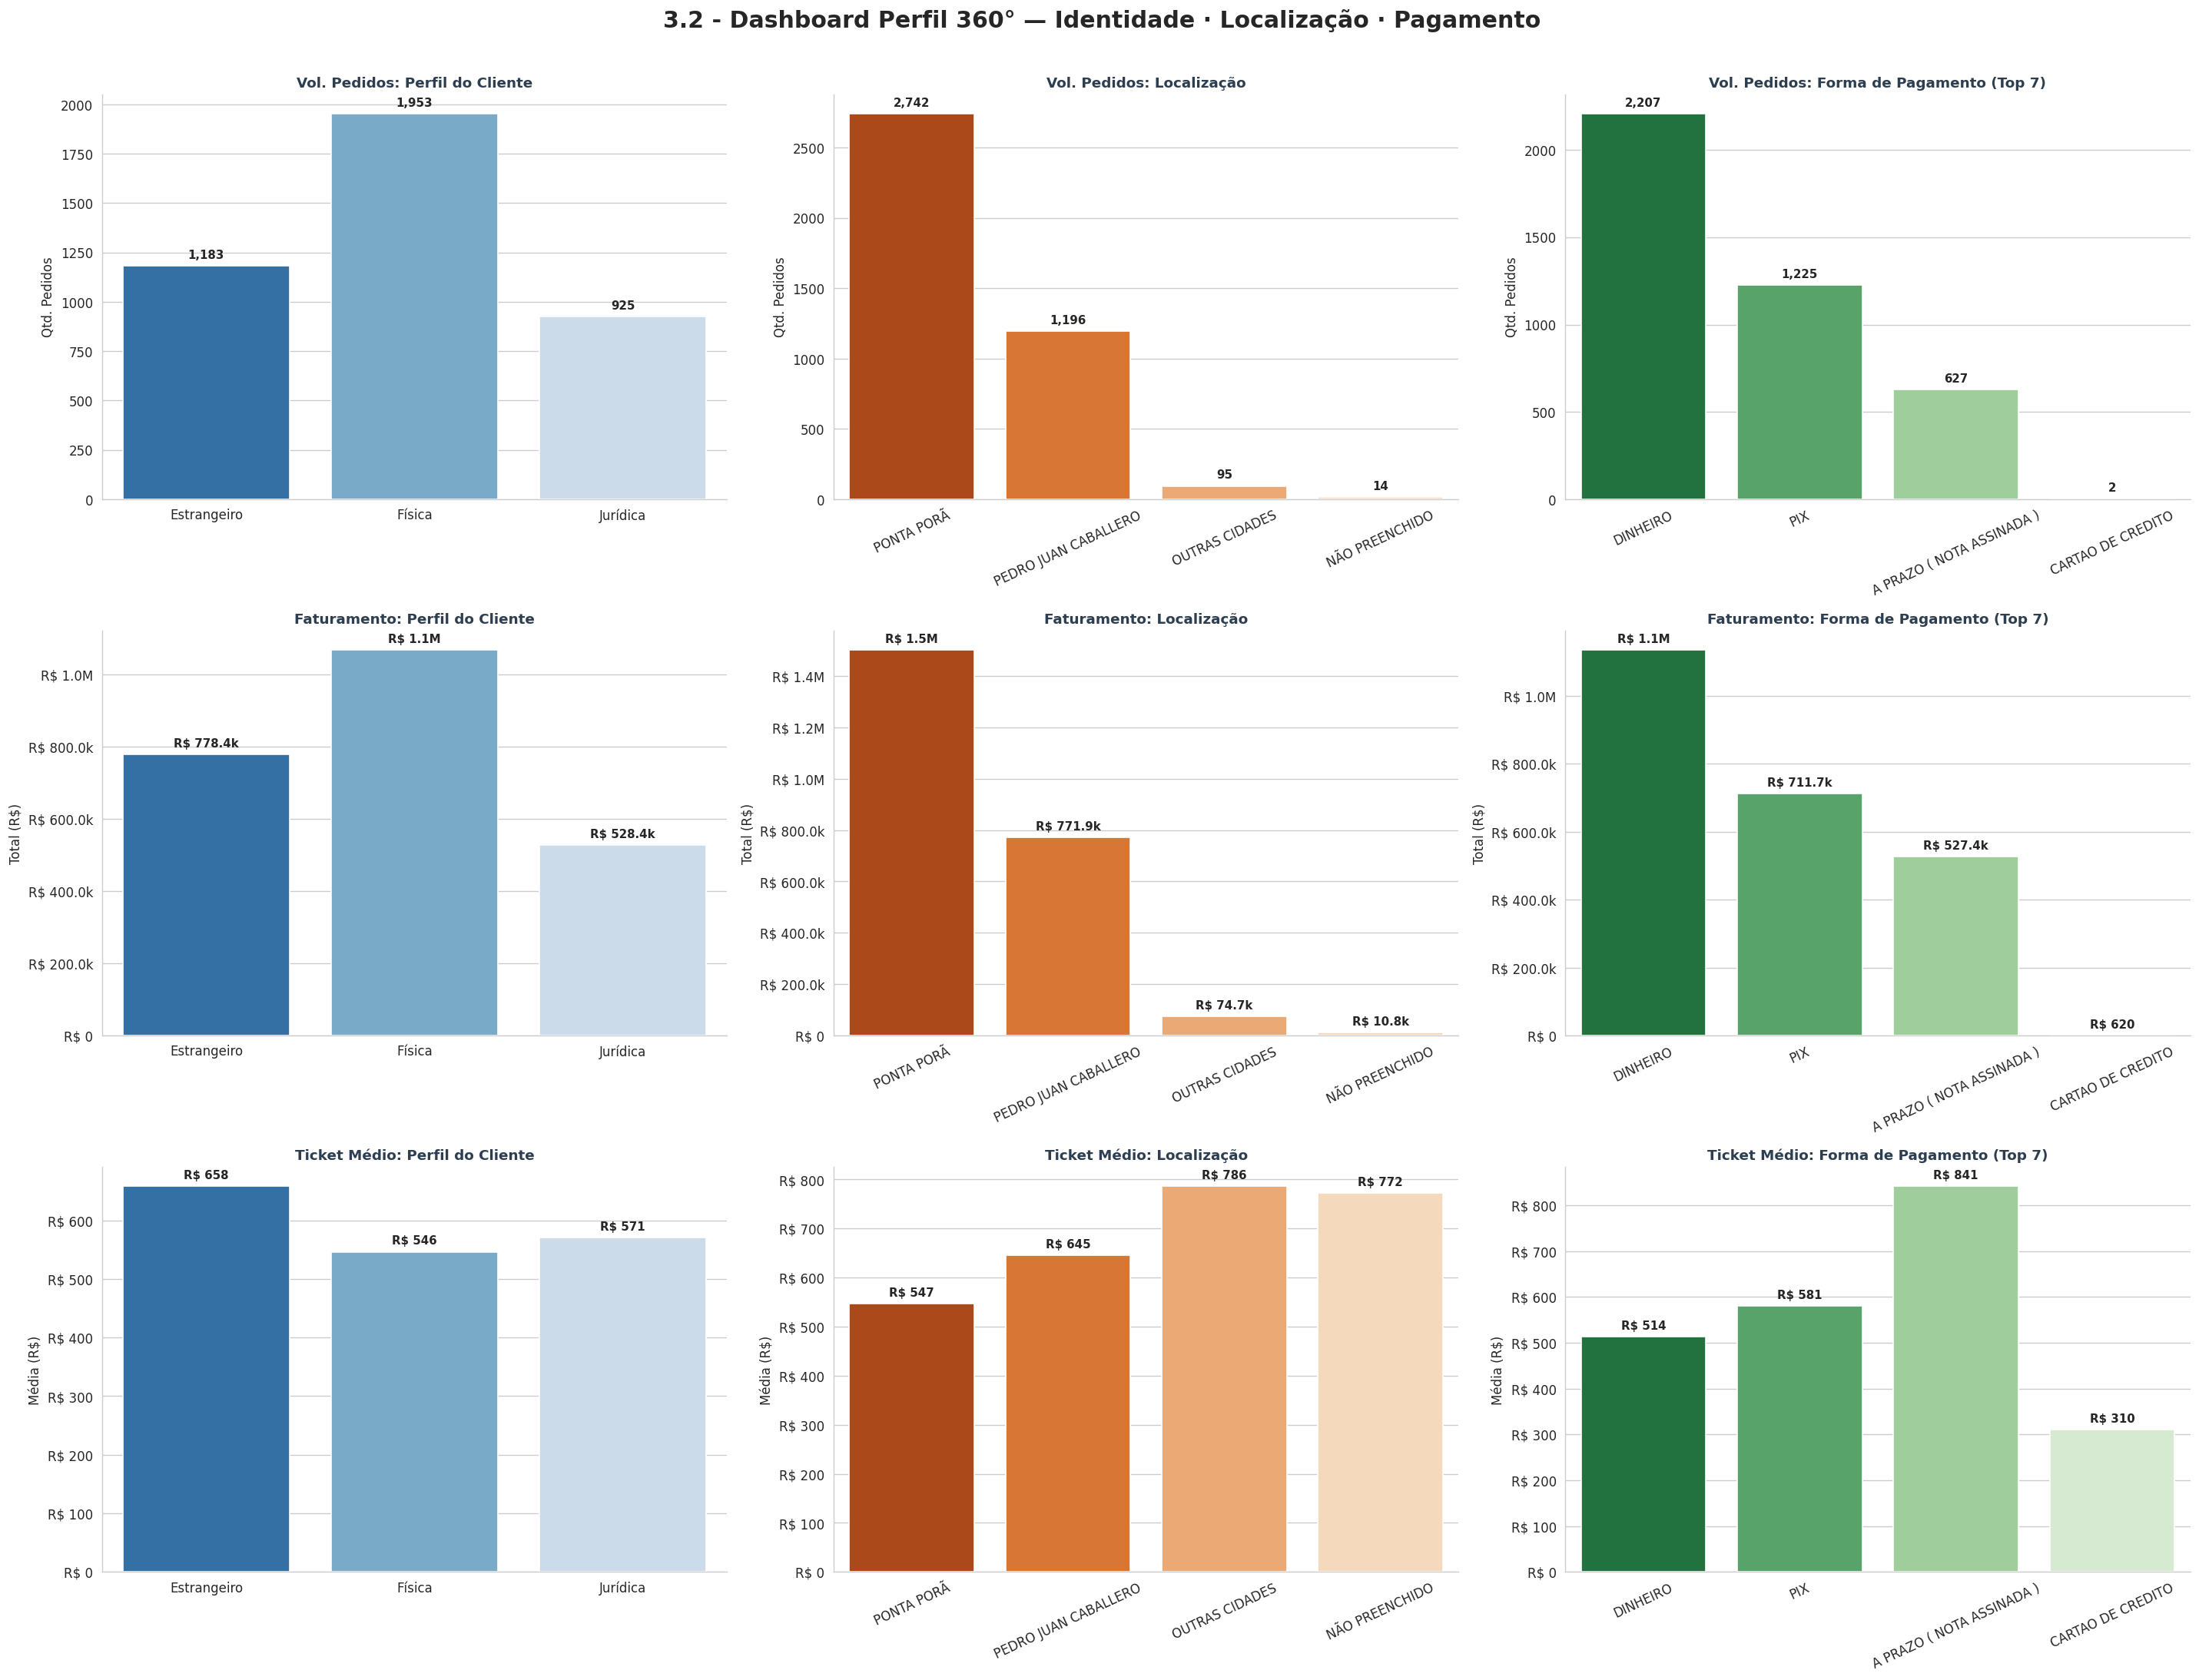

In [11]:
# ─── 3.2 Perfil 360° do Cliente ───────────────────────────────────────────────
df_dimensoes = build_dimensoes(tabelas_db)

df_cli_base = tabelas_db["TB_CLIENTE"][["ID_CLIENTE", "ID_PESSOA"]].copy()
df_360 = df_vendas_chopp.merge(df_cli_base, on="ID_PESSOA", how="inner").merge(
    df_dimensoes[["ID_PESSOA", "PERFIL", "CIDADE", "PAGAMENTO"]].drop_duplicates(
        "ID_PESSOA"
    ),
    on="ID_PESSOA",
    how="left",
)
df_360["CIDADE"] = df_360["CIDADE"].fillna("NÃO PREENCHIDO")
df_360["DT_PEDIDO"] = pd.to_datetime(df_360["DT_PEDIDO"], errors="coerce")


def add_labels(ax, is_money=False):
    """Anota valores no topo das barras."""
    for p in ax.patches:
        val = p.get_height()
        if val > 0:
            label = fmt_moeda(val) if is_money else f"{int(val):,}"
            ax.annotate(
                label,
                (p.get_x() + p.get_width() / 2, val),
                ha="center",
                va="bottom",
                fontweight="bold",
                fontsize=9,
                xytext=(0, 4),
                textcoords="offset points",
            )


fig, axes = plt.subplots(3, 3, figsize=(24, 18))
plt.subplots_adjust(hspace=0.55, wspace=0.3)

segmentos = ["PERFIL", "CIDADE", "PAGAMENTO"]
titulos_col = ["Perfil do Cliente", "Localização", "Forma de Pagamento (Top 7)"]
paletas = ["Blues_r", "Oranges_r", "Greens_r"]

for j, (seg, titulo) in enumerate(zip(segmentos, titulos_col)):
    df_t = (
        df_360.groupby(seg)
        .agg(QTD_PEDIDOS=("ID_PEDIDO", "nunique"), FATURAMENTO=("VL_FINANCEIRO", "sum"))
        .reset_index()
    )
    df_t["TICKET_MEDIO"] = df_t["FATURAMENTO"] / df_t["QTD_PEDIDOS"]

    if seg == "CIDADE":
        ordem = [
            "PONTA PORÃ",
            "PEDRO JUAN CABALLERO",
            "OUTRAS CIDADES",
            "NÃO PREENCHIDO",
        ]
        df_t = df_t.set_index(seg).reindex(ordem).reset_index().fillna(0)
    elif seg == "PAGAMENTO":
        df_t = df_t.sort_values("FATURAMENTO", ascending=False).head(7)

    for row, (col_y, is_money, ylabel) in enumerate(
        [
            ("QTD_PEDIDOS", False, "Qtd. Pedidos"),
            ("FATURAMENTO", True, "Total (R$)"),
            ("TICKET_MEDIO", True, "Média (R$)"),
        ]
    ):
        ax = axes[row, j]
        sns.barplot(
            data=df_t, x=seg, y=col_y, ax=ax, hue=seg, palette=paletas[j], legend=False
        )
        subtitulo = ["Vol. Pedidos", "Faturamento", "Ticket Médio"][row]
        ax.set_title(
            f"{subtitulo}: {titulo}", fontweight="bold", fontsize=11, color="#2C3E50"
        )
        ax.set_ylabel(ylabel)
        ax.set_xlabel("")
        if is_money:
            ax.yaxis.set_major_formatter(FuncFormatter(fmt_moeda))
        ax.tick_params(axis="x", rotation=25 if j > 0 else 0)
        add_labels(ax, is_money)

plt.suptitle(
    "3.2 - Dashboard Perfil 360° — Identidade · Localização · Pagamento",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)
sns.despine()
plt.tight_layout()

os.makedirs("imagens", exist_ok=True)
plt.savefig(
    "imagens/Dashboard_perfil_360.png",
    dpi=300,            # alta resolução
    bbox_inches="tight" # corta bordas extras
)

plt.show()


### 💡 Conclusão da Análise de Perfil (Insights e Georreferência Corrigida)

Com a correção da georreferência e a consolidação do *Dashboard 360º*, refinamos nosso entendimento do negócio e mapeamos os seguintes insights estratégicos:

1. **Identidade vs. Faturamento:** Pessoas Físicas lideram o volume absoluto de pedidos. No entanto, **Pessoas Jurídicas** e **Estrangeiros** sustentam os maiores Tickets Médios, confirmando o peso financeiro da operação transfronteiriça.
2. **Geografia e Correlação:** **Ponta Porã** é o núcleo da operação. O perfil Estrangeiro correlaciona-se diretamente com **Pedro Juan Caballero**. O volume residual em "Outras Cidades" exige atenção especial na logística de recolhimento das chopeiras.
3. **Liquidez (Pagamentos):** A predominância de **Dinheiro e Pix** garante o giro rápido do caixa. Modalidades "A Prazo" ficam restritas ao público B2B e internacional (maior ticket).

**🚀 Decisão Metodológica para Modelagem:**
A variável de localização (Cidades) foi saneada (97,7% de preenchimento) 

## ⚠️ 3.3 - Análise de Risco por Segmento

Compreendendo que o faturamento (Financeiro) e a remessa (Comodato) operam de forma independente no ERP, mudamos a granularidade do nosso cruzamento. Em vez de cruzar ID com ID, vamos analisar o **Risco do Pedido** sob a ótica das dimensões do cliente.

Para cada pedido de Venda/Financeiro e cada pedido de Empréstimo/Comodato, mapeamos:
1. **Identidade:** Pessoa Física, Jurídica ou Estrangeiro.
2. **Localização:** Ponta Porã, Pedro Juan Caballero, Outras e Não Informado.
3. **Liquidez:** Principais Formas de Pagamento.

**Objetivo:** Identificar qual perfil de cliente apresenta o maior percentual de atraso no pagamento (Risco de Crédito) e qual apresenta o maior percentual de retenção de equipamento (Risco de Ativo).

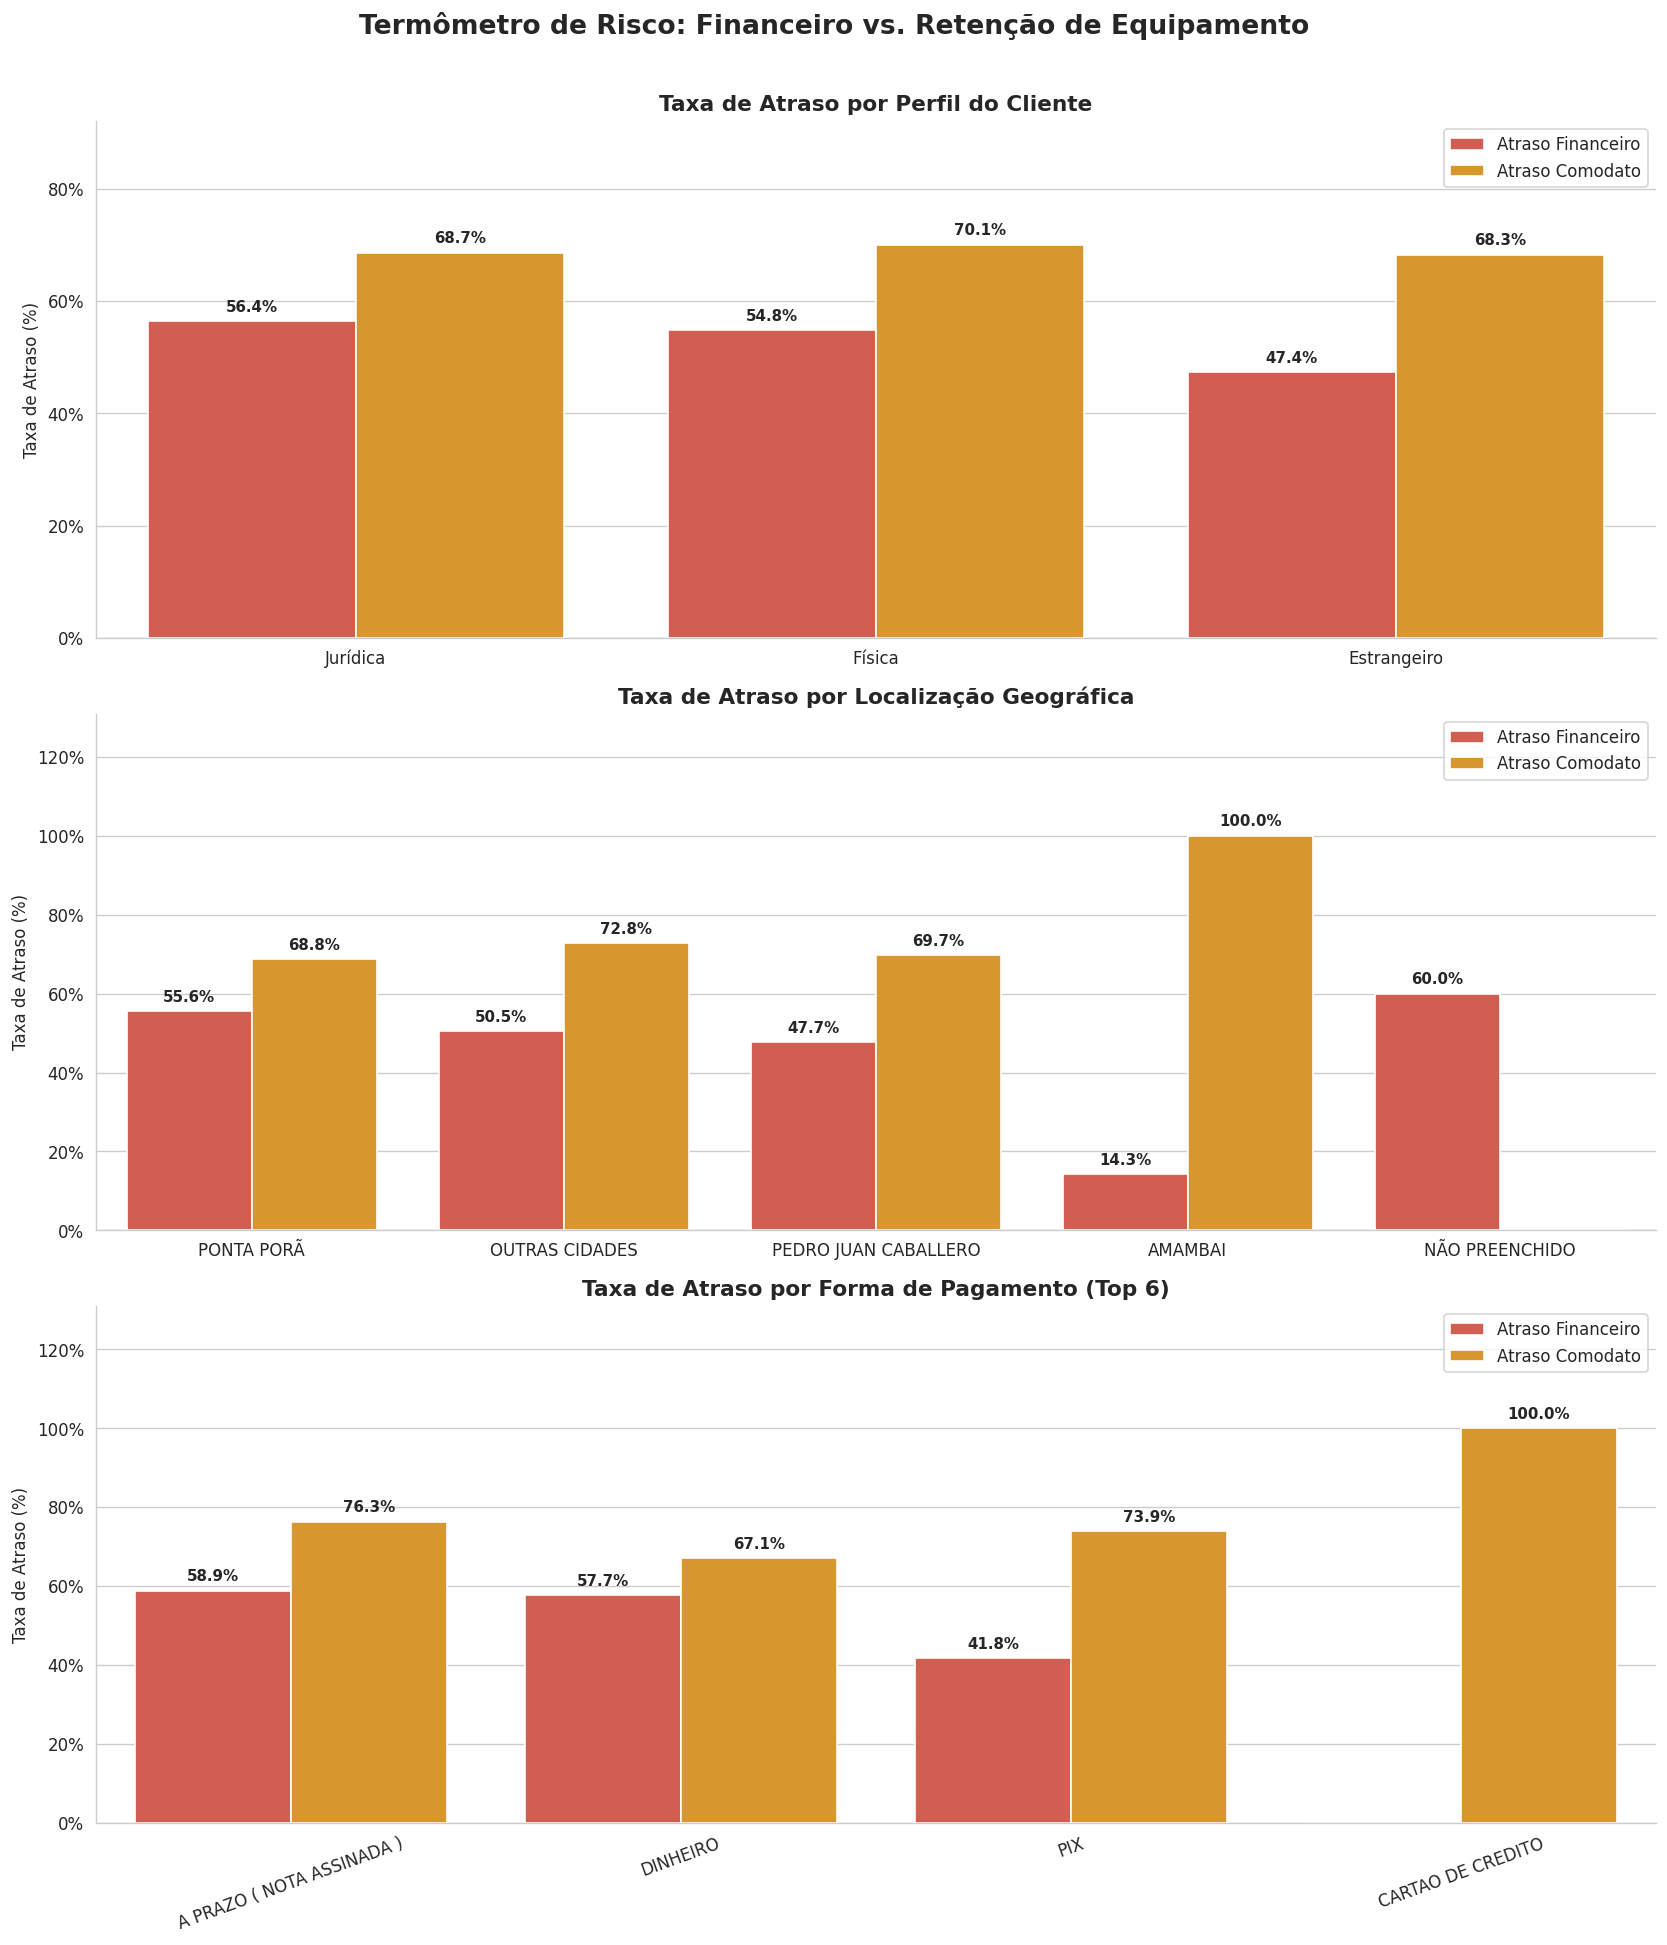

In [12]:
# ─── 3.3 Análise de Risco por Segmento ────────────────────────────────────
data_corte = pd.to_datetime(df_vendas_chopp["DT_PEDIDO"]).max()
df_fin_calc = calc_atraso_financeiro(df_financeiro, data_corte)
df_com_calc = calc_atraso_comodato(df_comodato, data_corte)

df_fin_ped = (
    df_fin_calc.groupby(["ID_PEDIDO", "ID_PESSOA"])
    .agg(RISCO_FIN=("ATRASOU_PAGAMENTO", "max"))
    .reset_index()
    .merge(
        df_dimensoes[["ID_PESSOA", "PERFIL", "CIDADE", "PAGAMENTO"]].drop_duplicates("ID_PESSOA"),
        on="ID_PESSOA",
        how="left",
    )
)

df_com_ped = (
    df_com_calc.groupby(["ID_PEDIDO", "ID_CLIENTE"])
    .agg(RISCO_COM=("ATRASOU_COMODATO", "max"))
    .reset_index()
    .merge(
        df_dimensoes[["ID_CLIENTE", "PERFIL", "CIDADE", "PAGAMENTO"]].drop_duplicates("ID_CLIENTE"),
        on="ID_CLIENTE",
        how="left",
    )
)

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
plt.subplots_adjust(hspace=0.5)

dimensoes_plot = [
    ("PERFIL", "Perfil do Cliente"),
    ("CIDADE", "Localização Geográfica"),
    ("PAGAMENTO", "Forma de Pagamento (Top 6)"),
]

for i, (dim, titulo) in enumerate(dimensoes_plot):
    df_f = df_fin_ped.groupby(dim)["RISCO_FIN"].mean().reset_index()
    df_c = df_com_ped.groupby(dim)["RISCO_COM"].mean().reset_index()
    df_plot = pd.merge(df_f, df_c, on=dim, how="outer").fillna(0)
    df_plot[["RISCO_FIN", "RISCO_COM"]] *= 100

    if dim == "PAGAMENTO":
        top6 = df_fin_ped[dim].value_counts().nlargest(6).index
        df_plot = df_plot[df_plot[dim].isin(top6)]

    df_plot = (
        df_plot.assign(TOTAL_RISK=lambda x: x["RISCO_FIN"] + x["RISCO_COM"])
        .sort_values("TOTAL_RISK", ascending=False)
        .drop(columns="TOTAL_RISK")
    )

    df_melt = df_plot.melt(
        id_vars=dim,
        value_vars=["RISCO_FIN", "RISCO_COM"],
        var_name="Tipo",
        value_name="Taxa",
    )
    df_melt["Tipo"] = df_melt["Tipo"].map(
        {"RISCO_FIN": "Atraso Financeiro", "RISCO_COM": "Atraso Comodato"}
    )

    ax = axes[i]
    sns.barplot(data=df_melt, x=dim, y="Taxa", hue="Tipo", ax=ax, palette=["#E74C3C", "#F39C12"])
    ax.set_title(f"Taxa de Atraso por {titulo}", fontweight="bold", fontsize=13)
    ax.set_ylabel("Taxa de Atraso (%)")
    ax.set_xlabel("")
    ax.set_ylim(0, df_melt["Taxa"].max() * 1.3 + 1)
    ax.yaxis.set_major_formatter(PercentFormatter())
    
    if dim == "PAGAMENTO":
        ax.tick_params(axis="x", rotation=20)
    for p in ax.patches:
        v = p.get_height()
        if v > 0.5:
            ax.annotate(
                f"{v:.1f}%",
                (p.get_x() + p.get_width() / 2, v),
                ha="center",
                va="bottom",
                fontweight="bold",
                fontsize=9,
                xytext=(0, 4),
                textcoords="offset points",
            )
    ax.legend(title="", loc="upper right", frameon=True)

plt.suptitle(
    "Termômetro de Risco: Financeiro vs. Retenção de Equipamento",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
sns.despine()
plt.tight_layout()

os.makedirs("imagens", exist_ok=True)
plt.savefig(
    "imagens/Termometro_Risco.png",
    dpi=300,            # alta resolução
    bbox_inches="tight" # corta bordas extras
)

plt.show()

### 💡 Conclusão: Termômetro de Risco e Comportamento por Segmento

A quebra do risco em trilhas paralelas (Financeiro vs. Comodato) revelou que a inadimplência e a retenção de equipamentos possuem motivadores diferentes. A partir do dashboard, extraímos os seguintes *insights* para a modelagem e para o negócio:

1. **Risco por Perfil do Cliente (Identidade):**
   * **Comodato:** O atraso na devolução de equipamentos é um problema crônico e generalizado, mantendo-se na faixa de **70%** para todos os públicos, com uma leve tendência de alta nas Pessoas Físicas.
   * **Financeiro:** Observamos uma clara divisão de fronteira. Clientes brasileiros (Pessoa Física e Jurídica) apresentam um risco de atraso financeiro na casa dos **55%**, enquanto o público **Estrangeiro** apresenta maior pontualidade, com o risco caindo para cerca de **47%**.

2. **Risco por Localização Geográfica (Logística):**
   * **Comodato (Distância = Risco):** Cidades vizinhas ("Outras Cidades") apresentam a maior taxa de atraso na devolução. Isso indica que a logística reversa perde eficiência quanto mais o equipamento se afasta do eixo Ponta Porã - Pedro Juan Caballero.
   * **Financeiro:** Curiosamente, o núcleo da operação (**Ponta Porã**) lidera a incidência de atrasos de pagamento. 
   * *Atenção Metodológica:* A categoria "Não Preenchido" apresentou altas taxas de atraso, mas, como mapeamos anteriormente, seu volume absoluto de pedidos é muito baixo. Para o treinamento do modelo preditivo, precisaremos tratar ou desconsiderar esses *outliers* para não enviesar o algoritmo.

3. **Risco por Forma de Pagamento (Liquidez):**
   * **O Fator Dinheiro:** Pedidos pagos em Dinheiro em espécie apresentam um risco ligeiramente menor de atraso na devolução da chopeira, possivelmente associados a transações mais rápidas e de balcão.
   * **A Oportunidade do PIX:** O pagamento via **Pix** desponta com o **menor risco de atraso financeiro** em comparação aos demais métodos (como boletos ou cartões a prazo). 
   * *Ação de Negócio:* Este é um *insight* altamente acionável. A distribuidora pode criar políticas de incentivo (como descontos no chopp ou isenção de taxa de entrega) para forçar a migração dos clientes para o Pix. Embora o risco do comodato ainda exista, o caixa da empresa fica garantido no tempo certo.

## ⏳ 3.4 Análise de "Aging"

Não basta saber *quem* atrasa; precisamos entender a **gravidade** desse atraso. Um cliente que atrasa a devolução da chopeira por 2 dias representa um gargalo logístico leve; um cliente que atrasa mais de 30 dias representa um alto risco de perda de ativo.

Para aprofundar nossa modelagem de risco, calculamos o tempo exato (em dias) de cada atraso e os agrupamos nas seguintes faixas de tolerância:
* **Leve:** 1 a 3 dias | 4 a 7 dias
* **Médio:** 8 a 15 dias | 16 a 20 dias
* **Crítico:** 21 a 30 dias | + de 30 dias

Abaixo, exploramos a volumetria absoluta de pedidos atrasados nessas faixas, cruzando o tempo de atraso (Financeiro e Comodato) com os perfis de cliente, localidade e métodos de pagamento.

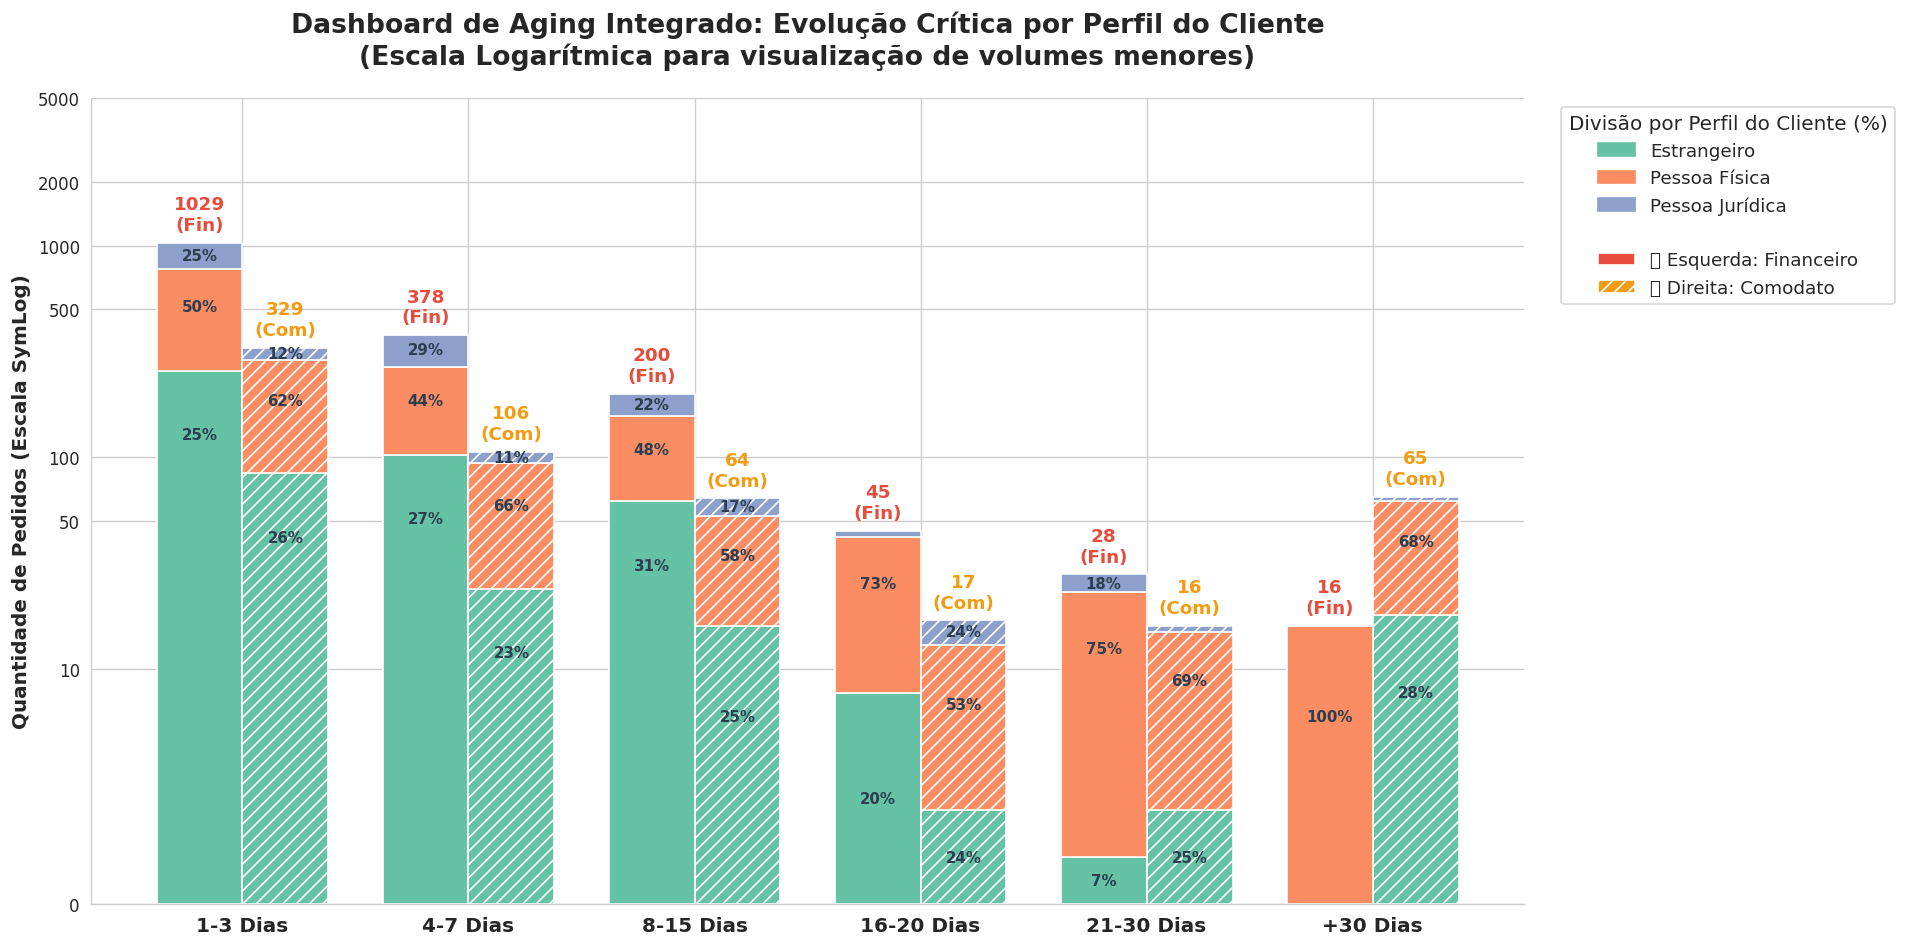

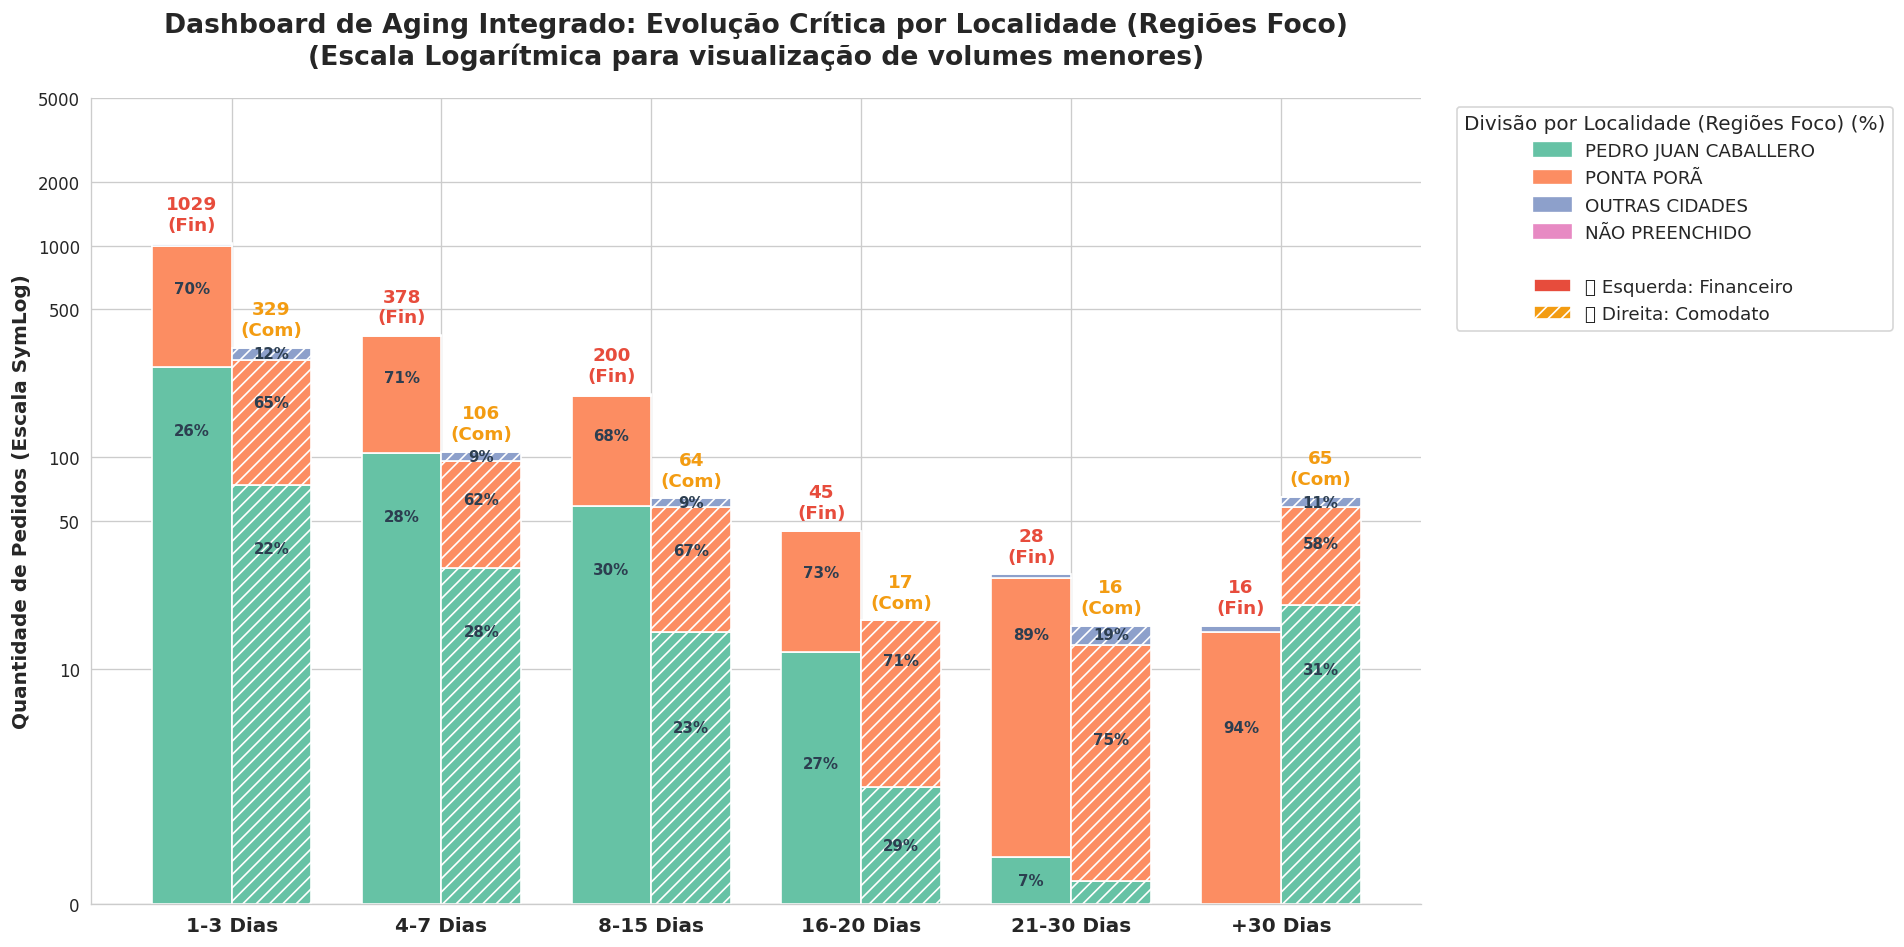

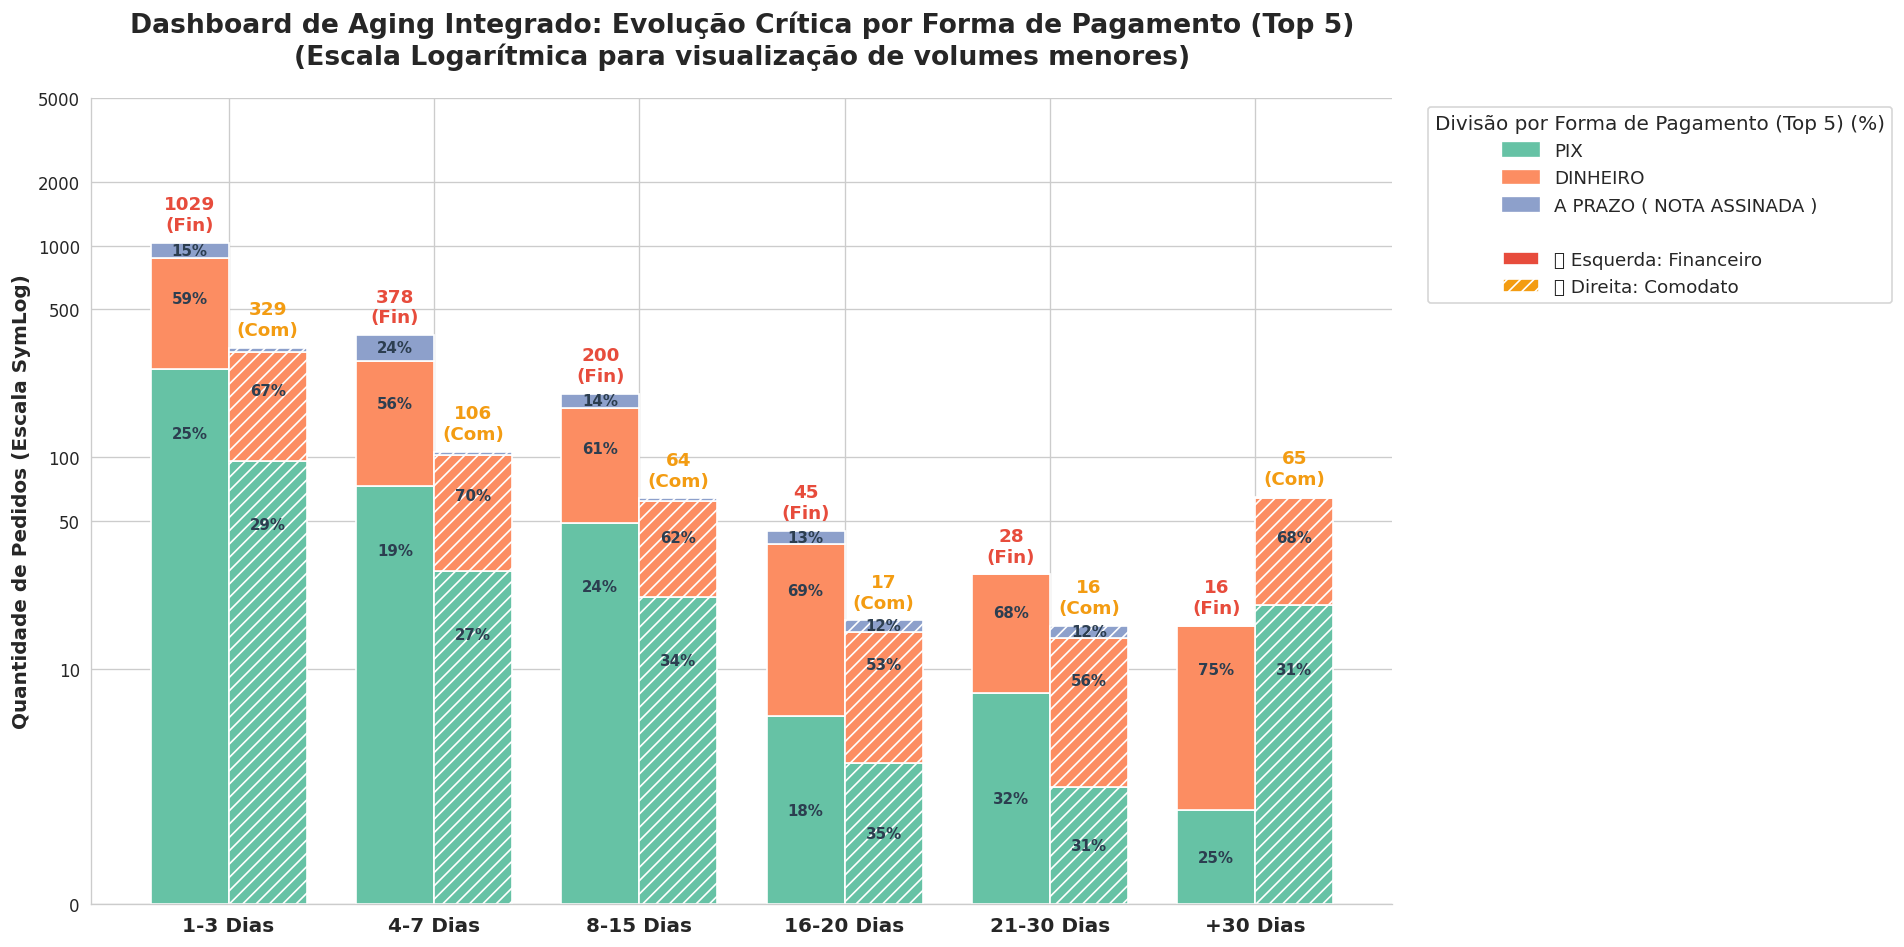

In [13]:

# ==============================================================================
# 3.4 CALCULANDO AS DIMENSÕES E O AGING 
# ==============================================================================
# Dimensões
df_pessoa_dim = tabelas_db['TB_PESSOA'][['ID_PESSOA', 'TP_TIPO']].copy()
df_pessoa_dim['PERFIL'] = df_pessoa_dim['TP_TIPO'].map({'F': 'Pessoa Física', 'J': 'Pessoa Jurídica', 'E': 'Estrangeiro'}).fillna('Não Informado')

df_loc = tabelas_db['TB_CLIENTE_ENDERECO'][['ID_CLIENTE', 'DS_CIDADE']].copy()
def agrupar_cidades(c):
    c = str(c).upper().strip()
    if 'PONTA POR' in c or 'SANGA' in c: return 'PONTA PORÃ'
    if 'PEDRO JUAN' in c: return 'PEDRO JUAN CABALLERO'
    if c in ['NAN', '', 'NONE', 'NÃO PREENCHIDO'] or pd.isna(c): return 'NÃO PREENCHIDO'
    return 'OUTRAS CIDADES'
df_loc['CIDADE'] = df_loc['DS_CIDADE'].apply(agrupar_cidades)
df_loc = df_loc.drop_duplicates('ID_CLIENTE')

df_cli = tabelas_db['TB_CLIENTE'][['ID_CLIENTE', 'ID_PESSOA', 'ID_FORMA_PAGAMENTO_1']].copy()
df_pgto = tabelas_db['TB_FORMA_PAGTO'][['ID_FORMA_PAGTO', 'DS_FORMA_PAGTO']].copy()
df_cli = df_cli.merge(df_pgto, left_on='ID_FORMA_PAGAMENTO_1', right_on='ID_FORMA_PAGTO', how='left')
df_cli['PAGAMENTO'] = df_cli['DS_FORMA_PAGTO'].fillna('OUTROS').str.upper()

df_dim = df_cli[['ID_CLIENTE', 'ID_PESSOA', 'PAGAMENTO']].merge(df_pessoa_dim[['ID_PESSOA', 'PERFIL']], on='ID_PESSOA', how='left')
df_dim = df_dim.merge(df_loc[['ID_CLIENTE', 'CIDADE']], on='ID_CLIENTE', how='left')
df_dim['CIDADE'] = df_dim['CIDADE'].fillna('NÃO PREENCHIDO')
df_dim['PERFIL'] = df_dim['PERFIL'].fillna('NÃO INFORMADO')

# Calculando Atrasos
data_corte = pd.to_datetime(df_vendas_chopp['DT_PEDIDO']).max() if 'DT_PEDIDO' in df_vendas_chopp.columns else pd.Timestamp.now()

def categorizar_atraso(dias):
    if dias <= 0: return 'No Prazo'
    elif dias <= 3: return '1-3 Dias'
    elif dias <= 7: return '4-7 Dias'
    elif dias <= 15: return '8-15 Dias'
    elif dias <= 20: return '16-20 Dias'
    elif dias <= 30: return '21-30 Dias'
    else: return '+30 Dias'

ordem_bins = ['1-3 Dias', '4-7 Dias', '8-15 Dias', '16-20 Dias', '21-30 Dias', '+30 Dias']

# Base Financeiro
df_fin = df_financeiro.copy()
df_fin['DT_VENCIMENTO'] = pd.to_datetime(df_fin['DT_VENCIMENTO'], errors='coerce')
col_pgto = 'DT_BAIXA' if 'DT_BAIXA' in df_fin.columns else 'DT_RECEBIMENTO'
df_fin[col_pgto] = pd.to_datetime(df_fin[col_pgto], errors='coerce')
df_fin['DT_PGTO_EFETIVO'] = df_fin[col_pgto].fillna(data_corte)
df_fin['DIAS_ATRASO'] = (df_fin['DT_PGTO_EFETIVO'] - df_fin['DT_VENCIMENTO']).dt.days

df_fin_ped = df_fin.groupby(['ID_PEDIDO', 'ID_PESSOA']).agg(MAX_DIAS=('DIAS_ATRASO', 'max')).reset_index()
df_fin_ped = df_fin_ped[df_fin_ped['MAX_DIAS'] > 0].copy()
df_fin_ped['Aging'] = df_fin_ped['MAX_DIAS'].apply(categorizar_atraso)
df_fin_ped = df_fin_ped.merge(df_dim.drop_duplicates('ID_PESSOA'), on='ID_PESSOA', how='left')
df_fin_ped['Tipo'] = 'Financeiro'

# Base Comodato
df_com = df_comodato.copy()
df_com['DT_VENCIMENTO'] = pd.to_datetime(df_com['DT_VENCIMENTO'], errors='coerce')
df_com['DT_RECOLHE'] = pd.to_datetime(df_com['DT_RECOLHE'], errors='coerce')
df_com['DT_REC_EFETIVO'] = df_com['DT_RECOLHE'].fillna(data_corte)
df_com['DIAS_ATRASO'] = (df_com['DT_REC_EFETIVO'] - df_com['DT_VENCIMENTO']).dt.days

df_com_ped = df_com.groupby(['ID_PEDIDO', 'ID_CLIENTE']).agg(MAX_DIAS=('DIAS_ATRASO', 'max')).reset_index()
df_com_ped = df_com_ped[df_com_ped['MAX_DIAS'] > 0].copy()
df_com_ped['Aging'] = df_com_ped['MAX_DIAS'].apply(categorizar_atraso)
df_com_ped = df_com_ped.merge(df_dim.drop_duplicates('ID_CLIENTE'), on='ID_CLIENTE', how='left')
df_com_ped['Tipo'] = 'Comodato'

# Tabela Mestre Única
cols = ['ID_PEDIDO', 'PERFIL', 'CIDADE', 'PAGAMENTO', 'Aging', 'Tipo']
df_master = pd.concat([df_fin_ped[cols], df_com_ped[cols]], ignore_index=True)

# ==============================================================================
# 2. FUNÇÃO: DASHBOARD EMPILHADO (COM LOG SCALE E PORCENTAGEM)
# ==============================================================================
def plot_grouped_stacked(dimensao, titulo_dim, top_n=None):
    df_plot = df_master.copy()
    if top_n:
        top_items = df_plot[dimensao].value_counts().nlargest(top_n).index
        df_plot = df_plot[df_plot[dimensao].isin(top_items)]
        
    grouped = df_plot.groupby(['Aging', 'Tipo', dimensao]).size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    x = np.arange(len(ordem_bins))
    width = 0.38 
    
    categorias = list(df_plot[dimensao].dropna().unique())
    colors = sns.color_palette("Set2", len(categorias)) 
    
    idx_fin = pd.MultiIndex.from_product([ordem_bins, ['Financeiro']], names=['Aging', 'Tipo'])
    idx_com = pd.MultiIndex.from_product([ordem_bins, ['Comodato']], names=['Aging', 'Tipo'])
    
    fin_data = grouped.reindex(idx_fin).fillna(0)
    com_data = grouped.reindex(idx_com).fillna(0)
    
    for cat in categorias:
        if cat not in fin_data.columns: fin_data[cat] = 0
        if cat not in com_data.columns: com_data[cat] = 0
        
    fin_vals = fin_data[categorias].values
    com_vals = com_data[categorias].values
    
    # Calculando os totais de cada coluna para a porcentagem
    total_fin = fin_vals.sum(axis=1)
    total_com = com_vals.sum(axis=1)
    
    bottom_fin = np.zeros(len(ordem_bins))
    bottom_com = np.zeros(len(ordem_bins))
    
    for i, cat in enumerate(categorias):
        # Desenhando Coluna Financeiro
        ax.bar(x - width/2, fin_vals[:, i], width, bottom=bottom_fin, color=colors[i], edgecolor='white')
        
        # Desenhando Coluna Comodato
        ax.bar(x + width/2, com_vals[:, i], width, bottom=bottom_com, color=colors[i], edgecolor='white', hatch='///')
        
        # Inserindo os Rótulos de Porcentagem DENTRO dos blocos
        for j in range(len(ordem_bins)):
            # Porcentagem Fin
            if fin_vals[j, i] > 0 and total_fin[j] > 0:
                pct_f = (fin_vals[j, i] / total_fin[j]) * 100
                if pct_f >= 7: # Só exibe se for > 7% para não poluir blocos muito finos
                    y_pos = bottom_fin[j] + (fin_vals[j, i] / 2)
                    ax.text(x[j] - width/2, y_pos, f'{pct_f:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='#2C3E50')
            
            # Porcentagem Com
            if com_vals[j, i] > 0 and total_com[j] > 0:
                pct_c = (com_vals[j, i] / total_com[j]) * 100
                if pct_c >= 7:
                    y_pos = bottom_com[j] + (com_vals[j, i] / 2)
                    ax.text(x[j] + width/2, y_pos, f'{pct_c:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='#2C3E50')
        
        # Atualizando os "andares" para o próximo empilhamento
        bottom_fin += fin_vals[:, i]
        bottom_com += com_vals[:, i]
        
    # Colocando os TOTAIS em cima das colunas
    for i in range(len(ordem_bins)):
        if bottom_fin[i] > 0:
            ax.text(x[i] - width/2, bottom_fin[i] * 1.1, f'{int(bottom_fin[i])}\n(Fin)', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#E74C3C')
        if bottom_com[i] > 0:
            ax.text(x[i] + width/2, bottom_com[i] * 1.1, f'{int(bottom_com[i])}\n(Com)', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#F39C12')
            
    ax.set_xticks(x)
    ax.set_xticklabels(ordem_bins, fontsize=12, fontweight='bold')
    
    # === A MÁGICA DA ESCALA AQUI ===
    ax.set_yscale('symlog', linthresh=10)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter()) # Tira o 10^2 e volta para números reais
    ax.set_yticks([0, 10, 50, 100, 500, 1000, 2000, 5000]) # Força marcas bonitas
    
    # Legenda
    handles = [mpatches.Patch(color=colors[i], label=cat) for i, cat in enumerate(categorias)]
    handles.append(mpatches.Patch(facecolor='none', edgecolor='none', label=' '))
    handles.append(mpatches.Patch(facecolor='#E74C3C', edgecolor='white', label='💳 Esquerda: Financeiro'))
    handles.append(mpatches.Patch(facecolor='#F39C12', edgecolor='white', hatch='///', label='🛢️ Direita: Comodato'))
    
    ax.legend(handles=handles, title=f"Divisão por {titulo_dim} (%)", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=12)
    ax.set_title(f'Dashboard de Aging Integrado: Evolução Crítica por {titulo_dim}\n(Escala Logarítmica para visualização de volumes menores)', fontweight='bold', fontsize=16, pad=20)
    ax.set_ylabel('Quantidade de Pedidos (Escala SymLog)', fontsize=12, fontweight='bold')
    
    sns.despine()
    plt.tight_layout()
    
    os.makedirs("imagens", exist_ok=True)
    plt.savefig(
        "imagens/Dashboard_Aging.png",
        dpi=300,            # alta resolução
        bbox_inches="tight" # corta bordas extras
    )

    plt.show()

# ==============================================================================
# 3. GERANDO OS GRÁFICOS
# ==============================================================================
plot_grouped_stacked('PERFIL', 'Perfil do Cliente')
plot_grouped_stacked('CIDADE', 'Localidade (Regiões Foco)')
plot_grouped_stacked('PAGAMENTO', 'Forma de Pagamento (Top 5)', top_n=5)

### 💡 Conclusão: Análise de Aging e Padrões de Retenção Crítica

Para garantir uma leitura precisa do comportamento de atrasos, aplicamos uma **Escala Logarítmica Simétrica (SymLog)** na visualização. Essa técnica foi fundamental para contornar o efeito de "cauda longa" dos dados, permitindo que os blocos com volumes massivos (centenas ou milhares de pedidos com atraso curto) não esmagassem visualmente as ocorrências críticas (menor volume, porém de altíssimo risco).

A partir dessa visualização ajustada, destacamos os seguintes comportamentos iniciais:

1. **Concentração de Curto Prazo:** De maneira geral, a grande esmagadora maioria dos atrasos (tanto financeiros quanto de devolução de comodato) se resolve na janela de **até 15 dias**. Isso indica que boa parte da inadimplência não é má-fé, mas sim desorganização, esquecimento ou delay logístico natural.

2. **A Cauda Crítica (+30 Dias):** Embora o volume caia expressivamente após a barreira de 15 dias, a quantidade de pedidos que ultrapassam os 30 dias de atraso ainda é preocupante para o caixa e para a retenção de ativos da empresa.

3. **Proporcionalidade vs. Risco Real:** Nos atrasos curtos, a distribuição acompanha a proporção natural da base de clientes. No entanto, quando olhamos para a faixa mais crítica (21 a 30+ dias), começam a surgir desvios de comportamento que merecem atenção especial.

## 📅 3.5 - Série Histórica


### 📈 Panorama Histórico: Evolução de Faturamento e Volume de Pedidos

Antes de aprofundarmos nas métricas de risco, inadimplência e comodato, observaremos a "fotografia geral" do crescimento da distribuidora. O gráfico a seguir apresenta a evolução histórica de vendas, mês a mês, desde o início dos registros operacionais na base até os dados mais recentes.

Para correlacionar o crescimento financeiro com o volume operacional, a visualização foi estruturada em **Duplo Eixo**:

* **Gráfico de Barras Empilhadas (Receita Bruta):** O eixo esquerdo controla as colunas, que representam o total faturado no mês. As barras são fatiadas por cores para demonstrar, em valores absolutos e percentuais, qual foi a exata contribuição de cada Perfil de Cliente (Pessoa Física, Pessoa Jurídica e Estrangeiro) na formação do caixa.
* **Gráfico de Linhas (Volume de Pedidos):** O eixo direito controla a linha contínua, que acompanha a quantidade total de pedidos únicos realizados. 

Esse cruzamento é estratégico: ele permite identificar rapidamente se os picos de receita foram gerados por um volume massivo de vendas (muitas entregas) ou se foram impulsionados por clientes de alto valor agregado (como Jurídicos e Estrangeiros) elevando o Ticket Médio do mês.

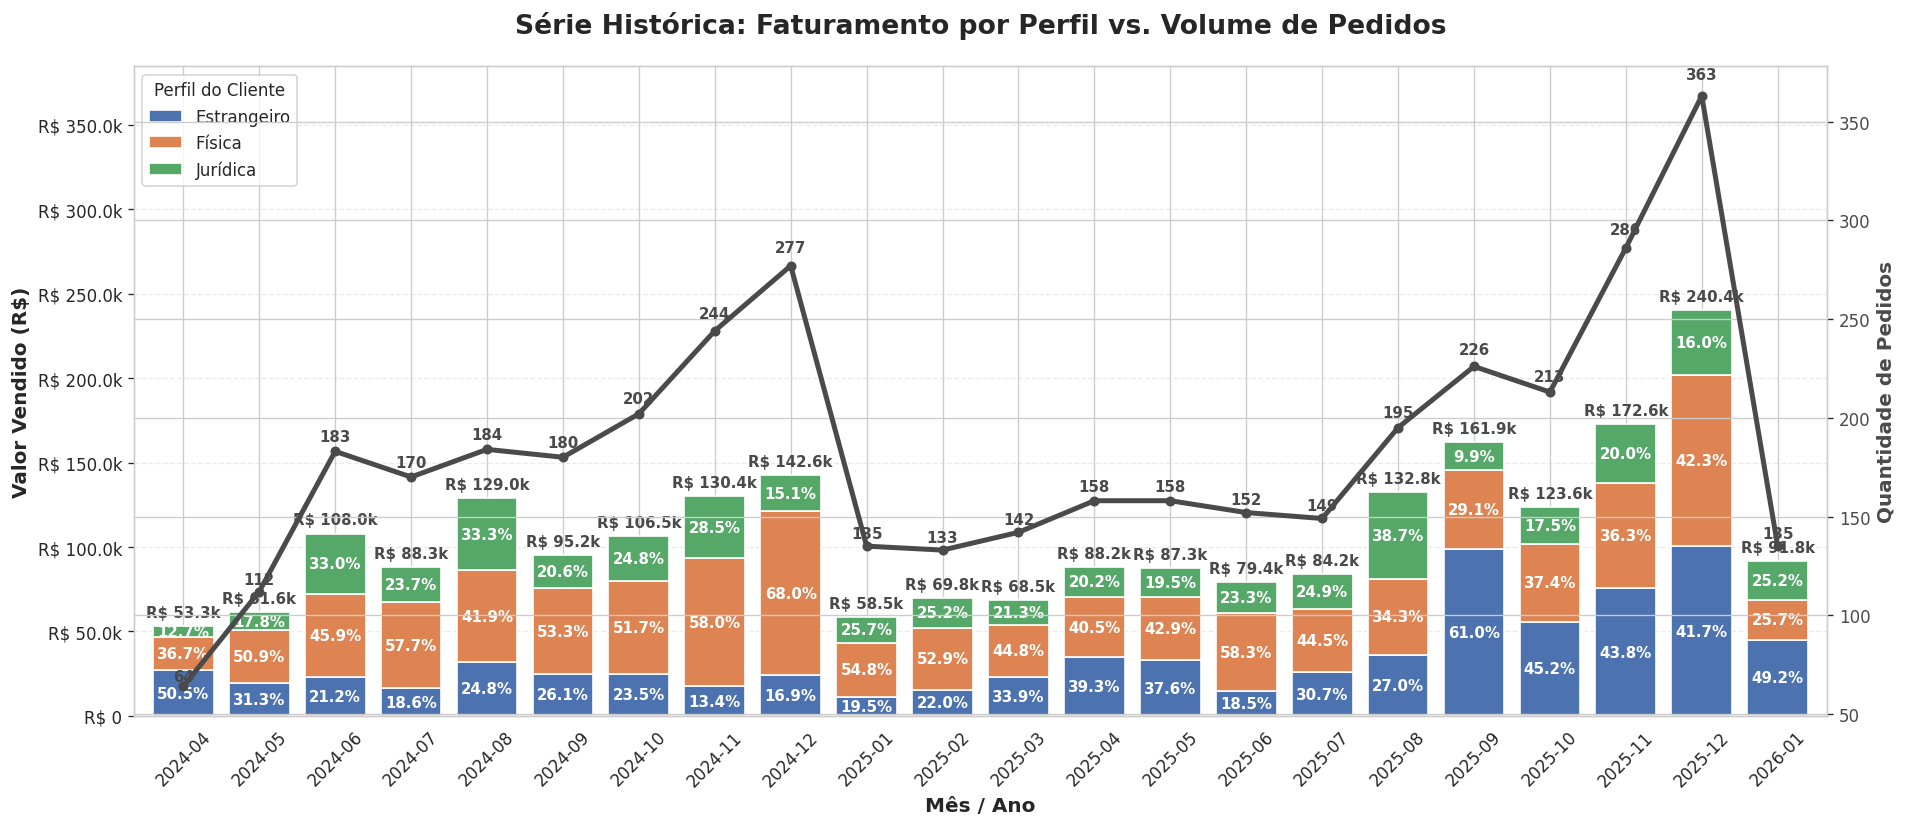

In [14]:
# =====================================================================
# 1. PREPARAÇÃO DOS DADOS (Usando o seu df_360 já consolidado)
# =====================================================================

# Criando a cópia a partir do dataframe completo que você gerado antes
df_plot = df_360.copy()

# 1.1 Criação da coluna de Ano/Mês para o Eixo X (usando DT_PEDIDO)
df_plot['ANO_MES'] = df_plot['DT_PEDIDO'].dt.to_period('M').astype(str)

# 1.2 Agrupamento das Barras (Valor por Mês e por Perfil de cliente)
# Nota: Mantive VALOR_TOTAL. Se no seu banco for outro nome (ex: VALOR), altere aqui.
df_barras = df_plot.groupby(['ANO_MES', 'PERFIL'])['VL_FINANCEIRO'].sum().reset_index()

# Pivotando para criar as colunas de cada perfil para as barras empilhadas
df_pivot = df_barras.pivot(index='ANO_MES', columns='PERFIL', values='VL_FINANCEIRO').fillna(0)

# 1.3 Agrupamento da Linha (Quantidade única de pedidos por mês)
df_linha = df_plot.groupby('ANO_MES')['ID_PEDIDO'].nunique().reset_index()


# =====================================================================
# 2. PLOTAGEM DO GRÁFICO (Eixo Duplo)
# =====================================================================

fig, ax1 = plt.subplots(figsize=(16, 7))

# --- EIXO 1 (Esquerda): Barras Empilhadas (Valor Vendido por Perfil) ---

cores_perfis = ['#4C72B0', '#DD8452', '#55A868']

df_pivot.plot(kind='bar', stacked=True, ax=ax1, color=cores_perfis, edgecolor='white', width= 0.8)

# Configurações do Eixo 1
ax1.set_ylim(0, df_pivot.sum(axis=1).max() * 1.60)
ax1.set_xlabel('Mês / Ano', fontsize=12, fontweight='bold')
ax1.set_ylabel('Valor Vendido (R$)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Perfil do Cliente', loc='upper left')

# Formatação de moeda no Eixo Y (chama a sua função utilitária de formatação)
# Ajuste o nome 'formatar_moeda' caso a sua função na Fase 0 tenha outro nome
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: fmt_moeda(x)))

# =====================================================================
# ADICIONAR RÓTULOS: % INTERNA E VALOR TOTAL NO TOPO
# =====================================================================

# 1. Calcula o faturamento total de cada mês (base para as % e para o rótulo do topo)
totais_mensais = df_pivot.sum(axis=1).values

# 2. Cria uma lista para rastrear a altura real do topo de cada barra
altura_topo_barra = [0] * len(df_pivot)

# 3. Loop para colocar as porcentagens (%) dentro de cada fatia da barra
for container in ax1.containers:
    for idx, patch in enumerate(container):
        altura_bloco = patch.get_height()
        y_inicio = patch.get_y()
        
        # Rastreia qual é o ponto mais alto alcançado pela barra deste mês
        if (y_inicio + altura_bloco) > altura_topo_barra[idx]:
            altura_topo_barra[idx] = y_inicio + altura_bloco

        if altura_bloco > 0:  
            total_do_mes = totais_mensais[idx]
            porcentagem = (altura_bloco / total_do_mes) * 100
            
            # Só escreve a % se o bloco for maior que 3% (evita amontoar texto)
            if porcentagem > 3:
                x_centro = patch.get_x() + patch.get_width() / 2
                y_centro = y_inicio + altura_bloco / 2
                
                ax1.text(x_centro, y_centro, f'{porcentagem:.1f}%', 
                         ha='center', va='center', color='white', 
                         fontweight='bold', fontsize=9)

# 4. Loop para colocar o VALOR TOTAL DO MÊS no topo de cada barra empilhada
for idx, total in enumerate(totais_mensais):
    x_pos_barra = idx  
    y_pos_topo = altura_topo_barra[idx]
    
    # Exibe o valor total do mês usando a sua função utilitária fmt_moeda
    ax1.text(x_pos_barra, y_pos_topo + (df_pivot.sum(axis=1).max() * 0.015), fmt_moeda(total),
             ha='center', va='bottom', color='#4A4A4A', 
             fontweight='bold', fontsize=9, rotation=0)

# --- EIXO 2 (Direita): Gráfico de Linha (Quantidade de Pedidos) ---
ax2 = ax1.twinx() # Compartilha o mesmo eixo X do ax1

# Garante o alinhamento perfeito da linha no centro das barras
x_pos = range(len(df_pivot.index))

ax2.plot(x_pos, df_linha['ID_PEDIDO'], color='#4A4A4A', marker='o', linewidth=3, markersize=5, label='Qtd Pedidos')

# Configurações do Eixo 2
ax2.set_ylabel('Quantidade de Pedidos', fontsize=12, fontweight='bold', color='#4A4A4A')
ax2.tick_params(axis='y', labelcolor='#4A4A4A')

# Adiciona os números (rótulos) acima de cada ponto da linha
for i, v in enumerate(df_linha['ID_PEDIDO']):
    ax2.text(i, v + (v * 0.02), str(v), color='#4A4A4A', ha='center', va='bottom', fontweight='bold',fontsize=9)


# --- FINALIZAÇÃO E AJUSTES VISUAIS ---
plt.title('Série Histórica: Faturamento por Perfil vs. Volume de Pedidos', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4) # Grid discreto apenas na horizontal
plt.tight_layout()

os.makedirs("imagens", exist_ok=True)
plt.savefig(
    "imagens/Serie_Historica_1.png",
    dpi=300,            # alta resolução
    bbox_inches="tight" # corta bordas extras
)

plt.show()

#### 💡 Insights: Evolução Histórica e Sazonalidade

A análise do panorama histórico nos revela padrões de consumo fundamentais para o planejamento estratégico e para o nosso modelo preditivo:

1. **Potencial de Crescimento e Impulso Estrangeiro:** Ao compararmos a trajetória de vendas de 2024 com a tração observada em 2025, notamos um claro viés de alta no faturamento e no volume de transações. Esse avanço vem sendo impulsionado fortemente pela maior participação das vendas para o perfil **Estrangeiro**, reforçando a importância estratégica da operação transfronteiriça para a escalabilidade e o Ticket Médio do negócio.

2. **Forte Sazonalidade (Último Quadrimestre):** O gráfico evidencia picos operacionais sazonais muito bem definidos. Observamos uma alta considerável na demanda nos meses de reta final de ano (especialmente no período entre **setembro e dezembro**). Esse aquecimento natural — atrelado a festividades, eventos e altas temperaturas — exige da distribuidora um preparo logístico robusto não apenas para a entrega do chopp, mas para o gerenciamento de risco no comodato das chopeiras, que rodam com a capacidade máxima nesses meses.

### 📅 Evolução Histórica do Gargalo (Financeiro vs. Logístico)

Para concluir nossa análise exploratória, saímos da visão estática de "quem" e "onde" para entender **quando** os problemas ocorrem. Esta visão cronológica é vital para separar a sazonalidade do negócio da degradação da carteira de cobrança.

**O gráfico abaixo apresenta dois eixos distintos:**
1. 🔴 **Eixo Financeiro (Barras):** Valor total em Reais (R$) de parcelas que venceram e não foram pagas no prazo (ou continuam em aberto).
2. 🟠 **Eixo Logístico (Linha):** Quantidade total de equipamentos (unidades) que deveriam ter retornado mas sofreram atraso ou retenção.

Cruzando essas duas métricas, conseguimos visualizar o impacto direto no fluxo de caixa e no giro de estoque de ativos da distribuidora ao longo do tempo.

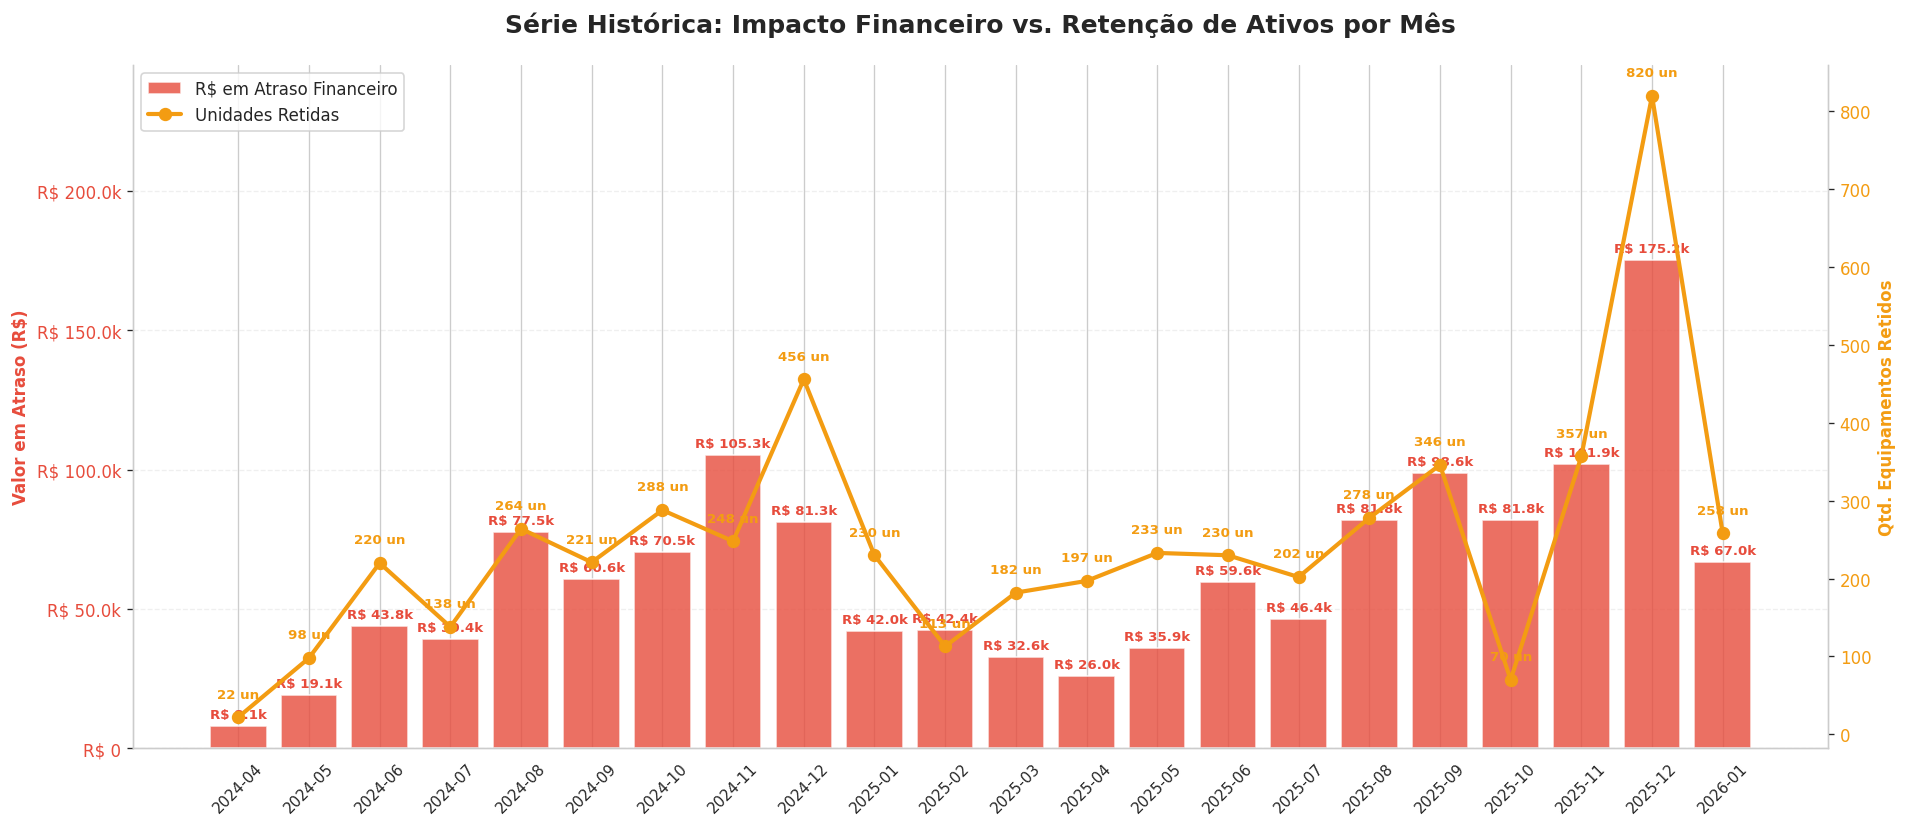

In [15]:
# ─── 3.5 Série Histórica ──────────────────────────────────────────────────────
hist_fin_atraso = (
    df_fin_calc[df_fin_calc["ATRASOU_PAGAMENTO"] == 1]
    .assign(MES_ANO=lambda x: pd.to_datetime(x["DT_VENCIMENTO"]).dt.to_period("M"))
    .groupby("MES_ANO")["VL_PARCELA"]
    .sum()
    .reset_index()
)

hist_com_atraso = (
    df_com_calc[df_com_calc["ATRASOU_COMODATO"] == 1]
    .assign(MES_ANO=lambda x: pd.to_datetime(x["DT_VENCIMENTO"]).dt.to_period("M"))
    .groupby("MES_ANO")["QTD_PRODUTO"]
    .sum()
    .reset_index()
)

df_hist_atraso = (
    pd.merge(hist_fin_atraso, hist_com_atraso, on="MES_ANO", how="outer")
    .fillna(0)
    .sort_values("MES_ANO")
)
df_hist_atraso["MES_STR"] = df_hist_atraso["MES_ANO"].astype(str)

fig, ax1 = plt.subplots(figsize=(16, 7))
cor_fin, cor_com = "#E74C3C", "#F39C12"
bars = ax1.bar(
    df_hist_atraso["MES_STR"],
    df_hist_atraso["VL_PARCELA"],
    color=cor_fin,
    alpha=0.8,
    label="R$ em Atraso Financeiro",
)
ax1.set_ylabel("Valor em Atraso (R$)", color=cor_fin, fontweight="bold")
ax1.yaxis.set_major_formatter(FuncFormatter(fmt_moeda))
ax1.tick_params(axis="y", labelcolor=cor_fin)
ax1.tick_params(axis="x", rotation=45, labelsize=9)
ax1.set_ylim(0, df_hist_atraso["VL_PARCELA"].max() * 1.4)

ax2 = ax1.twinx()
ax2.plot(
    df_hist_atraso["MES_STR"],
    df_hist_atraso["QTD_PRODUTO"],
    color=cor_com,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Unidades Retidas",
)
ax2.set_ylabel("Qtd. Equipamentos Retidos", color=cor_com, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=cor_com)
ax2.grid(False)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax1.annotate(
            fmt_moeda(h),
            (bar.get_x() + bar.get_width() / 2, h),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color=cor_fin,
            xytext=(0, 3),
            textcoords="offset points",
        )

for x, y in zip(df_hist_atraso['MES_STR'], df_hist_atraso['QTD_PRODUTO']):
    if y > 0:
        ax2.annotate(f'{int(y)} un', (x, y), ha='center', va='bottom', xytext=(0,10), 
                     textcoords='offset points', fontsize=8, fontweight='bold', color=cor_com)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.3)
plt.title(
    "Série Histórica: Impacto Financeiro vs. Retenção de Ativos por Mês",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
sns.despine(right=False)
plt.tight_layout()

os.makedirs("imagens", exist_ok=True)
plt.savefig(
    "imagens/Serie_Historica_2.png",
    dpi=300,            # alta resolução
    bbox_inches="tight" # corta bordas extras
)

plt.show()

#### 💡 Conclusão: Evolução Histórica e o Gargalo Operacional

A visão cronológica de duplo eixo nos permite cruzar as dores financeiras com as dores logísticas da distribuidora ao longo do tempo. A partir desta análise histórica, consolidamos os seguintes aprendizados vitais para o negócio:

1. **Correlação de Riscos (Efeito Cascata):** Existe uma clara tendência de acompanhamento entre os dois indicadores. Salvo raras exceções em meses específicos, quando a taxa de atraso de pagamento sobe, a retenção indevida de ativos (chopeiras/barris) sobe junto. Isso indica que o "cliente devedor" e o "cliente retentor" costumam ser a mesma persona ou são afetados pelos mesmos fatores externos.

2. **O Reflexo do Volume de Vendas:** O comportamento da curva de inadimplência espelha de forma quase idêntica o nosso gráfico de Volume de Vendas apresentado no início da EDA. O risco cresce à medida que a esteira de faturamento acelera.

3. **🚨 Ponto de Atenção Crítico (O Custo da Alta Temporada):** A descoberta mais sensível desta análise é constatar que **os atrasos mais críticos e volumosos ocorrem justamente nos períodos de pico de vendas**. 
   * **Impacto no Negócio:** Isso evidencia um forte gargalo operacional. Nos meses de maior demanda, a equipe da distribuidora foca todas as energias em "vender e entregar", perdendo a tração nas réguas de cobrança e na logística reversa (recolhimento). O resultado é um acúmulo perigoso de capital na rua e risco de perda de patrimônio exatamente quando a empresa mais precisa de fluxo de caixa e giro de equipamentos.

**Próximos Passos:** Com esse diagnóstico claro de que o aumento das vendas traz consigo um aumento desproporcional do risco na alta temporada, a necessidade de um **Modelo Preditivo** torna-se indiscutível. O algoritmo será fundamental para atuar como um "filtro inteligente", garantindo que a distribuidora escale suas vendas nos meses de pico apenas para perfis com alta probabilidade de pagamento e devolução.

## ☢️ 3.6 Radiografia do Risco Integrado por Cliente

Até o momento, analisamos os atrasos financeiros e logísticos de forma isolada. No entanto, o risco real de um cliente de comodato se manifesta na combinação dessas duas dimensões. Esta célula realiza um cruzamento matricial definitivo, gerando uma **radiografia integrada de comportamento** na granularidade de cliente (`ID_CLIENTE`).

O objetivo é classificar nossa carteira em 4 quadrantes claros de atrito (fricção), mapeando quem são os parceiros saudáveis e quem são os **Super Detratores** que geram prejuízo duplo para a operação.

---

#### 📊 **Os 4 Perfis de Risco Analisados (Fatias do Gráfico)**

| Perfil | Comportamento de Pagamento | Comportamento com o Comodato | Nível de Risco | Action / Estratégia |
| :--- | :--- | :--- | :--- | :--- |
| 🟢 **Bons Clientes** | Sempre em dia | Devolve os ativos no prazo | **Nulo** | Manter benefícios e incentivos. |
| 🟡 **Risco Financeiro** | Apresenta histórico de atrasos | Devolve os ativos no prazo | **Médio** | Adotar travas de crédito ou boleto antecipado. |
| 🟠 **Risco Logístico** | Sempre em dia | Retém barris/equipamentos além do prazo | **Médio** | Aplicar multas de retenção ou revisar contrato. |
| 🔴 **Super Detratores** | Apresenta histórico de atrasos | Retém barris/equipamentos além do prazo | **Crítico** | Bloqueio imediato de novos pedidos e recolhimento de ativos. |

---

#### 💡 **Importância Estratégica para o Modelo (Fase 5)**
Essa segmentação servirá como um validador empírico para a nossa variável resposta (`TARGET`). Se o modelo de Machine Learning for eficaz, ele deverá ser altamente sensível na identificação prévia dos clientes que caminham em direção ao grupo dos **Super Detratores**, permitindo que a empresa aja preventivamente antes que o ativo seja retido ou o calote financeiro se consolide.

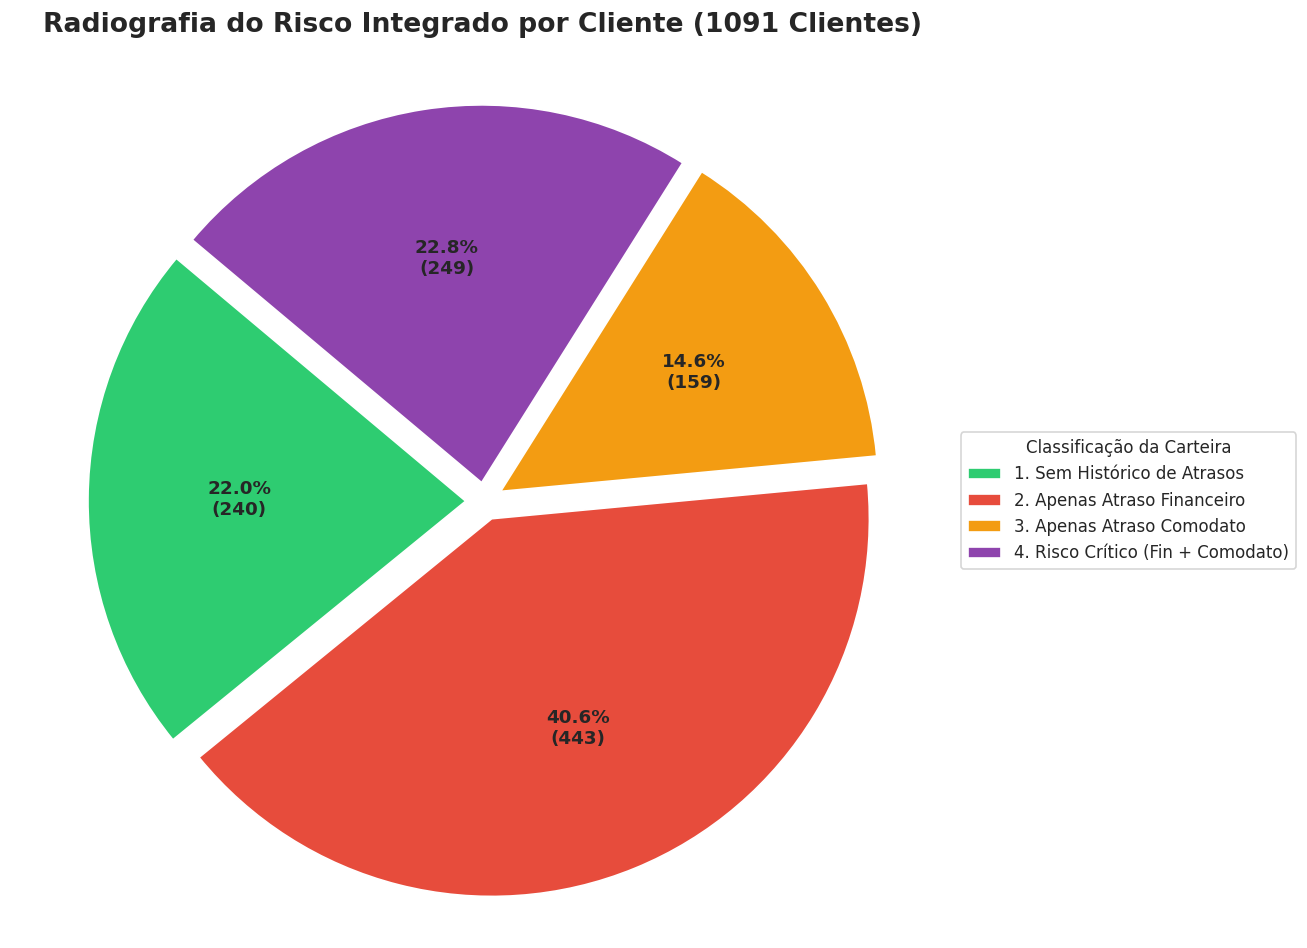

In [16]:
# ==============================================================================
# 3.6 BASE MESTRA DE CLIENTES (O UNIVERSO DE ANÁLISE)
# ==============================================================================
# Pegamos todos os clientes que já fizeram alguma compra
clientes_ativos = df_vendas['ID_PESSOA'].unique()
df_base_clientes = pd.DataFrame({'ID_PESSOA': clientes_ativos})

# Precisamos da "Ponte" para achar o ID_CLIENTE (que é usado no comodato)
df_ponte = tabelas_db['TB_CLIENTE'][['ID_CLIENTE', 'ID_PESSOA']].drop_duplicates()
df_base_clientes = df_base_clientes.merge(df_ponte, on='ID_PESSOA', how='left')

data_corte = pd.to_datetime(df_vendas['DT_PEDIDO']).max() if 'DT_PEDIDO' in df_vendas.columns else pd.Timestamp.now()

# ==============================================================================
# 2. STATUS DE RISCO FINANCEIRO (Agrupado por Cliente)
# ==============================================================================
df_fin = df_financeiro.copy()
df_fin['DT_VENCIMENTO'] = pd.to_datetime(df_fin['DT_VENCIMENTO'], errors='coerce')
col_pgto = 'DT_BAIXA' if 'DT_BAIXA' in df_fin.columns else 'DT_RECEBIMENTO'
df_fin[col_pgto] = pd.to_datetime(df_fin[col_pgto], errors='coerce')

# Se pagou atrasado ou ainda não pagou e já venceu = 1
df_fin['ATRASO_F'] = ((df_fin[col_pgto] > df_fin['DT_VENCIMENTO']) | 
                      (df_fin[col_pgto].isna() & (df_fin['DT_VENCIMENTO'] < data_corte))).astype(int)

# O "max" garante que: se o cliente tem 10 compras e atrasou UMA, ele é classificado com Risco
df_fin_cli = df_fin.groupby('ID_PESSOA').agg(STATUS_FIN=('ATRASO_F', 'max')).reset_index()

# ==============================================================================
# 3. STATUS DE RISCO COMODATO (Agrupado por Cliente)
# ==============================================================================
df_com = df_comodato.copy()
df_com['DT_VENCIMENTO'] = pd.to_datetime(df_com['DT_VENCIMENTO'], errors='coerce')
df_com['DT_RECOLHE'] = pd.to_datetime(df_com['DT_RECOLHE'], errors='coerce')

# Se devolveu atrasado ou está na rua e já venceu = 1
df_com['ATRASO_C'] = ((df_com['DT_RECOLHE'] > df_com['DT_VENCIMENTO']) | 
                      (df_com['DT_RECOLHE'].isna() & (df_com['DT_VENCIMENTO'] < data_corte))).astype(int)

df_com_cli = df_com.groupby('ID_CLIENTE').agg(STATUS_COM=('ATRASO_C', 'max')).reset_index()

# ==============================================================================
# 4. CRUZAMENTO FINAL E CATEGORIZAÇÃO
# ==============================================================================
df_consolidado = df_base_clientes.merge(df_fin_cli, on='ID_PESSOA', how='left') \
                                 .merge(df_com_cli, on='ID_CLIENTE', how='left').fillna(0)

condicoes = [
    (df_consolidado['STATUS_FIN'] == 0) & (df_consolidado['STATUS_COM'] == 0),
    (df_consolidado['STATUS_FIN'] == 1) & (df_consolidado['STATUS_COM'] == 1),
    (df_consolidado['STATUS_FIN'] == 1) & (df_consolidado['STATUS_COM'] == 0),
    (df_consolidado['STATUS_FIN'] == 0) & (df_consolidado['STATUS_COM'] == 1)
]

escolhas = [
    '1. Sem Histórico de Atrasos', 
    '4. Risco Crítico (Fin + Comodato)', 
    '2. Apenas Atraso Financeiro', 
    '3. Apenas Atraso Comodato'
]

df_consolidado['PERFIL_RISCO'] = np.select(condicoes, escolhas, default='Outros')

# ==============================================================================
# 5. VISUALIZAÇÃO - GRÁFICO PIZZA
# ==============================================================================
stats = df_consolidado['PERFIL_RISCO'].value_counts().sort_index()
total_clientes = len(df_consolidado)

plt.figure(figsize=(11, 8))

# Cores: 1=Verde (Bons), 2=Vermelho (Fin), 3=Laranja (Com), 4=Roxo (Críticos)
cores = ['#2ECC71', '#E74C3C', '#F39C12', '#8E44AD'] 

plt.pie(
    stats, 
    autopct=lambda p: f'{p:.1f}%\n({int(round(p * total_clientes / 100))})',
    startangle=140, 
    colors=cores,
    explode=[0.05] * len(stats),
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.legend(stats.index, title="Classificação da Carteira", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title(f'Radiografia do Risco Integrado por Cliente ({total_clientes} Clientes)', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()

os.makedirs("imagens", exist_ok=True)
plt.savefig(
    "imagens/Radiografia_Risco.png",
    dpi=300,            # alta resolução
    bbox_inches="tight" # corta bordas extras
)

plt.show()

### 💡 Conclusão: Radiografia da Carteira e Sobreposição de Riscos

A mudança de perspectiva do nível de "Pedido" para o nível de "Cliente" nos permitiu traçar o verdadeiro perfil de risco da nossa carteira ativa. O cruzamento das inadimplências revelou um cenário que exige forte atenção gerencial:

1. **A Minoria de Excelência (22%):** Apenas cerca de um quinto da nossa base atual é composta por clientes "livres de dor de cabeça" (sem nenhum histórico de atraso financeiro ou retenção de equipamentos). O fato de 78% dos clientes já terem gerado alguma fricção operacional mostra que atrasos são quase culturais nessa operação.

2. **A Dor Latente do Caixa (40%):** O atraso exclusivamente financeiro é o cenário mais recorrente. É o cliente que eventualmente escorrega no boleto ou na data do Pix, mas não gera passivo de maquinário. Exige uma esteira de cobrança ágil, mas ainda é um cliente que "gira" o produto.

3. **Inadimplência de Ativo (15%):** Uma fatia de clientes tem um comportamento curioso: pagam rigorosamente em dia, mas não devolvem a chopeira/cilindro no prazo. Para este grupo, o problema não é crédito, é logística reversa.

4. **🚨 A Zona de Perigo - Risco Crítico (22%):** Impressionantes 22% da base caem no pior cenário possível: **são ofensores duplos**. Eles comprometem o fluxo de caixa (não pagam) e bloqueiam o patrimônio da empresa (não devolvem o equipamento para ser alugado para outra pessoa). 
   * **Ação Estratégica:** Este é o grupo que corrói a margem de lucro da distribuidora. As políticas de concessão precisam ser severas com este perfil, exigindo, por exemplo, pagamento 100% antecipado e até cobrança de caução (garantia) para a liberação da chopeira.

**O Papel do Machine Learning:** O grande objetivo do nosso Modelo Preditivo daqui para frente será atuar como um "radar antecipado". Precisamos que o algoritmo consiga ler os dados de uma nova venda e prever, com base em padrões de histórico, idade, localização e forma de pagamento, se esse cliente tem probabilidade de cair na temida fatia dos **22% de Risco Crítico**, permitindo que a empresa bloqueie a venda antes que o prejuízo aconteça.

# 🔧 Fase 4 - Engenharia de Atributos e Preparação dos Datasets

Nesta etapa, transitamos da Análise Exploratória de Dados (EDA) para a construção da base que alimentará nossos modelos preditivos. O objetivo principal da **Engenharia de Atributos (Feature Engineering)** é transformar dados brutos e históricos de faturamento, entregas e interações em variáveis numéricas e categóricas de alto valor preditivo, capazes de capturar o comportamento de risco de inadimplência ou quebra de contrato no comodato de chopp.

### 🎯 Objetivos Estruturais
1. **Consolidação de Features:** Agregar os históricos transacionais (`VL_FINANCEIRO`, prazos de pagamento, médias de dias de atraso) na granularidade correta (por cliente/parceiro).
2. **Tratamento de Consistência:** Aplicar as regras de negócio para imputação de valores ausentes (`fillna`) e encoding de variáveis categóricas cruciais (como o `PERFIL` e a `CIDADE`).

### 📊 Estratégia de Divisão e Arquitetura dos DataFrames

Para garantir a reprodutibilidade e a aplicação prática do modelo em ambiente produtivo, segregamos nossa estrutura de dados em dois grandes blocos:

| Dataset | Finalidade no Projeto | Características |
| :--- | :--- | :--- |
| `df_ml_completo` | **Base de Produção / Inferência** | Contém a visão 360° de todos os clientes ativos com suas respectivas variáveis calculadas. É a base que receberá o *score* de risco diário ou mensal quando o modelo estiver rodando em produção. |
| `df_treino` / `df_teste` | **Desenvolvimento do Modelo** | Subconjunto extraído a partir do histórico elegível, contendo a variável resposta (`TARGET`) definida. Passará pela separação rigorosa (Holdout / Cross-Validation) para treinar, tunar e avaliar os algoritmos na Fase 5. |

---

## 👤 4.1 Consolidação da Visão Cadastral e Estruturação de Lookup por Cliente

O primeiro passo operacional da Engenharia de Atributos consiste em mudar a granularidade dos nossos dados. Enquanto as fases anteriores trabalharam a nível de transação/pedido, a modelagem preditiva exige uma linha única por cliente (`ID_CLIENTE`). 

Esta célula é responsável por construir a fundação dessa estrutura, consolidando as informações cadastrais e perfis históricos que servirão como base de cruzamento (*lookup*) para as próximas transformações.

---

#### 🛠️ **Processamento Executado na Célula**
1. **Definição da Entidade Central:** Isolamento do identificador único do cliente para garantir que não haja duplicidade de registros na base final.
2. **Mapeamento de Atributos Estuturais:** Resgate de variáveis qualitativas críticas a partir das dimensões tratadas, tais como:
   * **`PERFIL` / `TIPO_PESSOA`:** Essencial para capturar o comportamento de risco diferenciado entre pessoas físicas e jurídicas.
   * **`CIDADE`:** Variável de geolocalização relevante para análises de risco regionalizado na distribuição.
3. **Criação da Chave de Lookup:** Estruturação de um DataFrame base que vincula a identificação do cliente às suas características de cadastro estáveis, preparando o terreno para receber os agregados financeiros (`VL_FINANCEIRO`) e comportamentais nas células seguintes.



In [17]:
# ─── FASE 4: Construção de Features por Cliente ───────────────────────────────
print("🔄 Construindo features por cliente (unidade de análise: ID_PESSOA)")

hoje = pd.Timestamp.now()
data_corte = pd.to_datetime(df_vendas_chopp["DT_PEDIDO"]).max()
df_vendas_chopp["DT_PEDIDO"] = pd.to_datetime(df_vendas_chopp["DT_PEDIDO"], errors="coerce")

# ── 1. RFM e Volume de Compras ─────────────────────────────────────────────────
vendas_ml = (
    df_vendas_chopp.groupby("ID_PESSOA")
    .agg(
        PRIMEIRA_COMPRA=("DT_PEDIDO", "min"),
        ULTIMA_COMPRA=("DT_PEDIDO", "max"),
        FREQUENCIA_COMPRAS=("ID_PEDIDO", "nunique"),
        TOTAL_GASTO=("VL_FINANCEIRO", "sum"),
    )
    .reset_index()
)
vendas_ml["TICKET_MEDIO"] = vendas_ml["TOTAL_GASTO"] / vendas_ml["FREQUENCIA_COMPRAS"]
vendas_ml["DIAS_DESDE_PRIMEIRA_COMPRA"] = (hoje - vendas_ml["PRIMEIRA_COMPRA"]).dt.days
vendas_ml["DIAS_DESDE_ULTIMA_COMPRA"] = (hoje - vendas_ml["ULTIMA_COMPRA"]).dt.days

# ── 2. Métricas Financeiras ────────────────────────────────────────────────────
df_fin_feat = calc_atraso_financeiro(df_fin_chopp, data_corte)
if "ID_PESSOA" not in df_fin_feat.columns and "ID_CLIENTE" in df_fin_feat.columns:
    df_fin_feat = df_fin_feat.merge(
        tabelas_db["TB_CLIENTE"][["ID_CLIENTE", "ID_PESSOA"]],
        on="ID_CLIENTE",
        how="left",
    )

fin_ml = (
    df_fin_feat.groupby("ID_PESSOA")
    .agg(
        TOTAL_PARCELAS=("ID_PEDIDO", "count"),
        PARCELAS_ATRASADAS=("ATRASOU_PAGAMENTO", "sum"),
        MEDIA_DIAS_ATRASO_PAG=("DIAS_ATRASO_PAG", "mean"),
    )
    .reset_index()
)
fin_ml["TAXA_ATRASO_PAGAMENTO"] = fin_ml["PARCELAS_ATRASADAS"] / fin_ml["TOTAL_PARCELAS"].replace(0, 1)

# ── 3. Métricas de Comodato ────────────────────────────────────────────────────
df_com_feat = calc_atraso_comodato(df_comodato_chopp, data_corte)
if "ID_PESSOA" not in df_com_feat.columns and "ID_CLIENTE" in df_com_feat.columns:
    df_com_feat = df_com_feat.merge(
        tabelas_db["TB_CLIENTE"][["ID_CLIENTE", "ID_PESSOA"]],
        on="ID_CLIENTE",
        how="left",
    )

com_ml = (
    df_com_feat.groupby("ID_PESSOA")
    .agg(
        TOTAL_COMODATOS=("ID_COMODATO", "nunique"),
        COMODATOS_ATRASADOS=("ATRASOU_COMODATO", "sum"),
        MEDIA_DIAS_ATRASO_COM=("DIAS_ATRASO_COM", "mean"),
    )
    .reset_index()
)
com_ml["TAXA_ATRASO_COMODATO"] = com_ml["COMODATOS_ATRASADOS"] / com_ml["TOTAL_COMODATOS"].replace(0, 1)

# ── 4. Informações do cliente (nome/perfil para lookup) ───────────────────────
# Trazemos TB_PESSOA para ter o nome (DS_NOME ou similar) se disponível
df_info_cliente = tabelas_db["TB_CLIENTE"][["ID_CLIENTE", "ID_PESSOA"]].drop_duplicates("ID_PESSOA")
try:
    col_nome = [c for c in tabelas_db["TB_PESSOA"].columns if "NM_PESSOA" in c.upper()][0]
    df_info_cliente = df_info_cliente.merge(
        tabelas_db["TB_PESSOA"][["ID_PESSOA", col_nome]], on="ID_PESSOA", how="left"
    ).rename(columns={col_nome: "NOME_CLIENTE"})
except IndexError:
    df_info_cliente["NOME_CLIENTE"] = "N/D"

# ── 5. Merge Final ─────────────────────────────────────────────────────────────
COLS_NUM_FILL = [
    "TOTAL_PARCELAS",
    "PARCELAS_ATRASADAS",
    "MEDIA_DIAS_ATRASO_PAG",
    "TAXA_ATRASO_PAGAMENTO",
    "TOTAL_COMODATOS",
    "COMODATOS_ATRASADOS",
    "MEDIA_DIAS_ATRASO_COM",
    "TAXA_ATRASO_COMODATO",
]
COLS_CAT_FILL = ["PERFIL", "CIDADE", "PAGAMENTO"]

df_ml_completo = (
    vendas_ml.merge(fin_ml, on="ID_PESSOA", how="left")
    .merge(com_ml, on="ID_PESSOA", how="left")
    .merge(
        df_dimensoes[["ID_PESSOA", "PERFIL", "CIDADE", "PAGAMENTO"]].drop_duplicates(
            "ID_PESSOA"
        ),
        on="ID_PESSOA",
        how="left",
    )
    .merge(
        df_info_cliente[["ID_PESSOA", "NOME_CLIENTE"]].drop_duplicates("ID_PESSOA"),
        on="ID_PESSOA",
        how="left",
    )
)
df_ml_completo[COLS_NUM_FILL] = df_ml_completo[COLS_NUM_FILL].fillna(0)
df_ml_completo[COLS_CAT_FILL] = df_ml_completo[COLS_CAT_FILL].fillna("NÃO INFORMADO")
df_ml_completo["NOME_CLIENTE"] = df_ml_completo["NOME_CLIENTE"].fillna("N/D")

print(f"\n✅ df_ml_completo criado: {df_ml_completo.shape[0]:,} clientes × {df_ml_completo.shape[1]} colunas")
print(f"   └─ Inclui: ID_PESSOA, NOME_CLIENTE, todas as features + taxas de atraso")

display(df_ml_completo.head(10))

os.makedirs("data", exist_ok=True)
df_ml_completo.to_csv("data/df_ml_completo.csv", index=False)
print("Arquivo exportado com sucesso para 'data/df_ml_completo.csv'")

🔄 Construindo features por cliente (unidade de análise: ID_PESSOA)

✅ df_ml_completo criado: 1,091 clientes × 20 colunas
   └─ Inclui: ID_PESSOA, NOME_CLIENTE, todas as features + taxas de atraso


,ID_PESSOA,PRIMEIRA_COMPRA,ULTIMA_COMPRA,FREQUENCIA_COMPRAS,TOTAL_GASTO,TICKET_MEDIO,DIAS_DESDE_PRIMEIRA_COMPRA,DIAS_DESDE_ULTIMA_COMPRA,TOTAL_PARCELAS,PARCELAS_ATRASADAS,MEDIA_DIAS_ATRASO_PAG,TAXA_ATRASO_PAGAMENTO,TOTAL_COMODATOS,COMODATOS_ATRASADOS,MEDIA_DIAS_ATRASO_COM,TAXA_ATRASO_COMODATO,PERFIL,CIDADE,PAGAMENTO,NOME_CLIENTE
0,1,2024-04-24 09:50:26.383,2026-01-29 15:53:24.387,86,37024.00,430.511628,771,126,85.0,44.0,0.858824,0.517647,0.0,0.0,0.000000,0.000000,NÃO INFORMADO,NÃO INFORMADO,NÃO INFORMADO,N/D
1,2,2024-04-20 16:55:45.730,2026-01-23 13:48:52.577,30,14906.20,496.873333,775,132,22.0,13.0,2.954545,0.590909,0.0,0.0,0.000000,0.000000,NÃO INFORMADO,NÃO INFORMADO,NÃO INFORMADO,N/D
2,3,2024-05-09 14:00:44.877,2024-10-18 16:50:03.217,7,2424.00,346.285714,756,594,7.0,0.0,0.000000,0.000000,50.0,104.0,4.054795,2.080000,Jurídica,PONTA PORÃ,DINHEIRO,VERDE VIDA ALIMENTAÇÕES LTDA
3,4,2024-08-23 10:33:50.013,2024-08-23 10:33:50.013,1,280.00,280.000000,650,650,1.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NÃO INFORMADO,NÃO INFORMADO,NÃO INFORMADO,N/D
4,5,2024-04-16 13:53:06.447,2025-11-15 08:31:16.500,5,2910.00,582.000000,779,201,6.0,4.0,1.833333,0.666667,39.0,101.0,3.634921,2.589744,Física,PEDRO JUAN CABALLERO,DINHEIRO,LUIS EDUARDO NUNEZ DE OLIVEIRA
5,7,2024-04-16 17:19:56.690,2024-04-16 17:19:56.690,1,210.00,210.000000,779,779,1.0,0.0,0.000000,0.000000,2.0,0.0,0.000000,0.000000,Física,PONTA PORÃ,DINHEIRO,TAISA GUIMARAES TRINDADE
6,8,2024-05-08 15:23:50.730,2024-05-21 14:23:12.450,2,3525.00,1762.500000,757,744,3.0,2.0,0.666667,0.666667,0.0,0.0,0.000000,0.000000,Física,PONTA PORÃ,DINHEIRO,DAIANE BOEIRA FARINA
7,9,2024-04-17 14:20:05.410,2025-03-28 16:06:37.137,46,18778.00,408.217391,778,433,46.0,32.0,1.869565,0.695652,6.0,12.0,0.833333,2.000000,Estrangeiro,PEDRO JUAN CABALLERO,PIX,CASINO BET DIAMON YCUA POTY
8,10,2024-04-17 14:21:01.053,2025-10-31 13:14:01.370,43,11705.71,272.225814,778,216,43.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,Estrangeiro,PEDRO JUAN CABALLERO,PIX,CASINO CALIFORNIA
9,11,2024-04-17 14:21:32.640,2026-01-30 16:49:07.760,60,26680.00,444.666667,778,125,61.0,33.0,1.393443,0.540984,1.0,2.0,0.000000,2.000000,Jurídica,PONTA PORÃ,DINHEIRO,TOURO DE OURO (11)


Arquivo exportado com sucesso para 'data/df_ml_completo.csv'


## 🔀 4.2 Separação Explícita de Escopo: 
## Base de Produção vs. Base de Treino

Nesta célula, executamos a segregação física e lógica dos dados em duas frentes independentes. Essa separação explícita é um pilar essencial de governança, garantindo que o modelo seja treinado em um cenário controlado e que a empresa possua uma estrutura pronta para gerar escoragem (*scoring*) de risco em ambiente produtivo.

---

#### 📐 Direcionamento dos DataFrames

1. **`df_ml_completo` (Visão 360° / Tabela de Produção):**
   * **Escopo:** Consolida 100% dos clientes ativos.
   * **Finalidade:** Atuará como barramento de consulta rápida (*lookup*). No ecossistema real (Fase 7 - Deploy), essa tabela alimentará a função `predict_by_id()`, permitindo que o gestor consulte instantaneamente a saúde preditiva de qualquer cliente da base.

2. **`df_treino` (Foco em Aprendizado de Máquina):**
   * **Escopo:** Filtra apenas o histórico elegível de clientes veteranos, eliminando o ruído e o viés de novos cadastros sem histórico transacional (*cold-start*).
   * **Finalidade:** É a base exclusiva que será enviada para a partição de modelagem (Treino/Teste) na Fase 5.


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  SEPARAÇÃO EXPLÍCITA:  df_ml_completo  →  df_treino
#
#  df_ml_completo : tabela de usuários — todos os clientes, com ID_PESSOA
#                   serve para lookup em produção (predict_by_id)
#
#  df_treino      : dataset de modelagem — apenas veteranos, sem colunas de
#                   identidade, com a variável-alvo calculada (ALTO_RISCO)
# ══════════════════════════════════════════════════════════════════════════════

# ── Filtro de Veteranos ───────────────────────────────────────────────────────
df_treino = df_ml_completo[df_ml_completo["FREQUENCIA_COMPRAS"] > MIN_COMPRAS].copy()

# ── Variável-Alvo ──────────────────────────────────────────────────────────────
df_treino["ALTO_RISCO"] = np.where(
    (df_treino["TAXA_ATRASO_PAGAMENTO"] > LIMITE_ATRASO)
    | (df_treino["TAXA_ATRASO_COMODATO"] > LIMITE_ATRASO),
    1,
    0,
)

# ── Definição das Features ─────────────────────────────────────────────────────
FEATURES_NUM = [
    "FREQUENCIA_COMPRAS",
    "TICKET_MEDIO",
    "TOTAL_GASTO",
    "DIAS_DESDE_PRIMEIRA_COMPRA",
    "DIAS_DESDE_ULTIMA_COMPRA",
    "TOTAL_PARCELAS",
    "TOTAL_COMODATOS",
    "MEDIA_DIAS_ATRASO_PAG",
    "MEDIA_DIAS_ATRASO_COM",
]
FEATURES_CAT = ["PERFIL", "CIDADE", "PAGAMENTO"]
TARGET = "ALTO_RISCO"
ALL_FEATURES = FEATURES_NUM + FEATURES_CAT

# ── Relatório de Distribuição do Target ───────────────────────────────────────
n_total = len(df_treino)
n_risco = df_treino[TARGET].sum()
n_bom = n_total - n_risco
pct_risco = n_risco / n_total * 100

print("=" * 60)
print(f"{'📐 SEPARAÇÃO DE DATASETS':^60}")
print("=" * 60)
print(f"\n  df_ml_completo             : {len(df_ml_completo):>5,} clientes  (lookup de produção)")
print(f"  df_treino                  : {n_total:>5,} clientes  (veteranos: compras > {MIN_COMPRAS})")
print(f"  Descartados                : {len(df_ml_completo)-n_total:>5,} clientes  (insuficiência de histórico)")
print(f"  % Clientes Utilizados      : {n_total/len(df_ml_completo)*100:.1f}%")

print(f"\n{'─'*60}")
print(f"{'📊 VARIÁVEL-ALVO: ALTO_RISCO':^60}")
print(f"{'─'*60}")
print(f"  Alto Risco (1) : {n_risco:>5,}  ({pct_risco:.1f}%)")
print(f"  Bom Pagador (0): {n_bom:>5,}  ({100-pct_risco:.1f}%)")

if pct_risco > 35:
    print(f"\n  ⚠️  Desbalanceamento detectado → class_weight='balanced' nos modelos")

# ── Divisão Treino / Teste ─────────────────────────────────────────────────────
X = df_treino[ALL_FEATURES].copy()
y = df_treino[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"\n{'─'*60}")
print(f"{'✂️  DIVISÃO TREINO / TESTE':^60}")
print(f"{'─'*60}")
print(f"  X_train : {X_train.shape[0]:,} clientes  ({int((1-TEST_SIZE)*100)}%)")
print(f"  X_test  : {X_test.shape[0]:,} clientes  ({int(TEST_SIZE*100)}%)")
print(f"\n  Features numéricas  : {len(FEATURES_NUM)}")
print(f"  Features categóricas: {len(FEATURES_CAT)}")
print(f"  Total de features   : {len(ALL_FEATURES)}")

# --TODO-- -- COLOCAR QUAIS SAO AS 12 FEATURES -- 

                  📐 SEPARAÇÃO DE DATASETS                   

  df_ml_completo             : 1,091 clientes  (lookup de produção)
  df_treino                  :   264 clientes  (veteranos: compras > 2)
  Descartados                :   827 clientes  (insuficiência de histórico)
  % Clientes Utilizados      : 24.2%

────────────────────────────────────────────────────────────
                📊 VARIÁVEL-ALVO: ALTO_RISCO                 
────────────────────────────────────────────────────────────
  Alto Risco (1) :   247  (93.6%)
  Bom Pagador (0):    17  (6.4%)

  ⚠️  Desbalanceamento detectado → class_weight='balanced' nos modelos

────────────────────────────────────────────────────────────
                 ✂️  DIVISÃO TREINO / TESTE                 
────────────────────────────────────────────────────────────
  X_train : 184 clientes  (70%)
  X_test  : 80 clientes  (30%)

  Features numéricas  : 9
  Features categóricas: 3
  Total de features   : 12


# 🤖 Fase 5 - Modelagem com Pipelines Modulares

Nesta fase, entramos no núcleo de Inteligência Artificial do projeto. Utilizando a base de dados refinada na Engenharia de Atributos, passamos a construir, treinar e validar os algoritmos de Machine Learning. O objetivo principal é desenvolver um classificador capaz de prever a probabilidade de um cliente se tornar um detrator de risco (inadimplência ou retenção de ativos), permitindo ações preventivas antes da consolidação do prejuízo.

### ⚙️ Estratégia de Modelagem
Para garantir um processo robusto, escalável e livre de vieses, nossa abordagem se baseia em três pilares técnicos:
1. **Pipelines Modulares:** Automação das etapas de pré-processamento, garantindo que transformações nos dados de treino nunca vazem para os dados de teste.
2. **Validação Cruzada (CV):** Divisão em múltiplos blocos (folds) para garantir que a performance do modelo seja estável e não fruto do acaso.
3. **Métricas de Negócio Orientadas a Risco:** Foco analítico na otimização do **Recall (Sensibilidade)** da classe de risco e na curva **AUC-ROC**, garantindo que o modelo capture o máximo de clientes nocivos com o menor índice de alarmes falsos.

---

> 🗃️ **Governança de Modelos:** Todas as iterações, hiperparâmetros e métricas de performance serão centralizados em um repositório estruturado em memória (`MODEL_REGISTRY`), permitindo uma comparação justa e auditável para a escolha do modelo campeão que irá para produção.

---

## 🧱 5.1 Arquitetura de Pipelines Modulares e Inicialização do Repositório (`MODEL_REGISTRY`)

Esta célula estabelece a infraestrutura de engenharia de software para os nossos modelos. Em vez de aplicar transformações nos dados de forma manual e isolada, encapsulamos o fluxo em **Pipelines do Scikit-Learn**. 

Isso garante que qualquer tratamento aplicado no treino (como imputação de nulos ou escala de variáveis) seja replicado de forma idêntica e segura na base de produção (`df_ml_completo`), eliminando erros de consistência.

#### 🛠️ **Componentes Estruturados nesta Célula**
1. **Pipeline de Pré-processamento:** Separação automática e tratamento customizado para variáveis numéricas (escalonamento e inputação) e variáveis categóricas (codificação).
2. **Criação do `MODEL_REGISTRY`:** Inicialização do dicionário centralizado de controle. Esse componente funcionará como o "painel de controle" do cientista de dados, armazenando:
   * Hiperparâmetros testados de cada algoritmo.
   * Métricas de validação interna (CV).
   * Curvas de performance do conjunto de testes.
3. **Isolamento do `TARGET`:** Separação explícita da variável resposta para garantir a integridade dos algoritmos.

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
#  PIPELINES MODULARES — build_pipeline() é reutilizável para qualquer clf
# ══════════════════════════════════════════════════════════════════════════════

# ── Pré-processador Compartilhado ─────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), FEATURES_NUM),
                  ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), FEATURES_CAT),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

# ── Cache de Pipeline ───────────────
cache_dir = Memory(location="cache_pipeline", verbose=0)

def build_pipeline(clf, preprocessor=preprocessor, cache=cache_dir) -> Pipeline:
    """
    Constrói um Pipeline sklearn com preprocessor + classificador.
    
    Parâmetros
    ----------
    clf         : estimador sklearn (LogisticRegression, RandomForest, etc.)
    preprocessor: ColumnTransformer pré-configurado (reutilizado de FASE 4)
    cache       : joblib.Memory para cache de transformações
    
    Retorna: Pipeline com steps ['prep', 'clf']
    """
    return Pipeline(steps=[('prep', preprocessor), ('clf', clf)], memory=cache)

# ── Definição dos Classificadores ────────────────────────────────────────────
clfs = {
    "Regressão Logística": LogisticRegression(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver="lbfgs",
        penalty="l2",
        C=1.0,
    ),
    "Árvore de Decisão": DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=6,
        min_samples_split=2,
        min_samples_leaf=1,
        criterion="gini",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        max_depth=8,
        min_samples_leaf=3,
        min_samples_split=2,
        max_features="sqrt",
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

# ── MODEL_REGISTRY: dicionário central de versões ────────────────────────────
MODEL_REGISTRY = {}
for nome, clf in clfs.items():
    MODEL_REGISTRY[nome] = {
        "pipeline": build_pipeline(clf),
        "params": clf.get_params(),
        "versao": MODEL_VERSION,
        "data_criacao": datetime.now().isoformat(),
        "metricas_cv": {},
        "metricas_teste": {},
        "treinado": False,
    }

print("✅ MODEL_REGISTRY criado com sucesso!")
print(f"{'─'*50}")
for nome, entry in MODEL_REGISTRY.items():
    tipo_clf = type(entry["pipeline"].named_steps["clf"]).__name__
    print(f"   📦 {nome:<25} → {tipo_clf}")
print(f"{'─'*50}")
print(f"\n💡 Uso: MODEL_REGISTRY['Random Forest']['pipeline'].fit(X_train, y_train)")
print(f"         build_pipeline(NovoModelo()) → adicione ao registry!")

print("\n🔍 Visualização do Pipeline (Exemplo: Random Forest):")
display(MODEL_REGISTRY["Random Forest"]["pipeline"])

✅ MODEL_REGISTRY criado com sucesso!
──────────────────────────────────────────────────
   📦 Regressão Logística       → LogisticRegression
   📦 Árvore de Decisão         → DecisionTreeClassifier
   📦 Random Forest             → RandomForestClassifier
──────────────────────────────────────────────────

💡 Uso: MODEL_REGISTRY['Random Forest']['pipeline'].fit(X_train, y_train)
         build_pipeline(NovoModelo()) → adicione ao registry!

🔍 Visualização do Pipeline (Exemplo: Random Forest):


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati...peline\joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

---

## ⚙️ 5.2 Motor de Treinamento: Função Reutilizável e Avaliação via Validação Cruzada (CV)

Esta célula contém o "motor" de execução do nosso experimento de Machine Learning. Para evitar a repetição massiva de blocos de código para cada algoritmo testado, implementamos uma **função mestre reutilizável** de treino e avaliação.

A função automatiza o ciclo completo de vida de um modelo de classificação, aplicando testes estatísticos rigorosos e salvando os resultados diretamente no nosso dicionário de governança.

#### 🔄 Ciclo de Execução Automatizado
1. **Validação Cruzada Estratificada (Stratified CV):** O modelo é testado em diferentes partições dos dados, preservando a proporção original da classe de risco para mitigar o efeito do desbalanceamento.
2. **Ajuste de Hiperparâmetros:** Busca ativa pelas melhores configurações matemáticas de cada algoritmo.
3. **Extração do Relatório de Classificação Completo:** Cálculo instantâneo das métricas de validação e teste: `Acurácia`, `Precisão`, `Recall`, `F1-Score` e `AUC-ROC`.
4. **Alimentação do Painel:** Registro automático da performance do modelo no `MODEL_REGISTRY`, preparando o terreno para a seleção visual do modelo com melhor fit para o negócio.

In [20]:
# ─── Função Reutilizável: Treinar e Avaliar ────────────────────────────────────
def train_and_evaluate(
    nome: str,
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    cv_folds: int = CV_FOLDS,
) -> dict:
    """
    Treina o pipeline, executa CV e avalia no teste.
    Atualiza MODEL_REGISTRY[nome] com todas as métricas.

    Retorna dict com métricas do conjunto de teste.
    """
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    # Validação Cruzada
    cv_result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["roc_auc", "f1", "recall", "precision"],
        return_train_score=False,
        n_jobs=-1,
    )
    metricas_cv = {
        "AUC": float(cv_result["test_roc_auc"].mean()),
        "AUC_std": float(cv_result["test_roc_auc"].std()),
        "F1": float(cv_result["test_f1"].mean()),
        "Recall": float(cv_result["test_recall"].mean()),
        "Precisão": float(cv_result["test_precision"].mean()),
    }

    # Treinamento Final
    pipeline.fit(X_train, y_train)

    # Avaliação no Teste
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    report = cast(Dict[str, Any], classification_report(y_test, y_pred, output_dict=True))
    classe1 = report.get("1", {"precision": 0, "recall": 0, "f1-score": 0})

    metricas_teste = {
        "AUC": float(roc_auc_score(y_test, y_proba)),
        "F1": float(classe1["f1-score"]),
        "Recall": float(classe1["recall"]),
        "Precisão": float(classe1["precision"]),
        "Accuracy": float(report["accuracy"]),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

    # Atualiza registry
    MODEL_REGISTRY[nome]["metricas_cv"] = metricas_cv
    MODEL_REGISTRY[nome]["metricas_teste"] = metricas_teste
    MODEL_REGISTRY[nome]["treinado"] = True

    return metricas_teste


# ─── Executa para todos os modelos ────────────────────────────────────────────
print(f"🔁 Validação Cruzada Estratificada ({CV_FOLDS}-Fold) + Treinamento Final\n")
print(f"{'─'*70}")

for nome, entry in MODEL_REGISTRY.items():
    met = train_and_evaluate(nome, entry["pipeline"], X_train, y_train, X_test, y_test)
    cv = MODEL_REGISTRY[nome]["metricas_cv"]
    print(
        f"  ✅ {nome:<25} | CV AUC={cv['AUC']:.3f}±{cv['AUC_std']:.3f} "
        f"| Teste AUC={met['AUC']:.3f} | F1={met['F1']:.3f} | Recall={met['Recall']:.3f}"
    )

print(f"{'─'*70}")
print(f"\n✅ Todos os modelos treinados e avaliados!")

best_model = max(MODEL_REGISTRY.items(), key=lambda x: x[1]["metricas_teste"]["AUC"])

print(f"🏆 Melhor modelo: {best_model[0]}")
display(best_model[1]["pipeline"])

🔁 Validação Cruzada Estratificada (5-Fold) + Treinamento Final

──────────────────────────────────────────────────────────────────────
  ✅ Regressão Logística       | CV AUC=0.892±0.052 | Teste AUC=0.923 | F1=0.872 | Recall=0.773
  ✅ Árvore de Decisão         | CV AUC=0.658±0.182 | Teste AUC=0.968 | F1=0.973 | Recall=0.947
  ✅ Random Forest             | CV AUC=0.906±0.069 | Teste AUC=0.992 | F1=0.980 | Recall=0.987
──────────────────────────────────────────────────────────────────────

✅ Todos os modelos treinados e avaliados!
🏆 Melhor modelo: Random Forest


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati...peline\joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

# 📊 Fase 6 - Avalição dos Modelos

Nesta fase é realizada a avaliação final e o confronto direto entre os algoritmos treinados na etapa anterior. O objetivo principal da **Avaliação de Modelos** é validar a capacidade de generalização dos classificadores usando o conjunto de dados de teste (dados inéditos), garantindo que o modelo escolhido seja robusto e confiável para rodar em ambiente produtivo.

### 🎯 **Relembrando Nossos Critérios de Sucesso (Métricas de Negócio)**
Para alinhar a Inteligência Artificial aos objetivos estratégicos do negócio, relembramos os KPIs de avaliação estabelecidos na Fase 1:

* 🎯 **Recall (Sensibilidade) da Classe 1:** Nossa métrica prioritária. Precisamos garantir que o modelo identifique a maior porcentagem possível de clientes de risco (**Super Detratores**), minimizando os *Falsos Negativos* (clientes nocivos que o modelo prevê como bons).
* ⚖️ **F1-Score / Precisão:** Utilizados como balizadores para evitar um excesso de *Falsos Alarmes* (bloquear bons clientes por engano), o que prejudicaria a receita da operação.
* 📈 **Curva AUC-ROC:** Avalia a capacidade macro do modelo em distinguir as duas classes ao longo de diferentes pontos de corte (*thresholds*).

---


## 📉 6.1 Painel Comparativo de Performance: Matrizes de Confusão e Curva ROC

Esta célula é responsável por gerar o diagnóstico visual e estatístico completo de cada um dos três modelos testados. Através do cruzamento das métricas no conjunto de teste, construímos a base analítica necessária para a tomada de decisão do modelo campeão.

---

#### 🛠️ **Componentes de Diagnóstico Gerados:**
1. **Matriz de Confusão Combinada:** Exibe o volume exato de acertos e erros de cada algoritmo, permitindo auditar o impacto financeiro de cada modelo (contagem de falsos negativos vs. falsos alarmes).
2. **Gráfico da Curva ROC e AUC:** Plota o comportamento dos modelos em uma única tela. O algoritmo cuja linha estiver mais próxima do canto superior esquerdo (maior valor de AUC) possui o melhor poder de separação.
3. **Tabela Consolidada de Métricas:** Um compilado final trazendo **Acurácia, Precisão, Recall e F1-Score**, permitindo uma comparação analítica e objetiva para defender a escolha do modelo perante a banca examinadora.


🏆 MELHOR MODELO: Random Forest
AUC = 0.9920


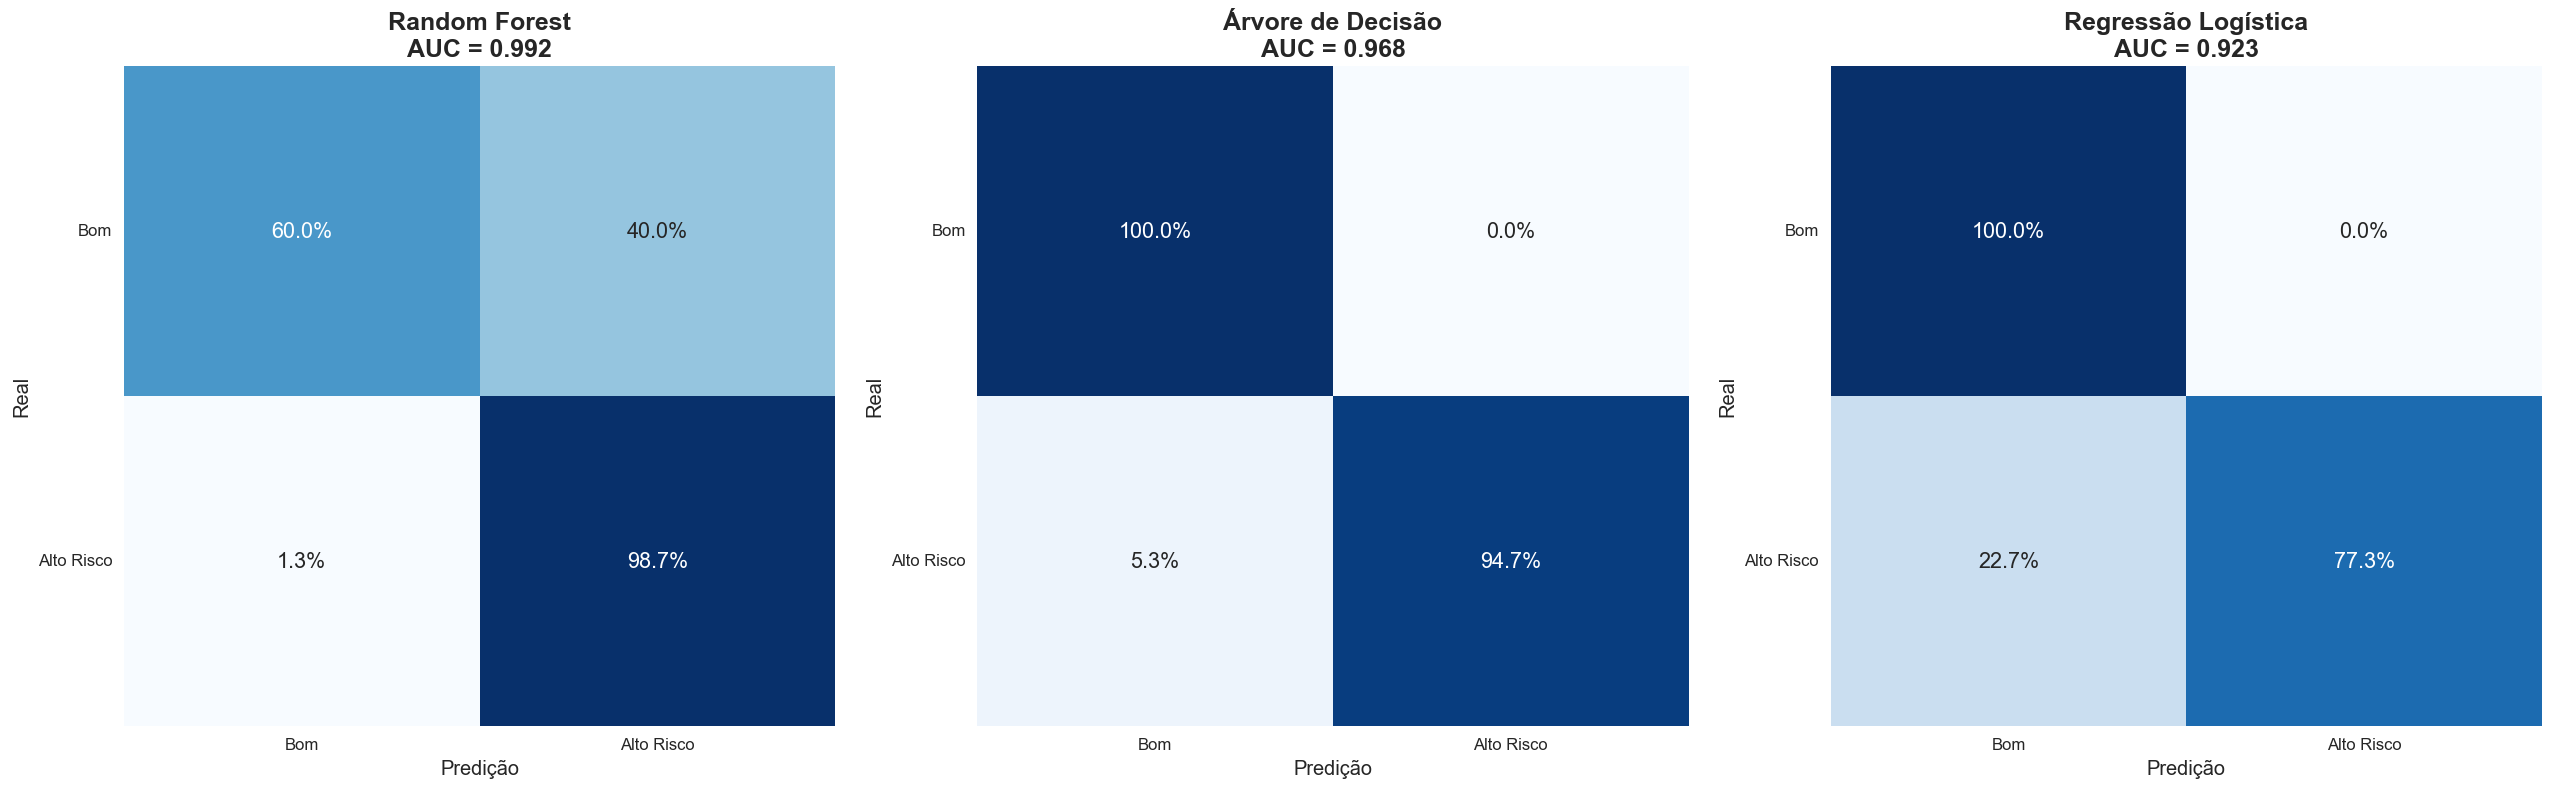

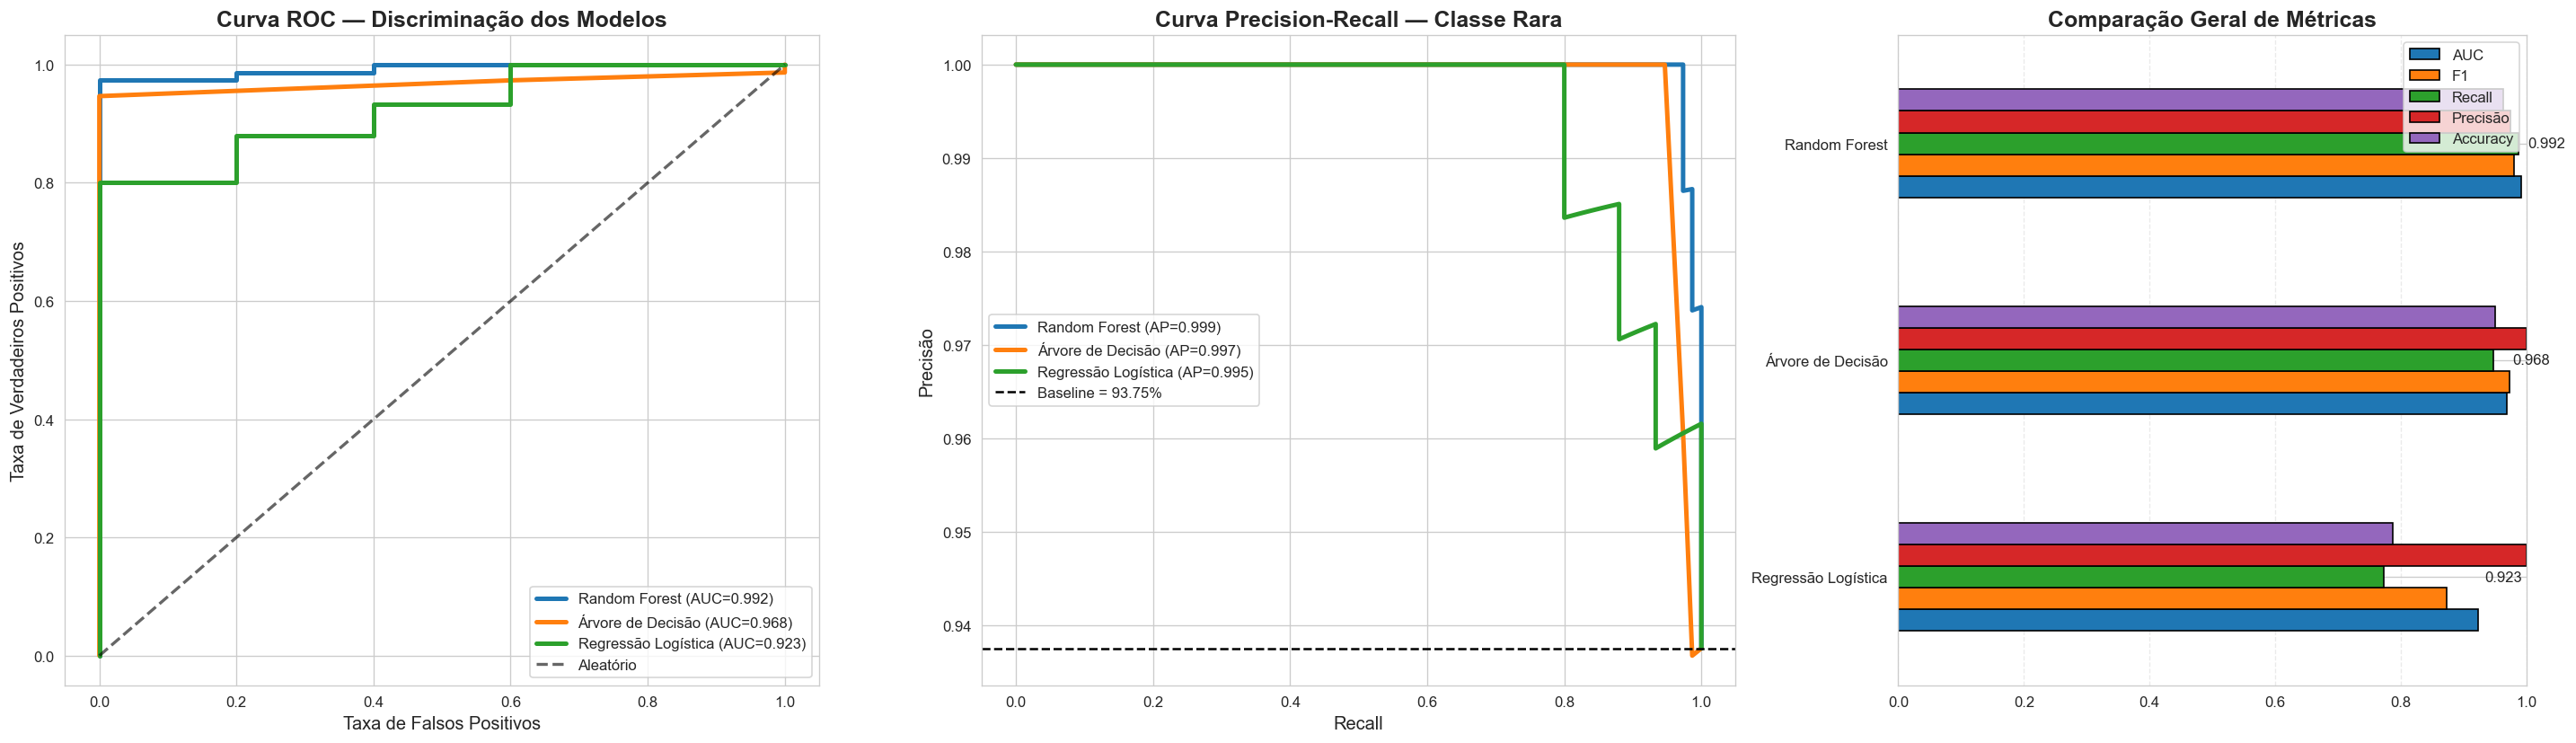

In [21]:
# =============================================================================
# FASE 6 — AVALIAÇÃO FINAL DOS MODELOS
# =============================================================================

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
)
sns.set_style("whitegrid")

# ─────────────────────────────────────────────────────────────────────────────
# Seleciona modelos avaliados e ORDENA PELO MELHOR AUC
# ─────────────────────────────────────────────────────────────────────────────
modelos_avaliados = {
    nome: entry
    for nome, entry in MODEL_REGISTRY.items()
    if entry.get("metricas_teste") and "AUC" in entry["metricas_teste"]
}

modelos_ordenados = dict(
    sorted(
        modelos_avaliados.items(),
        key=lambda x: x[1]["metricas_teste"]["AUC"],
        reverse=True,
    )
)

nomes_modelos = list(modelos_ordenados.keys())
n_modelos = len(nomes_modelos)

palette = sns.color_palette("tab10", n_modelos)
baseline = y_test.mean()

fig = plt.figure(figsize=(26, 15))
gs = fig.add_gridspec(2, n_modelos, height_ratios=[1.1, 1])

# =============================================================================
# 1️⃣ MATRIZES DE CONFUSÃO NORMALIZADAS
# =============================================================================
for idx, nome in enumerate(nomes_modelos):
    ax = fig.add_subplot(gs[0, idx])

    m = modelos_ordenados[nome]["metricas_teste"]
    cm = confusion_matrix(y_test, m["y_pred"], normalize="true")

    sns.heatmap(
        cm,
        annot=True,
        fmt=".1%",
        cmap="Blues",
        cbar=False,
        ax=ax,
        annot_kws={"size": 13},
    )

    ax.set_title(f"{nome}\nAUC = {m['AUC']:.3f}", fontweight="bold")
    ax.set_xlabel("Predição")
    ax.set_ylabel("Real")
    ax.set_xticklabels(["Bom", "Alto Risco"])
    ax.set_yticklabels(["Bom", "Alto Risco"], rotation=0)

# =============================================================================
# 2️⃣ CURVAS ROC + PR + BARRAS (FIGURA SEPARADA)
# =============================================================================
fig2, (ax_roc, ax_pr, ax_bar) = plt.subplots(
    1, 3, figsize=(24, 7), gridspec_kw={"width_ratios": [1.2, 1.2, 1]}
)

# ── ROC ───────────────────────────────────────────────────────────────────────
for idx, nome in enumerate(nomes_modelos):
    m = modelos_ordenados[nome]["metricas_teste"]
    fpr, tpr, _ = roc_curve(y_test, m["y_proba"])
    ax_roc.plot(fpr, tpr, lw=3, color=palette[idx], label=f"{nome} (AUC={m['AUC']:.3f})")

ax_roc.plot([0, 1], [0, 1], "k--", lw=2, alpha=0.6, label="Aleatório")
ax_roc.set_title("Curva ROC — Discriminação dos Modelos", fontweight="bold")
ax_roc.set_xlabel("Taxa de Falsos Positivos")
ax_roc.set_ylabel("Taxa de Verdadeiros Positivos")
ax_roc.legend()

# ── PR ────────────────────────────────────────────────────────────────────────
for idx, nome in enumerate(nomes_modelos):
    m = modelos_ordenados[nome]["metricas_teste"]
    p, r, _ = precision_recall_curve(y_test, m["y_proba"])
    ap = average_precision_score(y_test, m["y_proba"])
    
    ax_pr.plot(r, p, lw=3, color=palette[idx], label=f"{nome} (AP={ap:.3f})")

ax_pr.axhline(baseline, ls="--", color="black", label=f"Baseline = {baseline:.2%}")
ax_pr.set_title("Curva Precision-Recall — Classe Rara", fontweight="bold")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precisão")
ax_pr.legend()

# ── BARRAS HORIZONTAIS (MUITO MAIS EXECUTIVO) ────────────────────────────────
df_res = pd.DataFrame(
    {nome: entry["metricas_teste"] for nome, entry in modelos_ordenados.items()}
).T[["AUC", "F1", "Recall", "Precisão", "Accuracy"]]

df_res = df_res.sort_values("AUC")

df_res.plot.barh(ax=ax_bar, edgecolor="black")
ax_bar.set_title("Comparação Geral de Métricas", fontweight="bold")
ax_bar.set_xlim(0, 1)
ax_bar.grid(axis="x", linestyle="--", alpha=0.4)

for i, v in enumerate(df_res["AUC"]):
    ax_bar.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()

# =============================================================================
# 🏆 MELHOR MODELO
# =============================================================================
melhor_nome = max(
    modelos_ordenados, key=lambda k: modelos_ordenados[k]["metricas_teste"]["AUC"]
)

print("\n" + "=" * 70)
print(f"🏆 MELHOR MODELO: {melhor_nome}")
print(f"AUC = {modelos_ordenados[melhor_nome]['metricas_teste']['AUC']:.4f}")
print("=" * 70)

plt.show()

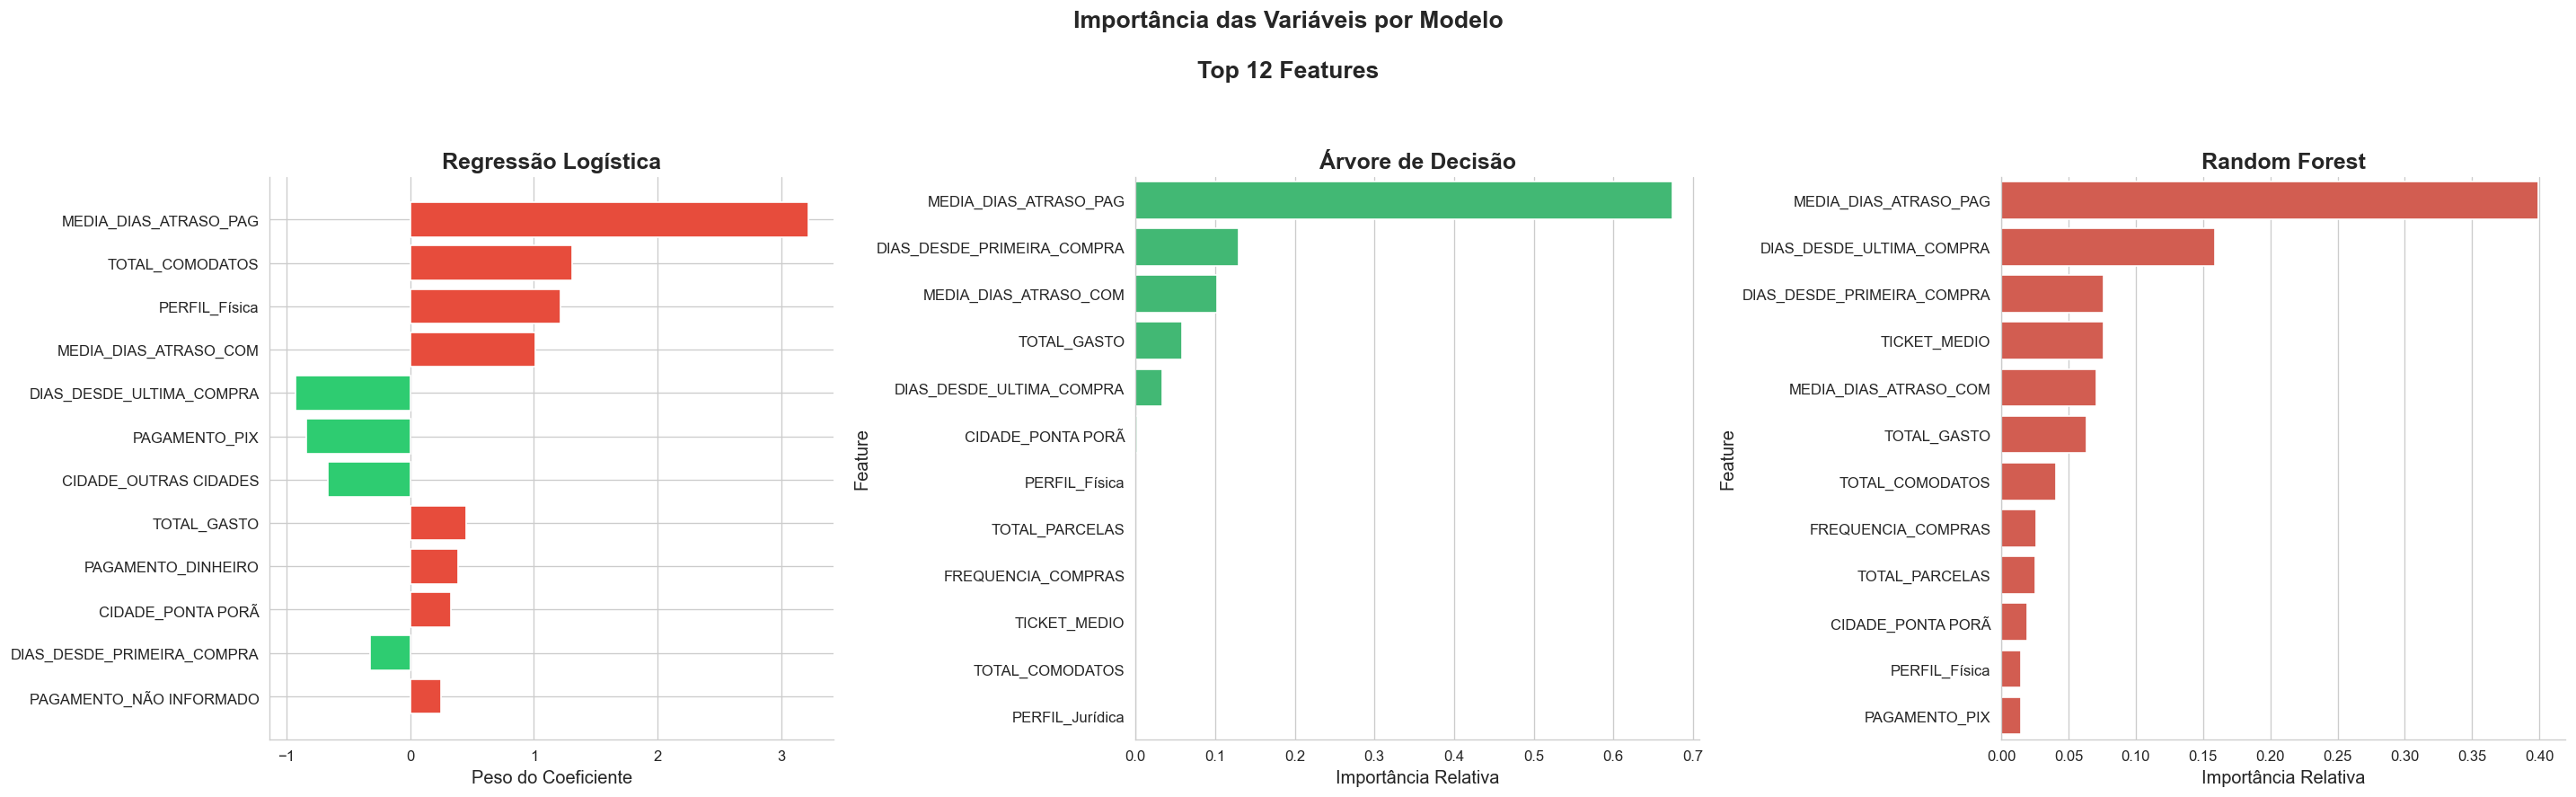

In [22]:
# ─── 6B: Importância das Variáveis por Modelo ─────────────────────────────────


def get_feature_names(pipeline: Pipeline) -> list:
    """Extrai nomes das features após OneHotEncoding do preprocessor."""
    prep = pipeline.named_steps["prep"]
    cat_enc = prep.named_transformers_["cat"]
    cat_names = list(cat_enc.get_feature_names_out(FEATURES_CAT))
    return FEATURES_NUM + cat_names


modelos_com_importance = {
    nome: entry for nome, entry in modelos_avaliados.items() if entry.get("treinado")
}

fig, axes = plt.subplots(
    1, len(modelos_com_importance), figsize=(8 * len(modelos_com_importance), 7)
)
if len(modelos_com_importance) == 1:
    axes = [axes]

for ax, (nome, entry) in zip(axes, modelos_com_importance.items()):
    pipeline = entry["pipeline"]
    clf = pipeline.named_steps["clf"]
    all_names = get_feature_names(pipeline)
    cor = CORES_MODELO.get(nome, "#7F8C8D")

    if hasattr(clf, "feature_importances_"):
        df_imp = pd.DataFrame(
            {"Feature": all_names, "Importância": clf.feature_importances_}
        )
        df_imp = df_imp.sort_values("Importância", ascending=False).head(12)
        sns.barplot(
            data=df_imp,
            x="Importância",
            y="Feature",
            ax=ax,
            color=cor,
            edgecolor="white",
        )
        ax.set_title(f"{nome}", fontweight="bold")
        ax.set_xlabel("Importância Relativa")

    elif hasattr(clf, "coef_"):
        df_coef = pd.DataFrame({"Feature": all_names, "Coeficiente": clf.coef_[0]})
        df_coef = df_coef.reindex(df_coef["Coeficiente"].abs().sort_values(ascending=False).index).head(12)
        cores_coef = ["#E74C3C" if v > 0 else "#2ECC71" for v in df_coef["Coeficiente"]]
        ax.barh(
            df_coef["Feature"][::-1],
            df_coef["Coeficiente"][::-1],
            color=cores_coef[::-1],
            edgecolor="white",
        )
        ax.set_title(f"{nome}", fontweight="bold")
        ax.set_xlabel("Peso do Coeficiente")

plt.suptitle("Importância das Variáveis por Modelo\n\nTop 12 Features", fontsize=16, fontweight="bold", y=1.05)
sns.despine()
plt.tight_layout()
plt.show()

# 🚀 Fase 7 - Deploy

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  FASE 7 — DEPLOY: Versionamento + Predict por ID do Cliente
# ══════════════════════════════════════════════════════════════════════════════


def save_model_version(
    nome: str,
    pipeline: Pipeline,
    metricas: dict,
    versao: str = MODEL_VERSION,
    model_dir: str = MODEL_DIR,
) -> str:
    """
    Salva pipeline + metadados em PKL versionado.
    Convenção de nome: modelo_chopp_v{versao}_{algoritmo}_{data}.pkl
    Retorna: caminho do arquivo salvo.
    """
    slug = nome.lower().replace(" ", "_").replace("(", "").replace(")", "")
    data_hoje = datetime.now().strftime("%Y%m%d")
    filename = f"modelo_chopp_v{versao}_{slug}_{data_hoje}.pkl"
    filepath = os.path.join(model_dir, filename)

    export = {
        "pipeline": pipeline,
        "nome_modelo": nome,
        "versao": versao,
        "features_num": FEATURES_NUM,
        "features_cat": FEATURES_CAT,
        "all_features": ALL_FEATURES,
        "target": TARGET,
        "limite_atraso": LIMITE_ATRASO,
        "min_compras": MIN_COMPRAS,
        "metricas_teste": {
            k: v
            for k, v in metricas.items()
            if not hasattr(v, "__len__") or isinstance(v, float)
        },
        "data_treinamento": datetime.now().isoformat(),
        "random_state": RANDOM_STATE,
    }

    with open(filepath, "wb") as f:
        pickle.dump(export, f)

    tamanho_kb = os.path.getsize(filepath) / 1024
    print(f"   💾 Salvo: {filename}  ({tamanho_kb:.1f} KB)")
    return filepath


def load_model_version(filepath: str) -> dict:
    """
    Carrega modelo PKL e exibe card do modelo.
    Retorna o dicionário completo do modelo exportado.
    """
    with open(filepath, "rb") as f:
        obj = pickle.load(f)

    print(f"\n{'═'*55}")
    print(f"{'📦 CARD DO MODELO':^55}")
    print(f"{'═'*55}")
    print(f"  Nome       : {obj['nome_modelo']}")
    print(f"  Versão     : {obj['versao']}")
    print(f"  Treinado em: {datetime.fromisoformat(obj['data_treinamento']).strftime('%d/%m/%Y')}")

    m = obj.get("metricas_teste", {})
    
    if m:
        print(f"  AUC-ROC    : {m.get('AUC', 'N/D'):.4f}" if isinstance(m.get("AUC"), float) else "  AUC-ROC    : N/D")
        print(f"  F1-Score   : {m.get('F1', 'N/D'):.4f}" if isinstance(m.get("F1"), float) else "")
        print(f"  Recall     : {m.get('Recall', 'N/D'):.4f}" if isinstance(m.get("Recall"), float) else "")
    print(f"  Features   : {len(obj['all_features'])} ({len(obj['features_num'])} num + {len(obj['features_cat'])} cat)")
    print(f"{'═'*55}")
    return obj


# ─── Exportando todos os modelos treinados ────────────────────────────────────
print("🚀 Exportando modelos para PKL...\n")
caminhos_salvos = {}

for nome, entry in MODEL_REGISTRY.items():
    if entry["treinado"] and entry["metricas_teste"]:
        caminho = save_model_version(nome, entry["pipeline"], entry["metricas_teste"])
        caminhos_salvos[nome] = caminho
        MODEL_REGISTRY[nome]["filepath"] = caminho

# ─── Melhor modelo para produção ─────────────────────────────────────────────
melhor_nome = max(
    {k: v for k, v in MODEL_REGISTRY.items() if v["treinado"] and v["metricas_teste"]},
    key=lambda k: MODEL_REGISTRY[k]["metricas_teste"].get("AUC", 0),
)
MODELO_PRODUCAO_PATH = MODEL_REGISTRY[melhor_nome]["filepath"]

print(f"\n✅ Modelos exportados: {len(caminhos_salvos)}")
print(f"🏆 Modelo de produção : {melhor_nome}")
print(f"   Arquivo            : {MODELO_PRODUCAO_PATH}")

🚀 Exportando modelos para PKL...

   💾 Salvo: modelo_chopp_v1.0.0_regressão_logística_20260604.pkl  (3.7 KB)
   💾 Salvo: modelo_chopp_v1.0.0_árvore_de_decisão_20260604.pkl  (6.6 KB)
   💾 Salvo: modelo_chopp_v1.0.0_random_forest_20260604.pkl  (374.5 KB)

✅ Modelos exportados: 3
🏆 Modelo de produção : Random Forest
   Arquivo            : modelos\modelo_chopp_v1.0.0_random_forest_20260604.pkl


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
#  predict_by_id — Função de Produção
#  Simula: SELECT features FROM df_ml_completo WHERE ID_PESSOA = :id
# ══════════════════════════════════════════════════════════════════════════════

def predict_by_id(
    id_pessoa,
    df_usuario: pd.DataFrame,
    modelo_obj: dict,
    threshold: float = 0.5,
) -> dict:
    """
    Classifica um cliente pelo seu ID, buscando as features em df_usuario.
    
    Parâmetros
    ----------
    id_pessoa  : valor do ID_PESSOA a ser consultado
    df_usuario : df_ml_completo — tabela de usuários (NÃO o df_treino)
    modelo_obj : dicionário retornado por load_model_version() ou direto do registry
    threshold  : limiar de probabilidade para classificar como Alto Risco (padrão 0.5)
                 Reduza para 0.35-0.40 para priorizar recall (detectar mais riscos)
    
    Retorna
    -------
    dict com classificacao, probabilidade_risco, nivel_risco, nome_cliente,
    modelo_utilizado, auc_modelo, features_usadas
    
    Exemplo
    -------
    resultado = predict_by_id(
        id_pessoa=1042,
        df_usuario=df_ml_completo,
        modelo_obj=load_model_version(MODELO_PRODUCAO_PATH)
    )
    """
    # ── SELECT pelo ID ─────────────────────────────────────────────────────────
    row = df_usuario[df_usuario['ID_PESSOA'] == id_pessoa]

    if row.empty:
        return {
            'erro'           : f'ID_PESSOA {id_pessoa} não encontrado em df_usuario.',
            'classificacao'  : None,
            'nivel_risco'    : 'DESCONHECIDO',
        }

    # ── Monta DataFrame de features ───────────────────────────────────────────
    pipeline   = modelo_obj['pipeline']
    all_feats  = modelo_obj['all_features']
    nome_cli   = row['NOME_CLIENTE'].values[0] if 'NOME_CLIENTE' in row.columns else 'N/D'

    df_input   = row[all_feats].copy()

    # ── Predição ──────────────────────────────────────────────────────────────
    probabilidade = float(pipeline.predict_proba(df_input)[:, 1][0])
    classificacao = int(probabilidade >= threshold)

    # ── Nível de Risco ────────────────────────────────────────────────────────
    if probabilidade < 0.35:   nivel = 'BAIXO'
    elif probabilidade < 0.65: nivel = 'MÉDIO'
    else:                       nivel = 'ALTO'

    metricas = modelo_obj.get('metricas_teste', {})

    return {
        'id_pessoa'         : id_pessoa,
        'nome_cliente'      : nome_cli,
        'classificacao'     : classificacao,   # 0 = Bom | 1 = Alto Risco
        'probabilidade_risco': round(probabilidade, 4),
        'nivel_risco'       : nivel,
        'modelo_utilizado'  : modelo_obj['nome_modelo'],
        'versao_modelo'     : modelo_obj.get('versao', 'N/D'),
        'auc_modelo'        : round(float(metricas.get('AUC', 0)), 4),
        'threshold_usado'   : threshold,
        'features_usadas'   : df_input.iloc[0].to_dict(),
    }


# ─── Função de predição por dados manuais (sem necessidade de ID) ─────────────
def predict_manual(dados: dict, modelo_obj: dict, threshold: float = 0.5) -> dict:
    """
    Classifica um cliente com dados informados manualmente (sem busca por ID).
    Útil para simular novos clientes ou testar cenários hipotéticos.
    """
    pipeline  = modelo_obj['pipeline']
    all_feats = modelo_obj['all_features']
    df_input  = pd.DataFrame([dados])[all_feats]
    prob      = float(pipeline.predict_proba(df_input)[:, 1][0])
    cls       = int(prob >= threshold)
    nivel     = 'BAIXO' if prob < 0.35 else ('MÉDIO' if prob < 0.65 else 'ALTO')
    return {
        'classificacao'      : cls,
        'probabilidade_risco': round(prob, 4),
        'nivel_risco'        : nivel,
        'modelo_utilizado'   : modelo_obj['nome_modelo'],
    }


print("✅ Funções de produção prontas!")
print("   ├─ predict_by_id(id_pessoa, df_ml_completo, modelo_obj)")
print("   └─ predict_manual(dados_dict, modelo_obj)")

✅ Funções de produção prontas!
   ├─ predict_by_id(id_pessoa, df_ml_completo, modelo_obj)
   └─ predict_manual(dados_dict, modelo_obj)


In [25]:
# ─── Carrega modelo de produção e testa ──────────────────────────────────────
modelo_producao = load_model_version(MODELO_PRODUCAO_PATH)

# ══════════════════════════════════════════════════════════════════════════════
#  TESTE 1 — predict_by_id: amostragem inteligente garantindo os 3 níveis
#
#  Estratégia: rodar predict_proba em TODA a amostra de veteranos,
#  segregar por nivel_risco e pinçar 1 representante de cada bucket.
#  Isso garante BAIXO · MÉDIO · ALTO no output independentemente dos dados.
# ══════════════════════════════════════════════════════════════════════════════

EMOJI_NIVEL = {"BAIXO": "🟢", "MÉDIO": "🟡", "ALTO": "🔴"}

# Amostra base: apenas veteranos com histórico suficiente
df_amostra = df_ml_completo[df_ml_completo["FREQUENCIA_COMPRAS"] > MIN_COMPRAS].copy()

# Predição vetorizada em toda a amostra (sem loop visível)
_probs = modelo_producao["pipeline"].predict_proba(df_amostra[ALL_FEATURES])[:, 1]
df_amostra = df_amostra.assign(_PROB=_probs)
df_amostra["_NIVEL"] = pd.cut(
    df_amostra["_PROB"],
    bins=[0, 0.35, 0.65, 1.01],
    labels=["BAIXO", "MÉDIO", "ALTO"],
    right=False,
)

# Seleciona 1 representante por nível (seed para reprodutibilidade)
ids_por_nivel = {}
for nivel in ["BAIXO", "MÉDIO", "ALTO"]:
    subset = df_amostra[df_amostra["_NIVEL"] == nivel]
    if not subset.empty:
        ids_por_nivel[nivel] = (
            subset.sample(1, random_state=RANDOM_STATE)["ID_PESSOA"].values[0]
        )

print("\n🧪 TESTE 1 — predict_by_id com clientes reais do dataset")
print(f"   Amostra base : {len(df_amostra):,} clientes veteranos")
print(f"   Estratégia   : 1 representante por nível de risco\n")

print("=" * 65)
print(f"  {'Nível':^7} {'ID':^10} {'Nome':^22} {'Prob':^7} {'Classificação'}")
print(f"  {'─'*7} {'─'*10} {'─'*22} {'─'*7} {'─'*16}")

for nivel, id_p in ids_por_nivel.items():
    res = predict_by_id(id_p, df_ml_completo, modelo_producao)
    emoji = EMOJI_NIVEL.get(res["nivel_risco"], "⚪")
    classi = "Alto Risco (1)" if res["classificacao"] == 1 else "Bom Pagador (0)"
    nome_s = str(res["nome_cliente"])[:20]
    print(
        f"  {emoji} {nivel:^7} {str(id_p):^10} {nome_s:<22} "
        f"{res['probabilidade_risco']:>5.1%}  {classi}"
    )

print(f"\n{'─'*65}")
print("  Detalhamento individual:\n")

for nivel, id_p in ids_por_nivel.items():
    res = predict_by_id(id_p, df_ml_completo, modelo_producao)
    emoji = EMOJI_NIVEL.get(res["nivel_risco"], "⚪")
    feats = res.get("features_usadas", {})
    print(f"  {emoji} {res['nome_cliente']} (ID {res['id_pessoa']})")
    print(f"     ├─ Nível de Risco  : {res['nivel_risco']}")
    print(f"     ├─ Probabilidade   : {res['probabilidade_risco']:.1%}")
    print(f"     ├─ Classificação   : {'Alto Risco (1)' if res['classificacao']==1 else 'Bom Pagador (0)'}")
    if feats:
        print(f"     ├─ Freq. Compras   : {int(feats.get('FREQUENCIA_COMPRAS', 0))} pedidos")
        print(f"     ├─ Ticket Médio    : R$ {feats.get('TICKET_MEDIO', 0):.0f}")
        print(f"     ├─ Dias Atr. Pag.  : {feats.get('MEDIA_DIAS_ATRASO_PAG', 0):.1f} dias")
        print(f"     └─ Dias Atr. Com.  : {feats.get('MEDIA_DIAS_ATRASO_COM', 0):.1f} dias")
    print()

# Distribuição geral na amostra
print(f"{'─'*65}")
print("  📊 Distribuição de risco — amostra de veteranos:\n")
dist = df_amostra["_NIVEL"].value_counts().sort_index()
total_amostra = len(df_amostra)
for nivel_d in ["BAIXO", "MÉDIO", "ALTO"]:
    n = dist.get(nivel_d, 0)
    pct = n / total_amostra * 100
    barra = "█" * max(1, int(pct / 3))
    print(
        f"  {EMOJI_NIVEL[nivel_d]} {nivel_d:^6} : {barra:<22} "
        f"{n:>4} clientes ({pct:.1f}%)"
    )

# ══════════════════════════════════════════════════════════════════════════════
#  TESTE 2 — predict_manual: 3 perfis sintéticos, 1 por nível de risco
#
#  Os valores foram calibrados para que cada perfil caia em um bucket
#  distinto: BAIXO (< 35%) · MÉDIO (35-65%) · ALTO (> 65%)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("🧪 TESTE 2 — predict_manual: perfis sintéticos calibrados")
print(f"   Objetivo : cobrir os 3 possíveis outputs do modelo")
print(f"{'='*65}\n")

perfis = [
    (
        "Cliente Exemplar",
        "PJ consolidada · alta frequência · zero atrasos históricos",
        {
            "FREQUENCIA_COMPRAS": 18,
            "TICKET_MEDIO": 820.0,
            "TOTAL_GASTO": 14760.0,
            "DIAS_DESDE_PRIMEIRA_COMPRA": 1200,
            "DIAS_DESDE_ULTIMA_COMPRA": 8,
            "TOTAL_PARCELAS": 36,
            "TOTAL_COMODATOS": 8,
            "MEDIA_DIAS_ATRASO_PAG": 0.0,
            "MEDIA_DIAS_ATRASO_COM": 0.0,
            "PERFIL": "Pessoa Jurídica",
            "CIDADE": "PONTA PORÃ",
            "PAGAMENTO": "PIX",
        },
        "✅ APROVADO: Cliente elegível para novos pedidos e comodatos.",
    ),
    (
        "Cliente em Observação",
        "PF ativa · atrasos leves esporádicos · abaixo do threshold",
        {
            "FREQUENCIA_COMPRAS": 6,
            "TICKET_MEDIO": 390.0,
            "TOTAL_GASTO": 2340.0,
            "DIAS_DESDE_PRIMEIRA_COMPRA": 520,
            "DIAS_DESDE_ULTIMA_COMPRA": 48,
            "TOTAL_PARCELAS": 10,
            "TOTAL_COMODATOS": 2,
            "MEDIA_DIAS_ATRASO_PAG": 4.0,
            "MEDIA_DIAS_ATRASO_COM": 2.5,
            "PERFIL": "Pessoa Física",
            "CIDADE": "PONTA PORÃ",
            "PAGAMENTO": "BOLETO",
        },
        "⚡ ATENÇÃO: Monitorar próximas transações. Avaliar exigência de entrada.",
    ),
    (
        "Cliente Crítico",
        "PF nova · baixa frequência · atrasos severos financeiro e comodato",
        {
            "FREQUENCIA_COMPRAS": 3,
            "TICKET_MEDIO": 210.0,
            "TOTAL_GASTO": 630.0,
            "DIAS_DESDE_PRIMEIRA_COMPRA": 170,
            "DIAS_DESDE_ULTIMA_COMPRA": 220,
            "TOTAL_PARCELAS": 5,
            "TOTAL_COMODATOS": 3,
            "MEDIA_DIAS_ATRASO_PAG": 58.0,
            "MEDIA_DIAS_ATRASO_COM": 82.0,
            "PERFIL": "Pessoa Física",
            "CIDADE": "OUTRAS CIDADES",
            "PAGAMENTO": "OUTROS",
        },
        "⛔ BLOQUEADO: Não aprovar novas transações sem garantias adicionais.",
    ),
]

for label, descricao, dados, acao in perfis:
    res = predict_manual(dados, modelo_producao)
    emoji = EMOJI_NIVEL.get(res["nivel_risco"], "⚪")
    classi = "Alto Risco (1)" if res["classificacao"] == 1 else "Bom Pagador (0)"
    barra_prob = "█" * int(res["probabilidade_risco"] * 20)
    print(f"  {emoji}  {label}")
    print(f"     {descricao}")
    print(f"  {'─'*55}")
    print(f"  {'Probabilidade de Risco':<28} {res['probabilidade_risco']:.1%}  [{barra_prob:<20}]")
    print(f"  {'Classificação':<28} {classi}")
    print(f"  {'Nível':<28} {emoji} {res['nivel_risco']}")
    print(f"  {acao}")
    print()

print(f"{'─'*65}")
print(f"  ℹ️  Regra de decisão do threshold:")
print(f"     Prob < 35%      → BAIXO  · Bom Pagador (0)")
print(f"     35% ≤ Prob < 65% → MÉDIO  · Bom Pagador (0)  ⚡ vigilância")
print(f"     Prob ≥ 65%      → ALTO   · Alto Risco (1)")
print(f"\n  Modelo : {modelo_producao['nome_modelo']} v{modelo_producao['versao']}")
print(f"  AUC    : {modelo_producao['metricas_teste'].get('AUC', 0):.4f}"
      if isinstance(modelo_producao.get('metricas_teste', {}).get('AUC'), float) 
      else "")


═══════════════════════════════════════════════════════
                   📦 CARD DO MODELO                    
═══════════════════════════════════════════════════════
  Nome       : Random Forest
  Versão     : 1.0.0
  Treinado em: 04/06/2026
  AUC-ROC    : 0.9920
  F1-Score   : 0.9801
  Recall     : 0.9867
  Features   : 12 (9 num + 3 cat)
═══════════════════════════════════════════════════════

🧪 TESTE 1 — predict_by_id com clientes reais do dataset
   Amostra base : 264 clientes veteranos
   Estratégia   : 1 representante por nível de risco

   Nível      ID              Nome           Prob   Classificação
  ─────── ────────── ────────────────────── ─────── ────────────────
  🟢  BAIXO     450     ANDREIA VILHALBA       27.4%  Bom Pagador (0)
  🟡  MÉDIO      64     ROZENI APARECIDA ANT   44.9%  Bom Pagador (0)
  🔴  ALTO      438     RAFAEL VIEIRA          96.2%  Alto Risco (1)

─────────────────────────────────────────────────────────────────
  Detalhamento individual:

  🟢 ANDREIA

In [26]:
# ─── Sumário Final do Projeto ──────────────────────────────────────────────────
print("═" * 65)
print(f"{'🍺 SUMÁRIO FINAL — INTELIGÊNCIA DE RISCO EM CHOPP':^65}")
print("═" * 65)

etapas = [
    ("Extração/Carga de Dados", "✅", "3 views + 7 tabelas dimensionais"),
    ("Filtro Core Business", "✅", "Regex Chopp/Chopeiras"),
    ("Auditoria Relacional", "✅", "IDs independentes ERP confirmados"),
    ("EDA: Perfil 360° + Risco + Aging", "✅", "Dashboards completos"),
    ("Feature Engineering (grão cliente)", "✅", "RFM + Comportamental + Demográfico"),
    ("df_ml_completo (lookup usuários)", "✅", f"{len(df_ml_completo):,} clientes"),
    ("df_treino (modelagem)", "✅", f"{len(df_treino):,} veteranos"),
    ("build_pipeline() modular", "✅", "Reaproveitável para qualquer clf"),
    ("MODEL_REGISTRY com versões", "✅", f"{len(MODEL_REGISTRY)} modelos treinados"),
    ("Validação Cruzada Estratificada", "✅", f"{CV_FOLDS}-Fold"),
    ("Export PKL versionado", "✅", f"{len(caminhos_salvos)} arquivos salvos"),
    ("predict_by_id(id_pessoa, ...)", "✅", "SELECT → Pipeline → Dict"),
    ("predict_manual(dados, ...)", "✅", "Simulação de novos clientes"),
]

print(f"\n  {'Etapa':<40} {'Status':<8} {'Detalhe'}")
print(f"  {'─'*40} {'─'*8} {'─'*20}")

for etapa, status, detalhe in etapas:
    print(f"  {etapa:<40} {status:<8} {detalhe}")

print(f"\n{'─'*65}")
print(f"  🏆 Melhor modelo em produção : {melhor_nome}")
print(f"  📄 Arquivo PKL               : {os.path.basename(MODELO_PRODUCAO_PATH)}")
print(f"  📊 AUC-ROC (teste)           : {MODEL_REGISTRY[melhor_nome]['metricas_teste']['AUC']:.4f}")
print(f"  🎯 Recall classe 1           : {MODEL_REGISTRY[melhor_nome]['metricas_teste']['Recall']:.4f}")

print(f"\n{'═'*65}")
print(f"{'🚀 PRÓXIMOS PASSOS RECOMENDADOS':^65}")
print(f"{'═'*65}")

proximos = [
    "1. Threshold calibration: ajustar para 0.35-0.40 se recall > precisão for prioridade",
    "2. Novos clientes: remover MEDIA_DIAS_ATRASO_* para cold-start sem histórico",
    "3. Monitoramento: recalibrar trimestralmente e logar versão usada por predição",
]

for p in proximos:
    print(f"  {p}")
print()

═════════════════════════════════════════════════════════════════
        🍺 SUMÁRIO FINAL — INTELIGÊNCIA DE RISCO EM CHOPP         
═════════════════════════════════════════════════════════════════

  Etapa                                    Status   Detalhe
  ──────────────────────────────────────── ──────── ────────────────────
  Extração/Carga de Dados                  ✅        3 views + 7 tabelas dimensionais
  Filtro Core Business                     ✅        Regex Chopp/Chopeiras
  Auditoria Relacional                     ✅        IDs independentes ERP confirmados
  EDA: Perfil 360° + Risco + Aging         ✅        Dashboards completos
  Feature Engineering (grão cliente)       ✅        RFM + Comportamental + Demográfico
  df_ml_completo (lookup usuários)         ✅        1,091 clientes
  df_treino (modelagem)                    ✅        264 veteranos
  build_pipeline() modular                 ✅        Reaproveitável para qualquer clf
  MODEL_REGISTRY com versões               ✅ 